# QTEMP v0.3.2 — final working workflow with deferred G9 support

**Core detector implementation:** `qtemp-v0.3.0-measurement-development` (unchanged and hash-pinned)  
**Notebook revision:** `qtemp-v0.3.2-deferred-g9-r1`

This notebook preserves the scientifically validated QTEMP measurement work while separating two distinct release states:

1. **Immutable provisional analytical snapshot:** allowed after G1–G8 pass when blinded auditory review cannot yet be completed. This snapshot is explicitly labeled `G9 pending` and may be used to continue internal downstream work.
2. **Publication freeze (`qtemp-v1.0.0`):** allowed only after G1–G9 pass, including genuine blinded human auditory adjudication.

The bracketed-dropout and near-exact consecutive decoded-repetition measurements remain the retained candidates. The splice-like detector is formally dropped because held-out real-speech recovery and empirical specificity were inadequate. No threshold is tuned using diagnosis, severity, human-QC labels, or downstream associations.


## 0. Environment, finalization controls, retained-feature contract, and output paths

The notebook reuses the hash-validated v0.3 detector implementation and per-recording cache. It writes new `qtemp_v031_*` analytical artifacts without deleting the v0.3 development evidence.

The default mode creates an immutable **provisional G9-pending snapshot** after G1–G8 pass. It does not create or imitate the final publication freeze. Later, after blinded human auditory review is completed and G9 passes, the same notebook can create the non-overwriting `qtemp-v1.0.0` publication freeze.


In [1]:
from __future__ import annotations

from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import replace
from hashlib import sha256
from pathlib import Path
from tempfile import TemporaryDirectory
import json
import math
import os
import pickle
import shutil
import subprocess
import sys
import time as pytime
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from IPython.display import Audio, Markdown, display
import yaml


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "src" / "paper1_qc").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Open this notebook from inside the paper1 repository."
    )


ROOT = find_project_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from paper1_qc.feature_validation import (
    OKABE_ITO,
    ValidationCheck,
    gate_passed,
    save_publication_figure,
    save_table_bundle,
    set_publication_style,
    sha256_file,
    validation_frame,
    write_json,
)
from paper1_qc.media import decode_audio_views
from paper1_qc.qtemp import (
    ANALYSIS_FEATURES,
    DEFAULT_PARAMETERS,
    DISPOSITIONS,
    EVENT_TYPES,
    FEATURE_DEFINITIONS,
    MEASUREMENT_VERSION,
    PRIMARY_FEATURES,
    TimeInterval,
    apply_gain_step,
    extract_qtemp,
    feature_registry_frame,
    hard_clip,
    inject_consecutive_duplicate,
    inject_dropout,
    inject_impulse,
    inject_splice_delete,
    inject_splice_insert,
    inject_splice_replace,
    match_events_to_truth,
    match_events_to_truth_points,
    reconstruct_recording_features,
)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 180)
set_publication_style()

# -------------------------------------------------------------------------
# Immutable finalization contract
# -------------------------------------------------------------------------
FINALIZATION_REVISION = "qtemp-v0.3.2-deferred-g9-r1"
FREEZE_VERSION = "qtemp-v1.0.0"
PROVISIONAL_SNAPSHOT_VERSION = "qtemp-v0.9.0-g9-pending"

RETAINED_EVENT_TYPES = ("dropout", "frozen_audio")
DROPPED_EVENT_TYPES = ("splice",)

RETAINED_ANALYSIS_FEATURES = (
    "qtemp_dropout_duration_fraction",
    "qtemp_dropout_event_rate_per_min",
    "qtemp_frozen_audio_duration_fraction",
    "qtemp_frozen_audio_event_rate_per_min",
)
DROPPED_ANALYSIS_FEATURES = (
    "qtemp_splice_discontinuity_rate_per_min",
)

# The held-out real-speech experiment supports near-exact decoded
# repetition reliably from 40 ms upward. The final feature contract is
# therefore deliberately narrower than the permissive development scan.
FINAL_DUPLICATE_MIN_DURATION_MS = 40.0

assert set(RETAINED_ANALYSIS_FEATURES).issubset(set(ANALYSIS_FEATURES))
assert set(DROPPED_ANALYSIS_FEATURES).issubset(set(ANALYSIS_FEATURES))
assert set(RETAINED_ANALYSIS_FEATURES).isdisjoint(
    set(DROPPED_ANALYSIS_FEATURES)
)

CONFIG = ROOT / "config" / "project.yaml"
MAIN_OUTPUTS = ROOT / "MAIN outputs"

# Preserve v0.3 development artifacts and write a separate finalization layer.
DEVELOPMENT_STAGE = (
    ROOT
    / "outputs"
    / "02_features"
    / "temporal_discontinuity"
    / MEASUREMENT_VERSION
)
STAGE = (
    ROOT
    / "outputs"
    / "02_features"
    / "temporal_discontinuity"
    / "qtemp-v0.3.1-finalization"
)

TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
GALLERY = STAGE / "gallery"
AUDIT = STAGE / "audit"
CHECKPOINTS = STAGE / "checkpoints"

# Existing v0.3 caches remain valid because the core implementation,
# parameters, native files, and frozen intervals are unchanged.
CACHE = DEVELOPMENT_STAGE / "checkpoints" / "recording_cache"

for directory in [
    TABLES,
    FIGURES,
    GALLERY,
    AUDIT,
    CHECKPOINTS,
    CACHE,
]:
    directory.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Full run controls
# -------------------------------------------------------------------------
RUN_PACKAGE_TESTS = True
RUN_SYNTHETIC_VALIDATION = True

# Reuse existing hash-compatible v0.3 real-speech and signal-chain evidence.
# When unavailable or incompatible, the notebook recomputes retained-detector
# evidence from the frozen native recordings.
REUSE_VALIDATED_V03_EVIDENCE = True
RUN_REAL_SPEECH_INJECTION = True
RUN_SIGNAL_CHAIN_CHARACTERIZATION = True

RUN_COHORT_EXTRACTION = True
RUN_PARAMETER_SENSITIVITY = True
BUILD_GALLERY = True

# The invalid splice detector is retained only in historical v0.3 development
# artifacts. It does not enter finalization tables, gates, galleries, or freeze.
RUN_DROPPED_SPLICE_AUDIT = False

# Runtime controls.
REUSE_COHORT_CACHE = True
FORCE_REEXTRACT = False
COHORT_WORKERS = max(
    1,
    min(
        4,
        int(os.environ.get("QTEMP_WORKERS", "4")),
    ),
)
SENSITIVITY_WORKERS = max(
    1,
    min(
        2,
        int(os.environ.get("QTEMP_SENSITIVITY_WORKERS", "2")),
    ),
)
REAL_SPEECH_SOURCE_RECORDINGS = 12
REAL_SPEECH_CLIP_SEC = 8.0
MAX_SENSITIVITY_RECORDINGS = 12
MAX_GALLERY_CANDIDATES_PER_STRATUM = 6
MAX_GALLERY_RANDOM_NEGATIVES = 12
CHECKPOINT_EVERY = 25

# -------------------------------------------------------------------------
# Mandatory G9 review controls
# -------------------------------------------------------------------------
# Current state: auditory adjudication is deferred because no playback device
# is available. The existing AI-assisted visual/signal pre-review remains an
# auditable non-final artifact; it is not represented as human validation.
QTEMP_REVIEW_DECISION = "DEFERRED_NO_AUDIO"
QTEMP_REVIEWER = ""
QTEMP_REVIEW_DATE = ""
QTEMP_REVIEW_RATIONALE = (
    "Blinded human auditory adjudication is deferred until an appropriate "
    "playback device is available. Existing visual/signal pre-review evidence "
    "is retained but is not treated as a G9 pass."
)

# Two-stage release controls.
#
# Default current action:
#   - create or reuse an immutable provisional snapshot after G1-G8 pass;
#   - keep the publication freeze disabled while G9 is pending.
#
# Later, after genuine human auditory review:
#   - set CREATE_PROVISIONAL_QTEMP_SNAPSHOT = False;
#   - set the ACCEPT_QTEMP_V1 review metadata;
#   - set PUBLISH_AND_FREEZE_QTEMP_V1 = True only after G9 passes.
CREATE_PROVISIONAL_QTEMP_SNAPSHOT = True
PUBLISH_AND_FREEZE_QTEMP_V1 = False

if CREATE_PROVISIONAL_QTEMP_SNAPSHOT and PUBLISH_AND_FREEZE_QTEMP_V1:
    raise ValueError(
        "Choose one release action: provisional snapshot or final publication "
        "freeze, not both in the same run."
    )

PARAMETERS = DEFAULT_PARAMETERS
FINAL_DUPLICATE_PARAMETERS = replace(
    PARAMETERS,
    duplicate_min_sequence_ms=FINAL_DUPLICATE_MIN_DURATION_MS,
)
RNG = np.random.default_rng(PARAMETERS.random_seed)

PREFIX = "qtemp_v031"
SOURCE_NOTEBOOK = (
    ROOT
    / "notebooks"
    / "02_feature_extraction"
    / "02f_temporal_discontinuity_QTEMP_v0_3_1_FINALIZATION_SOURCE.ipynb"
)
EXECUTED_NOTEBOOK = (
    ROOT
    / "notebooks"
    / "02_feature_extraction"
    / "02f_temporal_discontinuity_QTEMP_v0_3_1_FINALIZATION_EXECUTED_REVIEW.ipynb"
)

write_json(
    {
        "core_measurement_version": MEASUREMENT_VERSION,
        "finalization_revision": FINALIZATION_REVISION,
        "freeze_target": FREEZE_VERSION,
        "provisional_snapshot_target": PROVISIONAL_SNAPSHOT_VERSION,
        "retained_event_types": RETAINED_EVENT_TYPES,
        "retained_analysis_features": RETAINED_ANALYSIS_FEATURES,
        "dropped_event_types": DROPPED_EVENT_TYPES,
        "dropped_analysis_features": DROPPED_ANALYSIS_FEATURES,
        "final_duplicate_min_duration_ms": FINAL_DUPLICATE_MIN_DURATION_MS,
        "core_parameters": PARAMETERS.to_dict(),
        "final_duplicate_parameters": FINAL_DUPLICATE_PARAMETERS.to_dict(),
    },
    AUDIT / f"{PREFIX}_finalization_contract.json",
)

print("Project:", ROOT)
print("Core implementation:", MEASUREMENT_VERSION)
print("Finalization revision:", FINALIZATION_REVISION)
print("Development evidence:", DEVELOPMENT_STAGE)
print("Finalization stage:", STAGE)
print("Retained event types:", RETAINED_EVENT_TYPES)
print("Dropped event types:", DROPPED_EVENT_TYPES)
print("Cohort workers:", COHORT_WORKERS)
print("Sensitivity workers:", SENSITIVITY_WORKERS)
print("Cohort cache reuse:", REUSE_COHORT_CACHE and not FORCE_REEXTRACT)
print("Provisional snapshot target:", PROVISIONAL_SNAPSHOT_VERSION)
print("Create provisional snapshot:", CREATE_PROVISIONAL_QTEMP_SNAPSHOT)
print("Freeze target:", FREEZE_VERSION)
print("Publication requested:", PUBLISH_AND_FREEZE_QTEMP_V1)


Project: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
Core implementation: qtemp-v0.3.0-measurement-development
Finalization revision: qtemp-v0.3.2-deferred-g9-r1
Development evidence: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.0-measurement-development
Finalization stage: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization
Retained event types: ('dropout', 'frozen_audio')
Dropped event types: ('splice',)
Cohort workers: 4
Sensitivity workers: 2
Cohort cache reuse: True
Provisional snapshot target: qtemp-v0.9.0-g9-pending
Create provisional snapshot: True
Freeze target: qtemp-v1.0.0
Publication requested: False


## 1. Immutable measurement contract, final feature disposition, and registry

The core v0.3 detector registry is preserved for provenance. The finalization layer retains four features from two event ledgers—bracketed dropout and near-exact consecutive decoded repetition—and explicitly drops the splice-like rate after failed analytical validation.


In [2]:
feature_registry = feature_registry_frame().copy()

# Final frozen registry rows state the retained observable—not the broader
# development hypothesis. The implementation version remains separately
# traceable in the freeze manifest.
feature_registry["final_measurement_version"] = FREEZE_VERSION

dropout_mask = feature_registry["name"].str.startswith("qtemp_dropout_")
duplicate_mask = feature_registry["name"].str.startswith("qtemp_frozen_audio_")
splice_mask = feature_registry["name"].eq(
    "qtemp_splice_discontinuity_rate_per_min"
)

feature_registry.loc[
    feature_registry["name"].eq("qtemp_dropout_duration_fraction"),
    "role",
] = "primary"
feature_registry.loc[
    feature_registry["name"].eq("qtemp_dropout_event_rate_per_min"),
    "role",
] = "primary event metric"

feature_registry.loc[
    feature_registry["name"].eq(
        "qtemp_dropout_event_rate_per_min"
    ),
    "claim_boundary",
] = (
    "same-ledger event-frequency view of accepted bracketed dropout-like "
    "events; not independent evidence from duration burden and not packet-loss "
    "or transport-mechanism identification"
)

feature_registry.loc[
    feature_registry["name"].eq("qtemp_frozen_audio_duration_fraction"),
    "role",
] = "primary rare-event indicator"
feature_registry.loc[
    feature_registry["name"].eq("qtemp_frozen_audio_event_rate_per_min"),
    "role",
] = "secondary rare-event event metric"

feature_registry.loc[
    duplicate_mask,
    "minimum_support",
] = (
    "successful native decode/provenance, non-silent bilateral support, "
    f"accepted repeated target duration >= {FINAL_DUPLICATE_MIN_DURATION_MS:.0f} ms, "
    "and >=1 s eligible exposure"
)
feature_registry.loc[
    duplicate_mask,
    "positive_control",
] = (
    "exact and near-exact consecutive decoded-repetition injection at "
    f"durations >= {FINAL_DUPLICATE_MIN_DURATION_MS:.0f} ms over supported lags"
)
feature_registry.loc[
    duplicate_mask,
    "claim_boundary",
] = (
    "near-exact consecutive decoded-waveform repetition lasting at least "
    f"{FINAL_DUPLICATE_MIN_DURATION_MS:.0f} ms; not all freezes, buffering "
    "failures, packet-loss concealment, or periodic voiced speech"
)

# Duration fraction and event rate are complementary summaries of one
# accepted repetition-event ledger. The event-rate claim must state this
# explicitly so it cannot be interpreted as independent evidence.
feature_registry.loc[
    feature_registry["name"].eq(
        "qtemp_frozen_audio_event_rate_per_min"
    ),
    "claim_boundary",
] = (
    "same-ledger frequency view of near-exact consecutive decoded-waveform "
    f"repetition lasting at least {FINAL_DUPLICATE_MIN_DURATION_MS:.0f} ms; "
    "not independent evidence from duration burden and not a detector of all "
    "freezes, buffering failures, packet-loss concealment, or periodic speech"
)
feature_registry.loc[
    duplicate_mask,
    "analysis_eligibility",
] = (
    "retained rare-event measurement; when cohort IQR is zero, report "
    "measured absence/prevalence and exclude from continuous standardization, "
    "PCA, correlation, and family-score aggregation"
)
feature_registry.loc[
    dropout_mask,
    "analysis_eligibility",
] = (
    "retained sparse event measurement after G9; use event/prevalence analysis "
    "when continuous modeling support is inadequate"
)
feature_registry.loc[
    splice_mask,
    "analysis_eligibility",
] = (
    "dropped after failed held-out recovery and empirical specificity; "
    "prohibited from final or downstream feature tables"
)

feature_registry["finalization_disposition"] = np.select(
    [
        feature_registry["name"].isin(RETAINED_ANALYSIS_FEATURES),
        feature_registry["name"].isin(DROPPED_ANALYSIS_FEATURES),
    ],
    [
        "retained_for_finalization",
        "dropped_after_analytical_validation",
    ],
    default="not_in_finalization_contract",
)

feature_registry["finalization_rationale"] = np.select(
    [
        feature_registry["name"].str.startswith("qtemp_dropout_"),
        feature_registry["name"].str.startswith("qtemp_frozen_audio_"),
        feature_registry["name"].eq(
            "qtemp_splice_discontinuity_rate_per_min"
        ),
    ],
    [
        (
            "Retained: synthetic and participant-disjoint real-speech "
            "dropout recovery passed; cohort events remain subject to G9."
        ),
        (
            "Retained as a narrowly scoped near-exact decoded-repetition "
            "indicator. No cohort positives were observed, so it is excluded "
            "from continuous multivariate analysis but preserves measured absence."
        ),
        (
            "Dropped: held-out real-speech boundary recovery failed, empirical "
            "positivity was implausibly high, and event rate was strongly "
            "sample-rate dependent. It is not exported to the final feature table."
        ),
    ],
    default="",
)

save_table_bundle(
    feature_registry,
    TABLES,
    f"{PREFIX}_feature_registry",
)

parameter_rows = [
    {
        "parameter": key,
        "value": (
            json.dumps(value)
            if isinstance(value, (tuple, list, dict))
            else value
        ),
        "scope": "core_development_detector",
    }
    for key, value in PARAMETERS.to_dict().items()
]
parameter_rows.append(
    {
        "parameter": "final_duplicate_min_duration_ms",
        "value": FINAL_DUPLICATE_MIN_DURATION_MS,
        "scope": "final_retained_feature_filter",
    }
)
parameter_table = pd.DataFrame(parameter_rows)

save_table_bundle(
    parameter_table,
    TABLES,
    f"{PREFIX}_parameters",
)

registry_checks = validation_frame(
    [
        ValidationCheck(
            "registry",
            "four analytically supportable QTEMP features are retained",
            tuple(
                feature_registry.loc[
                    feature_registry[
                        "finalization_disposition"
                    ].eq("retained_for_finalization"),
                    "name",
                ]
            )
            == tuple(RETAINED_ANALYSIS_FEATURES),
            str(
                feature_registry.loc[
                    feature_registry[
                        "finalization_disposition"
                    ].eq("retained_for_finalization"),
                    "name",
                ].tolist()
            ),
            str(list(RETAINED_ANALYSIS_FEATURES)),
            "repair finalization registry",
        ),
        ValidationCheck(
            "registry",
            "splice-like feature is explicitly dropped rather than silently omitted",
            feature_registry.loc[
                feature_registry["name"].eq(
                    "qtemp_splice_discontinuity_rate_per_min"
                ),
                "finalization_disposition",
            ].eq("dropped_after_analytical_validation").all(),
            str(
                feature_registry.loc[
                    feature_registry["name"].eq(
                        "qtemp_splice_discontinuity_rate_per_min"
                    ),
                    "finalization_disposition",
                ].tolist()
            ),
            "dropped_after_analytical_validation",
            "repair scientific disposition",
        ),
        ValidationCheck(
            "registry",
            "no scalar QTEMP score",
            not feature_registry["name"].str.contains(
                "score|composite|burden_index",
                case=False,
                regex=True,
            ).any(),
            "absent",
            "absent",
            "remove scalar construct",
        ),
        ValidationCheck(
            "registry",
            "native decoded signal view is explicit",
            feature_registry.loc[
                feature_registry["name"].isin(
                    RETAINED_ANALYSIS_FEATURES
                ),
                "signal_view",
            ].str.contains(
                "native decoded",
                case=False,
            ).all(),
            "declared",
            "declared for every retained feature",
            "repair signal-view contract",
        ),
        ValidationCheck(
            "registry",
            "same-ledger redundancy is disclosed",
            feature_registry.loc[
                feature_registry["name"].isin(
                    RETAINED_ANALYSIS_FEATURES
                )
                & feature_registry["name"].str.contains(
                    "event_rate"
                ),
                "claim_boundary",
            ].str.contains(
                "same-ledger|same-ledger frequency",
                case=False,
                regex=True,
            ).all(),
            "declared",
            "declared",
            "repair interpretation boundary",
        ),
    ]
)

display(
    feature_registry[
        [
            "name",
            "display_name",
            "role",
            "unit",
            "finalization_disposition",
            "finalization_rationale",
            "claim_boundary",
        ]
    ]
)
display(registry_checks)


,name,display_name,role,unit,finalization_disposition,finalization_rationale,claim_boundary
0,qtemp_dropout_duration_fraction,Bracketed dropout-like duration fraction,primary,fraction,retained_for_finalization,Retained: synthetic and participant-disjoint real-speech dropout recovery passed; cohort events remain subject to G9.,observable dropout-like gaps; not packet-loss fraction or transport-mechanism identification
1,qtemp_dropout_event_rate_per_min,Bracketed dropout-like event rate,primary event metric,events/min,retained_for_finalization,Retained: synthetic and participant-disjoint real-speech dropout recovery passed; cohort events remain subject to G9.,same-ledger event-frequency view of accepted bracketed dropout-like events; not independent evidence from duration burden and not packet-loss or transport-mechanism identification
2,qtemp_frozen_audio_duration_fraction,Near-exact consecutive decoded-repetition duration fraction,primary rare-event indicator,fraction,retained_for_finalization,"Retained as a narrowly scoped near-exact decoded-repetition indicator. No cohort positives were observed, so it is excluded from continuous multivariate analysis but preserves ...","near-exact consecutive decoded-waveform repetition lasting at least 40 ms; not all freezes, buffering failures, packet-loss concealment, or periodic voiced speech"
3,qtemp_frozen_audio_event_rate_per_min,Near-exact consecutive decoded-repetition event rate,secondary rare-event event metric,events/min,retained_for_finalization,"Retained as a narrowly scoped near-exact decoded-repetition indicator. No cohort positives were observed, so it is excluded from continuous multivariate analysis but preserves ...",same-ledger frequency view of near-exact consecutive decoded-waveform repetition lasting at least 40 ms; not independent evidence from duration burden and not a detector of all...
4,qtemp_splice_discontinuity_rate_per_min,Abrupt splice-like discontinuity rate,provisional secondary event metric,events/min,dropped_after_analytical_validation,"Dropped: held-out real-speech boundary recovery failed, empirical positivity was implausibly high, and event rate was strongly sample-rate dependent. It is not exported to the ...","nonspecific strong bilateral context-mismatch evidence; smooth or phase-compatible deletions may be unidentifiable, and the feature is not proof of deleted audio or packet loss"


,layer,check,passed,observed,required,action_if_failed,blocking
0,registry,four analytically supportable QTEMP features are retained,True,"['qtemp_dropout_duration_fraction', 'qtemp_dropout_event_rate_per_min', 'qtemp_frozen_audio_duration_fraction', 'qtemp_frozen_audio_event_rate_per_min']","['qtemp_dropout_duration_fraction', 'qtemp_dropout_event_rate_per_min', 'qtemp_frozen_audio_duration_fraction', 'qtemp_frozen_audio_event_rate_per_min']",repair finalization registry,True
1,registry,splice-like feature is explicitly dropped rather than silently omitted,True,['dropped_after_analytical_validation'],dropped_after_analytical_validation,repair scientific disposition,True
2,registry,no scalar QTEMP score,True,absent,absent,remove scalar construct,True
3,registry,native decoded signal view is explicit,True,declared,declared for every retained feature,repair signal-view contract,True
4,registry,same-ledger redundancy is disclosed,True,declared,declared,repair interpretation boundary,True


### Operational formulas and status semantics

For accepted recording-level dropout events \(E_d\), accepted near-exact repetition events \(E_f\), and eligible native-stream exposure \(T\) seconds:

\[
D_d=\frac{\sum_{e\in E_d}d_e}{T},\qquad
R_d=\frac{|E_d|}{T/60},\qquad
D_f=\frac{\sum_{e\in E_f}d_e}{T},\qquad
R_f=\frac{|E_f|}{T/60}.
\]

The splice-like rate is not part of the retained analysis set. Candidate disposition remains `accepted`, `indeterminate`, or `rejected`; retained recording-level features summarize accepted events only. A successful native inspection with no accepted event is a measured zero, whereas unavailable native evidence remains missing.


## 2. Deterministic formula, channel, status, and ledger verification


In [3]:
FS_SYNTH = 16000

def multitone_carrier(duration_sec=8.0, amplitude=0.04, fs=FS_SYNTH):
    time = np.arange(int(round(duration_sec * fs))) / fs
    envelope = 0.82 + 0.13*np.sin(2*np.pi*0.63*time) + 0.04*np.sin(2*np.pi*1.7*time)
    return amplitude * envelope * (
        np.sin(2*np.pi*173*time + 0.1)
        + 0.55*np.sin(2*np.pi*421*time + 0.7)
        + 0.25*np.sin(2*np.pi*911*time + 1.4)
    )

def stochastic_carrier(duration_sec=8.0, fs=FS_SYNTH, seed=42):
    rng = np.random.default_rng(seed)
    excitation = rng.normal(0, 1, int(round(duration_sec*fs)))
    waveform = np.zeros_like(excitation)
    for index in range(3, len(waveform)):
        waveform[index] = (
            0.78*waveform[index-1] - 0.31*waveform[index-2]
            + 0.12*waveform[index-3] + 0.08*excitation[index]
        )
    waveform /= max(np.max(np.abs(waveform)), 1e-12)
    return 0.08*waveform

clean = extract_qtemp(multitone_carrier(), FS_SYNTH, logical_recording_id="clean")
unavailable = extract_qtemp(
    multitone_carrier(), FS_SYNTH, logical_recording_id="unavailable",
    native_source_confirmed=False,
)
dropout_signal = inject_dropout(multitone_carrier(), FS_SYNTH, 3.0, 40.0, mode="zero")
dropout_result = extract_qtemp(dropout_signal, FS_SYNTH, logical_recording_id="formula")
reconstructed = reconstruct_recording_features(
    dropout_result.event_ledger, dropout_result.recording["qtemp_eligible_duration_sec"]
)
reconstruction = pd.DataFrame([
    {
        "feature": feature,
        "recording_value": dropout_result.recording[feature],
        "ledger_value": reconstructed[feature],
        "absolute_error": abs(dropout_result.recording[feature] - reconstructed[feature]),
    }
    for feature in ANALYSIS_FEATURES
])

stereo = np.column_stack([multitone_carrier(), multitone_carrier()])
stereo = inject_dropout(stereo, FS_SYNTH, 3.0, 40.0, mode="zero", channel=1)
stereo_result = extract_qtemp(stereo, FS_SYNTH, logical_recording_id="stereo")
accepted_channel_candidates = stereo_result.disposition_ledger.loc[
    stereo_result.disposition_ledger["event_type"].eq("dropout")
    & stereo_result.disposition_ledger["disposition"].eq("accepted")
]

deterministic_repeat = extract_qtemp(dropout_signal, FS_SYNTH, logical_recording_id="formula")
formula_checks = validation_frame([
    ValidationCheck(
        "formula", "clean eligible stream produces measured zeros",
        clean.recording["qtemp_status"] == "measured"
        and all(clean.recording[feature] == 0 for feature in ANALYSIS_FEATURES),
        clean.recording["qtemp_status"], "measured with five zeros", "repair status semantics",
    ),
    ValidationCheck(
        "formula", "unavailable native source remains missing",
        unavailable.recording["qtemp_status"] == "unavailable_native_source"
        and all(pd.isna(unavailable.recording[feature]) for feature in ANALYSIS_FEATURES),
        unavailable.recording["qtemp_status"], "unavailable and missing", "repair missingness semantics",
    ),
    ValidationCheck(
        "formula", "recording features reconstruct exactly from accepted event ledger",
        reconstruction["absolute_error"].max() < 1e-12,
        f"max error={reconstruction['absolute_error'].max():.3g}", "<1e-12", "repair event aggregation",
    ),
    ValidationCheck(
        "formula", "native channels are inspected independently",
        accepted_channel_candidates["channel_index"].astype(int).tolist() == [1]
        and stereo_result.recording["qtemp_dropout_accepted_event_count"] == 1,
        str(accepted_channel_candidates["channel_index"].tolist()), "channel 1 only; one merged event",
        "remove pre-detection mono averaging",
    ),
    ValidationCheck(
        "formula", "candidate/disposition/accepted ledgers are distinct",
        "initial_disposition" in dropout_result.candidate_ledger
        and "disposition" in dropout_result.disposition_ledger
        and (dropout_result.event_ledger["disposition"].eq("accepted").all() if len(dropout_result.event_ledger) else True),
        "separate", "separate", "repair ledger architecture",
    ),
    ValidationCheck(
        "formula", "deterministic repeated extraction",
        dropout_result.recording == deterministic_repeat.recording
        and dropout_result.event_ledger.equals(deterministic_repeat.event_ledger),
        "identical", "identical", "repair nondeterminism",
    ),
])
save_table_bundle(reconstruction, TABLES, f"{PREFIX}_reconstruction_formula_validation")
save_table_bundle(formula_checks, TABLES, f"{PREFIX}_formula_checks")
display(reconstruction)
display(formula_checks)


,feature,recording_value,ledger_value,absolute_error
0,qtemp_dropout_duration_fraction,0.005128,0.005128,0.0
1,qtemp_dropout_event_rate_per_min,7.692308,7.692308,0.0
2,qtemp_frozen_audio_duration_fraction,0.000000,0.000000,0.0
3,qtemp_frozen_audio_event_rate_per_min,0.000000,0.000000,0.0
4,qtemp_splice_discontinuity_rate_per_min,0.000000,0.000000,0.0


,layer,check,passed,observed,required,action_if_failed,blocking
0,formula,clean eligible stream produces measured zeros,True,measured,measured with five zeros,repair status semantics,True
1,formula,unavailable native source remains missing,True,unavailable_native_source,unavailable and missing,repair missingness semantics,True
2,formula,recording features reconstruct exactly from accepted event ledger,True,max error=0,<1e-12,repair event aggregation,True
3,formula,native channels are inspected independently,True,[1],channel 1 only; one merged event,remove pre-detection mono averaging,True
4,formula,candidate/disposition/accepted ledgers are distinct,True,separate,separate,repair ledger architecture,True
5,formula,deterministic repeated extraction,True,identical,identical,repair nondeterminism,True


## 3. Synthetic dropout construct validity and discriminant controls


,mode,duration_ms,expected_positive,recall,median_duration_error_ms,false_events
0,attenuated,4,False,0.0,4.000000e+00,0
1,attenuated,8,False,0.0,8.000000e+00,0
2,attenuated,10,False,0.0,1.000000e+01,0
3,attenuated,20,False,0.0,2.000000e+01,0
4,attenuated,40,False,0.0,4.000000e+01,0
5,attenuated,80,False,0.0,8.000000e+01,0
6,attenuated,160,False,0.0,1.600000e+02,0
7,attenuated,250,False,0.0,2.500000e+02,0
8,attenuated,640,False,0.0,6.400000e+02,0
9,constant,4,False,0.0,4.000000e+00,0


,sample_rate_hz,source_peak,recovery
0,8000,0.002,1.0
1,8000,0.010,1.0
2,8000,0.050,1.0
3,8000,0.200,1.0
4,16000,0.002,1.0
5,16000,0.010,1.0
6,16000,0.050,1.0
7,16000,0.200,1.0
8,24000,0.002,1.0
9,24000,0.010,1.0


,gap_ms,expected,observed,correct
0,0,1,1.0,1.0
1,1,1,1.0,1.0
2,2,1,1.0,1.0
3,3,1,1.0,1.0
4,4,2,2.0,1.0
5,6,2,2.0,1.0
6,10,2,2.0,1.0
7,20,2,2.0,1.0
8,50,2,2.0,1.0


,control,accepted,indeterminate,candidates
0,clean_multitone,0,0,0
1,clean_stochastic,0,0,0
2,edge_zero,0,0,1
3,low_gain_interval,0,0,0
4,stop_closure_like,0,0,0
5,voiceless_noise,0,0,0
6,breathy_low_level,0,0,0
7,pure_tone,0,0,0
8,long_natural_silence_proxy,0,0,0


,layer,check,passed,observed,required,action_if_failed,blocking
0,mechanism,prespecified exact-zero/constant runs are recovered,True,recall=1.000,>=0.95,revise duration/contrast contract,True
1,mechanism,accepted dropout duration is sample-accurate,True,median absolute error=0.000 ms,<=1 ms,repair event boundaries,True
2,discriminant,attenuated active signal is not relabeled as missing support,True,detections=0,0,tighten low-information definition,True
3,discriminant,synthetic pause/closure/weak-signal controls have no accepted events,True,accepted=0,0,tighten bracketing and maximum-duration criteria,True
4,robustness,40-ms exact-zero recovery is stable across native sample rates and source levels,True,recovery=1.000,>=0.95,repair native-sample conversion or activity floor,True
5,aggregation,event merging/count behavior follows the prespecified gap rule,True,correct=1.000,>=0.95,repair run merging or document boundary convention,True


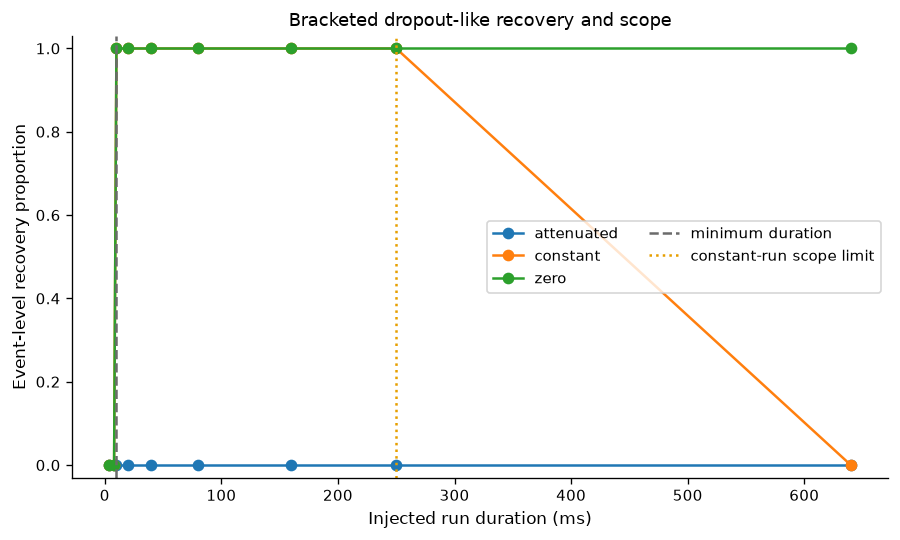

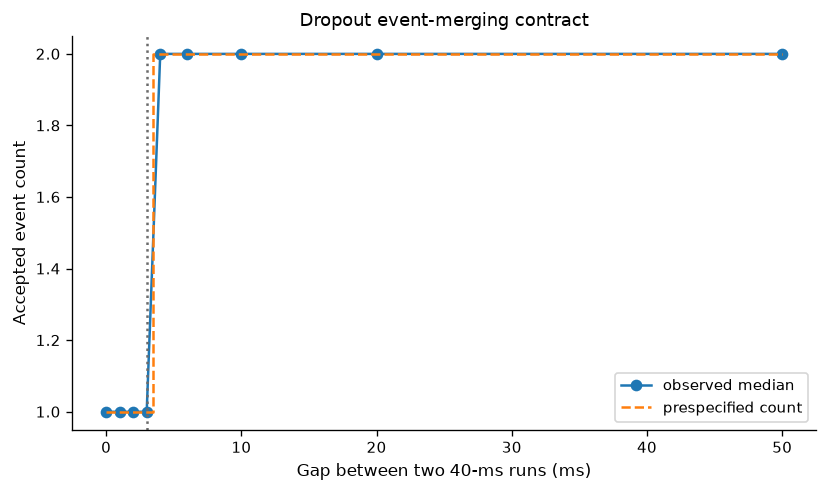

In [4]:

# Detector-specific execution is used for validation grids so another detector
# cannot make the positive-control result look better or worse.
DROPOUT_DOSE_COLUMNS = [
    "seed", "mode", "duration_ms", "expected_positive", "detected",
    "matched_event_count", "start_error_ms", "end_error_ms",
    "accepted_event_count", "indeterminate_candidate_count",
    "recovered_duration_ms", "duration_error_ms", "false_event_count_outside_truth",
]
DROPOUT_CONTROL_COLUMNS = ["control", "accepted", "indeterminate", "candidates"]
DROPOUT_CONTEXT_COLUMNS = [
    "seed", "sample_rate_hz", "source_peak", "duration_ms", "detected",
    "accepted_event_count", "indeterminate_candidate_count",
]
DROPOUT_MERGE_COLUMNS = [
    "seed", "gap_ms", "expected_event_count", "observed_event_count",
    "total_recovered_duration_ms", "count_correct",
]

dropout_rows = []
dropout_context_rows = []
dropout_merge_rows = []
dropout_controls_rows = []

if RUN_SYNTHETIC_VALIDATION:
    durations_ms = [4, 8, 10, 20, 40, 80, 160, 250, 640]
    for seed in range(6):
        source = stochastic_carrier(seed=seed)
        for mode in ["zero", "constant", "attenuated"]:
            for duration_ms in durations_ms:
                kwargs = {"mode": mode}
                if mode == "constant":
                    kwargs["constant_value"] = 1e-5
                elif mode == "attenuated":
                    kwargs["attenuation_db"] = -40
                perturbed = inject_dropout(source, FS_SYNTH, 3.0, duration_ms, **kwargs)
                result = extract_qtemp(
                    perturbed,
                    FS_SYNTH,
                    logical_recording_id=f"drop-{seed}-{mode}-{duration_ms}",
                    enabled_event_types=("dropout",),
                )
                truth_end = 3.0 + duration_ms / 1000.0
                match = match_events_to_truth(
                    result.event_ledger,
                    event_type="dropout",
                    truth_start_sec=3.0,
                    truth_end_sec=truth_end,
                    tolerance_ms=3.0,
                )
                accepted = (
                    result.event_ledger.loc[result.event_ledger["event_type"].eq("dropout")]
                    if len(result.event_ledger)
                    else result.event_ledger
                )
                recovered_ms = 1000.0 * accepted["duration_sec"].sum() if len(accepted) else 0.0
                if mode == "zero":
                    expected_positive = (
                        PARAMETERS.dropout_min_duration_ms <= duration_ms <= PARAMETERS.dropout_max_duration_ms
                    )
                elif mode == "constant":
                    expected_positive = (
                        PARAMETERS.dropout_min_duration_ms <= duration_ms <= PARAMETERS.dropout_constant_max_duration_ms
                    )
                else:
                    # Attenuation is a discriminant/characterization series, not a dropout ground truth.
                    expected_positive = False
                dropout_rows.append({
                    "seed": seed,
                    "mode": mode,
                    "duration_ms": duration_ms,
                    "expected_positive": expected_positive,
                    **match,
                    "accepted_event_count": len(accepted),
                    "indeterminate_candidate_count": result.recording["qtemp_dropout_indeterminate_candidate_count"],
                    "recovered_duration_ms": recovered_ms,
                    "duration_error_ms": recovered_ms - duration_ms,
                    "false_event_count_outside_truth": int(
                        (
                            (accepted["end_sec"] < 2.99)
                            | (accepted["start_sec"] > truth_end + 0.01)
                        ).sum()
                    ) if len(accepted) else 0,
                })

    # Native-sample-rate and source-level characterization.
    for fs_value in [8000, 16000, 24000, 44100, 48000]:
        for source_peak in [0.002, 0.01, 0.05, 0.20]:
            for seed in range(2):
                source = stochastic_carrier(fs=fs_value, seed=200 + seed)
                source *= source_peak / max(np.max(np.abs(source)), 1e-12)
                perturbed = inject_dropout(source, fs_value, 3.0, 40, mode="zero")
                result = extract_qtemp(
                    perturbed,
                    fs_value,
                    logical_recording_id=f"drop-context-{fs_value}-{source_peak}-{seed}",
                    enabled_event_types=("dropout",),
                )
                match = match_events_to_truth(
                    result.event_ledger,
                    event_type="dropout",
                    truth_start_sec=3.0,
                    truth_end_sec=3.04,
                    tolerance_ms=3.0,
                )
                dropout_context_rows.append({
                    "seed": seed,
                    "sample_rate_hz": fs_value,
                    "source_peak": source_peak,
                    "duration_ms": 40,
                    "detected": match["detected"],
                    "accepted_event_count": result.recording["qtemp_dropout_accepted_event_count"],
                    "indeterminate_candidate_count": result.recording["qtemp_dropout_indeterminate_candidate_count"],
                })

    # Event merging and count recovery: two 40-ms exact-zero runs separated by a known gap.
    for seed in range(4):
        source = stochastic_carrier(seed=300 + seed)
        for gap_ms in [0, 1, 2, 3, 4, 6, 10, 20, 50]:
            first_start = 2.8
            first_duration_ms = 40.0
            second_start = first_start + (first_duration_ms + gap_ms) / 1000.0
            perturbed = inject_dropout(source, FS_SYNTH, first_start, first_duration_ms, mode="zero")
            perturbed = inject_dropout(perturbed, FS_SYNTH, second_start, first_duration_ms, mode="zero")
            result = extract_qtemp(
                perturbed,
                FS_SYNTH,
                logical_recording_id=f"drop-merge-{seed}-{gap_ms}",
                enabled_event_types=("dropout",),
            )
            expected_count = 1 if gap_ms <= PARAMETERS.dropout_merge_gap_ms else 2
            observed_count = result.recording["qtemp_dropout_accepted_event_count"]
            accepted = result.event_ledger if len(result.event_ledger) else pd.DataFrame()
            dropout_merge_rows.append({
                "seed": seed,
                "gap_ms": gap_ms,
                "expected_event_count": expected_count,
                "observed_event_count": observed_count,
                "total_recovered_duration_ms": 1000.0 * accepted["duration_sec"].sum() if len(accepted) else 0.0,
                "count_correct": observed_count == expected_count,
            })

    time = np.arange(8 * FS_SYNTH) / FS_SYNTH
    control_signals = {
        "clean_multitone": multitone_carrier(),
        "clean_stochastic": stochastic_carrier(),
        "edge_zero": inject_dropout(multitone_carrier(), FS_SYNTH, 0.0, 500, mode="zero"),
        "low_gain_interval": inject_dropout(multitone_carrier(), FS_SYNTH, 3.0, 80, mode="attenuated", attenuation_db=-12),
        "stop_closure_like": inject_dropout(multitone_carrier(), FS_SYNTH, 3.0, 45, mode="attenuated", attenuation_db=-28),
        "voiceless_noise": 0.008 * signal.lfilter([1, -0.95], [1], RNG.normal(size=8 * FS_SYNTH)),
        "breathy_low_level": 0.004 * signal.lfilter([1], [1, -0.92], RNG.normal(size=8 * FS_SYNTH)),
        "pure_tone": 0.04 * np.sin(2 * np.pi * 200 * time),
        "long_natural_silence_proxy": inject_dropout(multitone_carrier(), FS_SYNTH, 3.0, 1200, mode="zero"),
    }
    for name, waveform in control_signals.items():
        result = extract_qtemp(
            waveform,
            FS_SYNTH,
            logical_recording_id=name,
            enabled_event_types=("dropout",),
        )
        dropout_controls_rows.append({
            "control": name,
            "accepted": result.recording["qtemp_dropout_accepted_event_count"],
            "indeterminate": result.recording["qtemp_dropout_indeterminate_candidate_count"],
            "candidates": result.recording["qtemp_dropout_candidate_count"],
        })

dropout_dose = pd.DataFrame(dropout_rows, columns=DROPOUT_DOSE_COLUMNS)
dropout_context = pd.DataFrame(dropout_context_rows, columns=DROPOUT_CONTEXT_COLUMNS)
dropout_merge = pd.DataFrame(dropout_merge_rows, columns=DROPOUT_MERGE_COLUMNS)
dropout_controls = pd.DataFrame(dropout_controls_rows, columns=DROPOUT_CONTROL_COLUMNS)
for frame, stem in [
    (dropout_dose, f"{PREFIX}_dropout_synthetic_dose_grid"),
    (dropout_context, f"{PREFIX}_dropout_sample_rate_level_grid"),
    (dropout_merge, f"{PREFIX}_dropout_merge_count_grid"),
    (dropout_controls, f"{PREFIX}_dropout_synthetic_controls"),
]:
    save_table_bundle(frame, TABLES, stem)

expected = dropout_dose.loc[dropout_dose["expected_positive"]] if len(dropout_dose) else dropout_dose
unexpected = dropout_dose.loc[~dropout_dose["expected_positive"]] if len(dropout_dose) else dropout_dose
attenuated = dropout_dose.loc[dropout_dose["mode"].eq("attenuated")] if len(dropout_dose) else dropout_dose

dropout_checks = validation_frame([
    ValidationCheck(
        "mechanism",
        "prespecified exact-zero/constant runs are recovered",
        bool(len(expected)) and expected["detected"].mean() >= 0.95,
        f"recall={expected['detected'].mean():.3f}" if len(expected) else "NOT RUN",
        ">=0.95",
        "revise duration/contrast contract",
    ),
    ValidationCheck(
        "mechanism",
        "accepted dropout duration is sample-accurate",
        bool(len(expected)) and np.nanmedian(np.abs(expected["duration_error_ms"])) <= 1.0,
        f"median absolute error={np.nanmedian(np.abs(expected['duration_error_ms'])):.3f} ms" if len(expected) else "NOT RUN",
        "<=1 ms",
        "repair event boundaries",
    ),
    ValidationCheck(
        "discriminant",
        "attenuated active signal is not relabeled as missing support",
        bool(len(attenuated)) and attenuated["detected"].sum() == 0,
        f"detections={int(attenuated['detected'].sum())}" if len(attenuated) else "NOT RUN",
        "0",
        "tighten low-information definition",
    ),
    ValidationCheck(
        "discriminant",
        "synthetic pause/closure/weak-signal controls have no accepted events",
        bool(len(dropout_controls)) and dropout_controls["accepted"].sum() == 0,
        f"accepted={int(dropout_controls['accepted'].sum())}" if len(dropout_controls) else "NOT RUN",
        "0",
        "tighten bracketing and maximum-duration criteria",
    ),
    ValidationCheck(
        "robustness",
        "40-ms exact-zero recovery is stable across native sample rates and source levels",
        bool(len(dropout_context)) and dropout_context["detected"].mean() >= 0.95,
        f"recovery={dropout_context['detected'].mean():.3f}" if len(dropout_context) else "NOT RUN",
        ">=0.95",
        "repair native-sample conversion or activity floor",
    ),
    ValidationCheck(
        "aggregation",
        "event merging/count behavior follows the prespecified gap rule",
        bool(len(dropout_merge)) and dropout_merge["count_correct"].mean() >= 0.95,
        f"correct={dropout_merge['count_correct'].mean():.3f}" if len(dropout_merge) else "NOT RUN",
        ">=0.95",
        "repair run merging or document boundary convention",
    ),
])

if len(dropout_dose):
    display(dropout_dose.groupby(["mode", "duration_ms"], as_index=False).agg(
        expected_positive=("expected_positive", "first"),
        recall=("detected", "mean"),
        median_duration_error_ms=("duration_error_ms", lambda value: np.nanmedian(np.abs(value))),
        false_events=("false_event_count_outside_truth", "sum"),
    ))
else:
    display(Markdown("Synthetic dropout validation was disabled."))
display(dropout_context.groupby(["sample_rate_hz", "source_peak"], as_index=False).agg(recovery=("detected", "mean")) if len(dropout_context) else dropout_context)
display(dropout_merge.groupby("gap_ms", as_index=False).agg(expected=("expected_event_count", "first"), observed=("observed_event_count", "median"), correct=("count_correct", "mean")) if len(dropout_merge) else dropout_merge)
display(dropout_controls)
display(dropout_checks)

if len(dropout_dose):
    summary = dropout_dose.groupby(["mode", "duration_ms"], as_index=False).agg(recall=("detected", "mean"))
    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    for mode, local in summary.groupby("mode"):
        ax.plot(local["duration_ms"], local["recall"], marker="o", label=mode)
    ax.axvline(PARAMETERS.dropout_min_duration_ms, color=OKABE_ITO["grey"], linestyle="--", label="minimum duration")
    ax.axvline(PARAMETERS.dropout_constant_max_duration_ms, color=OKABE_ITO["orange"], linestyle=":", label="constant-run scope limit")
    ax.set(xlabel="Injected run duration (ms)", ylabel="Event-level recovery proportion", ylim=(-0.03, 1.03), title="Bracketed dropout-like recovery and scope")
    ax.legend(ncol=2)
    fig.tight_layout()
    save_publication_figure(
        fig,
        FIGURES,
        "figure_qtemp_dropout_synthetic_recovery",
        caption="Recovery across eight stochastic source realizations. Exact-zero and short constant-low-information runs are positive controls; attenuation is a discriminant characterization.",
        alt_text="Recovery proportion versus injected duration for exact-zero, constant, and attenuated intervals.",
    )
    plt.show()

if len(dropout_merge):
    summary = dropout_merge.groupby("gap_ms", as_index=False).agg(observed=("observed_event_count", "median"), expected=("expected_event_count", "first"))
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.plot(summary["gap_ms"], summary["observed"], marker="o", label="observed median")
    ax.step(summary["gap_ms"], summary["expected"], where="mid", linestyle="--", label="prespecified count")
    ax.axvline(PARAMETERS.dropout_merge_gap_ms, color=OKABE_ITO["grey"], linestyle=":")
    ax.set(xlabel="Gap between two 40-ms runs (ms)", ylabel="Accepted event count", title="Dropout event-merging contract")
    ax.legend()
    fig.tight_layout()
    save_publication_figure(
        fig,
        FIGURES,
        "figure_qtemp_dropout_merge_rule",
        caption="Observed and prespecified event counts for two exact-zero runs separated by a controlled gap.",
        alt_text="Accepted dropout event count as a function of gap between two injected runs.",
    )
    plt.show()


## 4. Synthetic near-exact consecutive decoded-repetition validity and periodic-signal rejection


,duration_ms,perturbation_fraction_rms,recovery,accepted,indeterminate,false_events
0,10,0.0000,0.0,0.0,0.0,0
1,15,0.0000,0.0,0.0,0.0,0
2,20,0.0000,1.0,1.0,0.0,0
3,20,0.0005,1.0,1.0,0.0,0
4,20,0.0050,0.0,0.0,1.0,0
5,25,0.0000,1.0,1.0,0.0,0
6,30,0.0000,1.0,1.0,0.0,0
7,40,0.0000,1.0,1.0,0.0,0
8,40,0.0005,1.0,1.0,0.0,0
9,40,0.0050,0.0,0.0,1.0,0


,control,accepted,indeterminate,candidates
0,pure_tone_120hz,0,0,1
1,pure_tone_200hz,0,0,2
2,harmonic_100hz,0,0,1
3,am_vowel_like,0,31,31
4,slow_f0_sweep,0,8,8
5,repeated_syllable_proxy,0,0,1
6,multitone_connected_like,0,0,0
7,stochastic,0,0,0


,layer,check,passed,observed,required,action_if_failed,blocking
0,mechanism,exact duplicates are recovered over the prespecified lag grid,True,recall=1.000,>=0.90,revise frame-sequence or lag-grid detector,True
1,mechanism,near-exact repetition sensitivity is characterized,True,levels=2,>=2 near-exact levels,expand perturbation grid,False
2,discriminant,"periodic, vowel-like, and repeated-content controls have no accepted duplicate events",True,accepted=0,0,tighten periodicity/entropy/boundary-novelty guards,True
3,scope,lag support is explicit and auditable,True,supported=98/98,all tested durations supported,align test grid and registered lag support,True


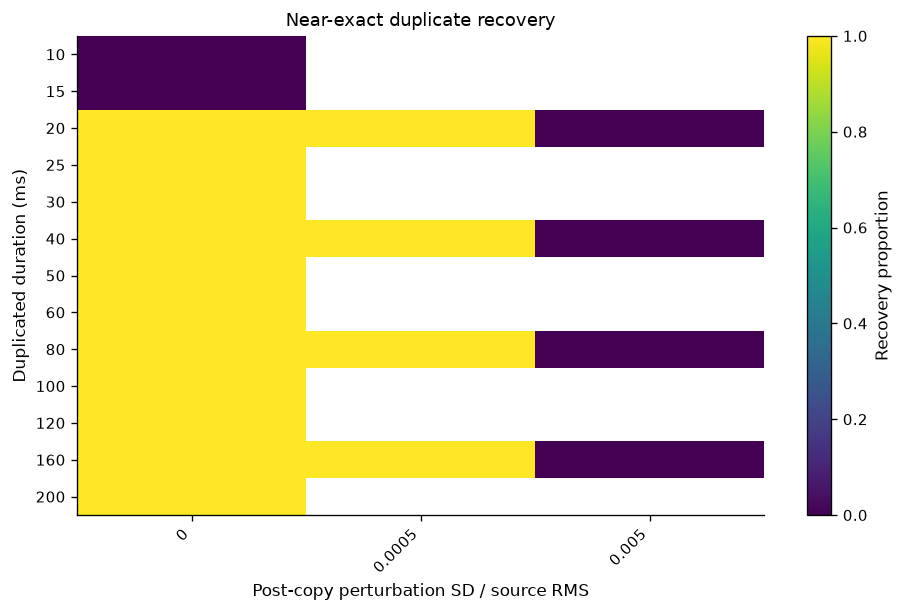

In [5]:

DUPLICATE_DOSE_COLUMNS = [
    "seed", "duration_ms", "lag_supported", "perturbation_fraction_rms",
    "perturbation_sd", "detected", "matched_event_count", "start_error_ms",
    "end_error_ms", "accepted_event_count", "indeterminate_candidate_count",
    "false_event_count_outside_truth",
]
DUPLICATE_CONTROL_COLUMNS = ["control", "accepted", "indeterminate", "candidates"]

duplicate_rows = []
duplicate_controls_rows = []
if RUN_SYNTHETIC_VALIDATION:
    durations_ms = [10, 15, 20, 25, 30, 40, 50, 60, 80, 100, 120, 160, 200]
    supported_lags = set(float(value) for value in PARAMETERS.duplicate_lags_ms)
    # Full exact-lag coverage uses two independent realizations. Perturbation
    # characterization uses replicated representative durations, avoiding the
    # 520 redundant full-waveform runs used in v0.2.
    design = []
    for seed in range(2):
        for duration_ms in durations_ms:
            design.append((seed, duration_ms, 0.0))
    for seed in range(2, 8):
        for duration_ms in [20, 40, 80, 160]:
            for fraction in [0.0, 5e-4, 5e-3]:
                design.append((seed, duration_ms, fraction))
    for seed, duration_ms, fraction in design:
        source = stochastic_carrier(seed=100 + seed)
        source_rms = float(np.sqrt(np.mean(source**2)))
        perturbation_sd = fraction * source_rms
        perturbed = inject_consecutive_duplicate(source, FS_SYNTH, 2.5, duration_ms, perturbation_sd=perturbation_sd, random_seed=seed)
        result = extract_qtemp(perturbed, FS_SYNTH, logical_recording_id=f"dup-{seed}-{duration_ms}-{fraction}", enabled_event_types=("frozen_audio",))
        truth_start = 2.5 + duration_ms / 1000.0; truth_end = truth_start + duration_ms / 1000.0
        match = match_events_to_truth(result.event_ledger, event_type="frozen_audio", truth_start_sec=truth_start, truth_end_sec=truth_end, tolerance_ms=10.0)
        accepted = result.event_ledger if len(result.event_ledger) else pd.DataFrame()
        duplicate_rows.append({
            "seed": seed, "duration_ms": duration_ms, "lag_supported": float(duration_ms) in supported_lags,
            "perturbation_fraction_rms": fraction, "perturbation_sd": perturbation_sd, **match,
            "accepted_event_count": result.recording["qtemp_frozen_audio_accepted_event_count"],
            "indeterminate_candidate_count": result.recording["qtemp_frozen_audio_indeterminate_candidate_count"],
            "false_event_count_outside_truth": int(((accepted["end_sec"] < truth_start - 0.02) | (accepted["start_sec"] > truth_end + 0.02)).sum()) if len(accepted) else 0,
        })

    time = np.arange(8 * FS_SYNTH) / FS_SYNTH
    repeated_syllable_proxy = np.tile(stochastic_carrier(duration_sec=0.20, seed=777), 40)
    periodic_controls = {
        "pure_tone_120hz": 0.04 * np.sin(2 * np.pi * 120 * time),
        "pure_tone_200hz": 0.04 * np.sin(2 * np.pi * 200 * time),
        "harmonic_100hz": 0.035 * (np.sin(2 * np.pi * 100 * time) + 0.4 * np.sin(2 * np.pi * 200 * time) + 0.2 * np.sin(2 * np.pi * 300 * time)),
        "am_vowel_like": (0.03 + 0.005 * np.sin(2 * np.pi * 2 * time)) * (np.sin(2 * np.pi * 140 * time) + 0.35 * np.sin(2 * np.pi * 280 * time)),
        "slow_f0_sweep": 0.04 * signal.chirp(time, f0=110, f1=190, t1=time[-1], method="linear"),
        "repeated_syllable_proxy": repeated_syllable_proxy[: 8 * FS_SYNTH],
        "multitone_connected_like": multitone_carrier(),
        "stochastic": stochastic_carrier(),
    }
    for name, waveform in periodic_controls.items():
        result = extract_qtemp(
            waveform,
            FS_SYNTH,
            logical_recording_id=name,
            enabled_event_types=("frozen_audio",),
        )
        duplicate_controls_rows.append({
            "control": name,
            "accepted": result.recording["qtemp_frozen_audio_accepted_event_count"],
            "indeterminate": result.recording["qtemp_frozen_audio_indeterminate_candidate_count"],
            "candidates": result.recording["qtemp_frozen_audio_candidate_count"],
        })

duplicate_dose = pd.DataFrame(duplicate_rows, columns=DUPLICATE_DOSE_COLUMNS)
duplicate_controls = pd.DataFrame(duplicate_controls_rows, columns=DUPLICATE_CONTROL_COLUMNS)
save_table_bundle(duplicate_dose, TABLES, f"{PREFIX}_duplicate_synthetic_dose_grid")
save_table_bundle(duplicate_controls, TABLES, f"{PREFIX}_duplicate_periodic_controls")

exact_eligible = duplicate_dose.loc[
    duplicate_dose["lag_supported"]
    & duplicate_dose["duration_ms"].ge(PARAMETERS.duplicate_min_sequence_ms)
    & duplicate_dose["perturbation_fraction_rms"].eq(0.0)
] if len(duplicate_dose) else duplicate_dose
small_perturbation = duplicate_dose.loc[
    duplicate_dose["lag_supported"]
    & duplicate_dose["duration_ms"].ge(PARAMETERS.duplicate_min_sequence_ms)
    & duplicate_dose["perturbation_fraction_rms"].le(1e-3)
] if len(duplicate_dose) else duplicate_dose

duplicate_checks = validation_frame([
    ValidationCheck(
        "mechanism",
        "exact duplicates are recovered over the prespecified lag grid",
        bool(len(exact_eligible)) and exact_eligible["detected"].mean() >= 0.90,
        f"recall={exact_eligible['detected'].mean():.3f}" if len(exact_eligible) else "NOT RUN",
        ">=0.90",
        "revise frame-sequence or lag-grid detector",
    ),
    ValidationCheck(
        "mechanism",
        "near-exact repetition sensitivity is characterized",
        bool(len(small_perturbation)) and small_perturbation["perturbation_fraction_rms"].nunique() >= 2,
        f"levels={small_perturbation['perturbation_fraction_rms'].nunique()}" if len(small_perturbation) else "NOT RUN",
        ">=2 near-exact levels",
        "expand perturbation grid",
        blocking=False,
    ),
    ValidationCheck(
        "discriminant",
        "periodic, vowel-like, and repeated-content controls have no accepted duplicate events",
        bool(len(duplicate_controls)) and duplicate_controls["accepted"].sum() == 0,
        f"accepted={int(duplicate_controls['accepted'].sum())}" if len(duplicate_controls) else "NOT RUN",
        "0",
        "tighten periodicity/entropy/boundary-novelty guards",
    ),
    ValidationCheck(
        "scope",
        "lag support is explicit and auditable",
        bool(len(duplicate_dose)) and duplicate_dose["lag_supported"].all(),
        f"supported={int(duplicate_dose['lag_supported'].sum())}/{len(duplicate_dose)}" if len(duplicate_dose) else "NOT RUN",
        "all tested durations supported",
        "align test grid and registered lag support",
    ),
])

if len(duplicate_dose):
    display(duplicate_dose.groupby(["duration_ms", "perturbation_fraction_rms"], as_index=False).agg(
        recovery=("detected", "mean"),
        accepted=("accepted_event_count", "mean"),
        indeterminate=("indeterminate_candidate_count", "mean"),
        false_events=("false_event_count_outside_truth", "sum"),
    ))
else:
    display(Markdown("Synthetic duplicate validation was disabled."))
display(duplicate_controls)
display(duplicate_checks)

if len(duplicate_dose):
    pivot = duplicate_dose.pivot_table(
        index="duration_ms",
        columns="perturbation_fraction_rms",
        values="detected",
        aggfunc="mean",
    )
    fig, ax = plt.subplots(figsize=(8.0, 5.2))
    image = ax.imshow(pivot.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)), [f"{value:g}" for value in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)), [str(value) for value in pivot.index])
    ax.set(xlabel="Post-copy perturbation SD / source RMS", ylabel="Duplicated duration (ms)", title="Near-exact duplicate recovery")
    fig.colorbar(image, ax=ax, label="Recovery proportion")
    fig.tight_layout()
    save_publication_figure(
        fig,
        FIGURES,
        "figure_qtemp_duplicate_synthetic_recovery",
        caption="Recovery of consecutive duplicated support by duration and perturbation relative to source RMS across an efficient exact-lag coverage and replicated representative-duration design.",
        alt_text="Heatmap of duplicate recovery across duration and relative post-copy perturbation.",
    )
    plt.show()


## 5. Synthetic splice validity, competing mechanisms, and cross-family arbitration


,mechanism,dose,recovery,median_abs_start_error_ms,accepted,indeterminate
0,deletion_join_characterization,10,0.0,NaN,0.000000,0.416667
1,deletion_join_characterization,40,0.0,NaN,0.000000,0.500000
2,deletion_join_characterization,100,0.0,NaN,0.000000,0.416667
3,foreign_insertion_join,40,0.0,NaN,0.833333,0.166667
4,rms_matched_source_replacement,60,1.0,4.203125,2.166667,1.166667


,control,accepted,indeterminate,rejected,qdist_guard_rejections,qadd_guard_rejections,qgain_competing_indeterminate,speech_boundary_rejections
0,clean,0,1,0,0,0,0,0
1,gain_step_9db,0,2,9,0,0,0,0
2,impulse_click,0,1,1,0,1,0,0
3,hard_clip_with_qdist_guard,0,0,0,0,0,0,0
4,speech_boundary_guard,0,1,0,0,0,0,0


,layer,check,passed,observed,required,action_if_failed,blocking
0,mechanism,strong RMS-matched finite source-replacement joins are localized,True,recall=1.000,>=0.80,revise local-continuity detector or narrow claim,True
1,localization,accepted strong joins are localized within the prespecified 10 ms tolerance,True,median error=4.203 ms,<=10 ms,repair join localization or narrow temporal-resolution claim,True
2,discriminant,"gain-step, click, clipping, and speech-boundary controls have no accepted splice events",True,accepted=0,0,repair competing-mechanism guards,True
3,arbitration,splice candidates at accepted dropout boundaries are not accepted,True,no accepted overlap,no accepted overlap,repair within-family precedence,True


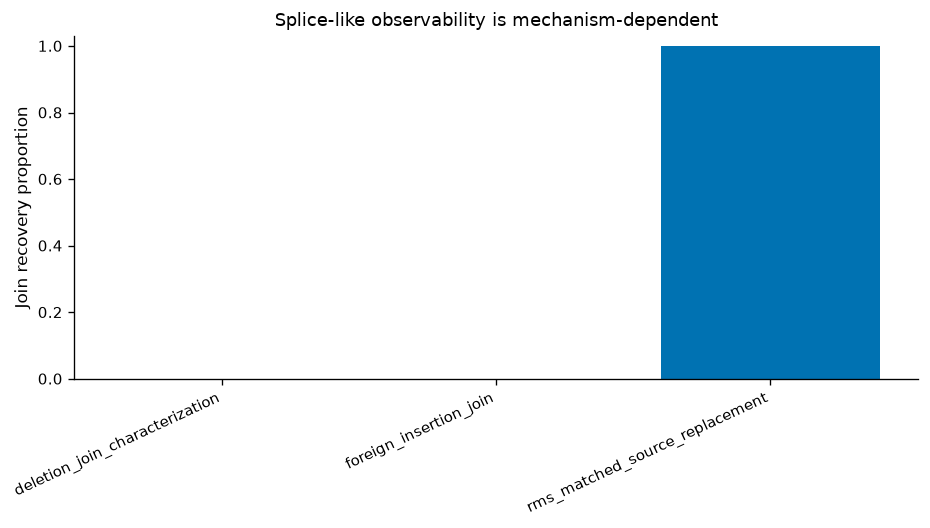

In [6]:

SPLICE_DOSE_COLUMNS = [
    "seed", "mechanism", "dose", "dose_unit", "detected", "matched_event_count",
    "start_error_ms", "end_error_ms", "accepted_count", "indeterminate_count",
]
SPLICE_CONTROL_COLUMNS = [
    "control", "accepted", "indeterminate", "rejected", "qdist_guard_rejections",
    "qadd_guard_rejections", "qgain_competing_indeterminate", "speech_boundary_rejections",
]

def source_switch_splice(seed: int, join_sec: float = 3.0):
    """Create a strong, RMS-matched abrupt source switch without a gain step."""
    time = np.arange(8 * FS_SYNTH) / FS_SYNTH
    rng = np.random.default_rng(seed)
    phase = rng.uniform(0, 2 * np.pi, size=6)
    left = (
        np.sin(2 * np.pi * 170 * time + phase[0])
        + 0.55 * np.sin(2 * np.pi * 430 * time + phase[1])
        + 0.25 * np.sin(2 * np.pi * 910 * time + phase[2])
    )
    right = (
        np.sin(2 * np.pi * 293 * time + phase[3])
        + 0.55 * np.sin(2 * np.pi * 733 * time + phase[4])
        + 0.25 * np.sin(2 * np.pi * 1327 * time + phase[5])
    )
    left = 0.04 * left / max(np.sqrt(np.mean(left**2)), 1e-12)
    right = 0.04 * right / max(np.sqrt(np.mean(right**2)), 1e-12)
    join = int(round(join_sec * FS_SYNTH))
    # Choose only the phase alignment of the already RMS-matched right source so
    # the positive control contains an unambiguously strong local join. This is
    # not a gain/offset dose and does not alter either source distribution.
    candidate_shifts = np.arange(0, min(320, len(right)))
    mismatch = np.abs(right[(join + candidate_shifts) % len(right)] - left[join - 1])
    right = np.roll(right, -int(candidate_shifts[int(np.argmax(mismatch))]))
    output = left.copy()
    output[join:] = right[join:]
    return output, join_sec

splice_rows = []
splice_controls_rows = []
arbitration_audit = pd.DataFrame()
if RUN_SYNTHETIC_VALIDATION:
    # Plain deletion joins are characterized, not assumed to be detectable at every duration.
    for seed in range(12):
        source = stochastic_carrier(seed=1000 + seed)
        for deleted_ms in [10, 40, 100]:
            perturbed, join_sec = inject_splice_delete(source, FS_SYNTH, 3.0, deleted_ms)
            result = extract_qtemp(
                perturbed,
                FS_SYNTH,
                logical_recording_id=f"splice-delete-{seed}-{deleted_ms}",
                enabled_event_types=("splice",),
            )
            match = match_events_to_truth(
                result.event_ledger,
                event_type="splice",
                truth_start_sec=join_sec,
                tolerance_ms=4.0,
            )
            splice_rows.append({
                "seed": seed,
                "mechanism": "deletion_join_characterization",
                "dose": deleted_ms,
                "dose_unit": "deleted_ms",
                **match,
                "accepted_count": result.recording["qtemp_splice_accepted_event_count"],
                "indeterminate_count": result.recording["qtemp_splice_indeterminate_candidate_count"],
            })

        # Finite RMS-matched foreign-source replacement creates two known joins.
        source = multitone_carrier()
        donor = stochastic_carrier(seed=5000 + seed)
        replacement = donor[int(round(4.0 * FS_SYNTH)): int(round(4.060 * FS_SYNTH))].copy()
        target_start = int(round(3.0 * FS_SYNTH))
        replacement *= np.sqrt(np.mean(source[target_start:target_start+len(replacement)]**2)) / max(np.sqrt(np.mean(replacement**2)), 1e-12)
        switched, boundaries = inject_splice_replace(source, FS_SYNTH, 3.0, replacement)
        result = extract_qtemp(switched, FS_SYNTH, logical_recording_id=f"splice-replacement-{seed}", enabled_event_types=("splice",))
        point_match = match_events_to_truth_points(result.event_ledger, event_type="splice", truth_times_sec=boundaries, tolerance_ms=10.0)
        splice_rows.append({
            "seed": seed, "mechanism": "rms_matched_source_replacement", "dose": 60, "dose_unit": "replacement_ms",
            "detected": point_match["boundary_recall"] == 1.0,
            "matched_event_count": point_match["matched_boundary_count"],
            "start_error_ms": point_match["median_abs_error_ms"], "end_error_ms": point_match["maximum_abs_error_ms"],
            "accepted_count": result.recording["qtemp_splice_accepted_event_count"],
            "indeterminate_count": result.recording["qtemp_splice_indeterminate_candidate_count"],
        })

        # Foreign 40-ms insertion introduces two abrupt joins; both are evaluated.
        foreign, _ = source_switch_splice(5000 + seed, join_sec=0.02)
        inserted = foreign[: int(round(0.04 * FS_SYNTH))]
        perturbed, join_sec = inject_splice_insert(source, FS_SYNTH, 3.0, inserted)
        result = extract_qtemp(
            perturbed,
            FS_SYNTH,
            logical_recording_id=f"splice-insert-{seed}",
            enabled_event_types=("splice",),
        )
        point_match = match_events_to_truth_points(
            result.event_ledger, event_type="splice",
            truth_times_sec=(join_sec, join_sec + len(inserted) / FS_SYNTH), tolerance_ms=10.0,
        )
        splice_rows.append({
            "seed": seed, "mechanism": "foreign_insertion_join", "dose": 40, "dose_unit": "inserted_ms",
            "detected": point_match["boundary_recall"] == 1.0,
            "matched_event_count": point_match["matched_boundary_count"],
            "start_error_ms": point_match["median_abs_error_ms"], "end_error_ms": point_match["maximum_abs_error_ms"],
            "accepted_count": result.recording["qtemp_splice_accepted_event_count"],
            "indeterminate_count": result.recording["qtemp_splice_indeterminate_candidate_count"],
        })

    base = stochastic_carrier(seed=222)
    clipping_interval = [TimeInterval(2.8, 3.2)]
    control_cases = {
        "clean": (base, [], []),
        "gain_step_9db": (apply_gain_step(base, FS_SYNTH, 3.0, 9.0), [], []),
        "impulse_click": (inject_impulse(base, FS_SYNTH, 3.0, 0.8), [], []),
        "hard_clip_with_qdist_guard": (hard_clip(base * 8, 0.22), clipping_interval, []),
        "speech_boundary_guard": (base, [], [TimeInterval(0.5, 3.0), TimeInterval(3.0, 7.5)]),
    }
    for name, (waveform, clipping, speech_intervals) in control_cases.items():
        result = extract_qtemp(
            waveform,
            FS_SYNTH,
            logical_recording_id=name,
            clipping_event_intervals=clipping,
            speech_intervals=speech_intervals,
            enabled_event_types=("splice",),
        )
        local = (
            result.disposition_ledger.loc[result.disposition_ledger["event_type"].eq("splice")]
            if len(result.disposition_ledger)
            else result.disposition_ledger
        )
        splice_controls_rows.append({
            "control": name,
            "accepted": int(local["disposition"].eq("accepted").sum()) if len(local) else 0,
            "indeterminate": int(local["disposition"].eq("indeterminate").sum()) if len(local) else 0,
            "rejected": int(local["disposition"].eq("rejected").sum()) if len(local) else 0,
            "qdist_guard_rejections": int(local["disposition_reason"].eq("qdist_clipping_edge_guard").sum()) if len(local) else 0,
            "qadd_guard_rejections": int(local["disposition_reason"].eq("qadd_impulse_like_guard").sum()) if len(local) else 0,
            "qgain_competing_indeterminate": int(local["disposition_reason"].eq("qgain_level_step_competing").sum()) if len(local) else 0,
            "speech_boundary_rejections": int(local["disposition_reason"].eq("speech_onset_offset_guard").sum()) if len(local) else 0,
        })

    # Within-QTEMP precedence is assessed using all detectors, not detector-specific execution.
    dropout_with_edges = inject_dropout(stochastic_carrier(seed=333), FS_SYNTH, 3.0, 40, mode="zero")
    arbitration_result = extract_qtemp(
        dropout_with_edges,
        FS_SYNTH,
        logical_recording_id="qtemp-arbitration",
        parameters=replace(
            PARAMETERS,
            splice_derivative_z_accept=5.0,
            splice_prediction_z_accept=2.5,
            splice_derivative_z_indeterminate=4.0,
            splice_prediction_z_indeterminate=2.0,
        ),
    )
    arbitration_audit = (
        arbitration_result.disposition_ledger.loc[
            arbitration_result.disposition_ledger["event_type"].eq("splice")
        ]
        if len(arbitration_result.disposition_ledger)
        else arbitration_result.disposition_ledger
    )

splice_dose = pd.DataFrame(splice_rows, columns=SPLICE_DOSE_COLUMNS)
splice_controls = pd.DataFrame(splice_controls_rows, columns=SPLICE_CONTROL_COLUMNS)
save_table_bundle(splice_dose, TABLES, f"{PREFIX}_splice_synthetic_characterization")
save_table_bundle(splice_controls, TABLES, f"{PREFIX}_splice_competing_mechanism_controls")
save_table_bundle(arbitration_audit, TABLES, f"{PREFIX}_within_qtemp_arbitration_audit")

strong_splice = splice_dose.loc[splice_dose["mechanism"].eq("rms_matched_source_replacement")] if len(splice_dose) else splice_dose
splice_checks = validation_frame([
    ValidationCheck(
        "mechanism",
        "strong RMS-matched finite source-replacement joins are localized",
        bool(len(strong_splice)) and strong_splice["detected"].mean() >= 0.80,
        f"recall={strong_splice['detected'].mean():.3f}" if len(strong_splice) else "NOT RUN",
        ">=0.80",
        "revise local-continuity detector or narrow claim",
    ),
    ValidationCheck(
        "localization",
        "accepted strong joins are localized within the prespecified 10 ms tolerance",
        bool(len(strong_splice)) and np.nanmedian(np.abs(strong_splice["start_error_ms"])) <= 10.0,
        f"median error={np.nanmedian(np.abs(strong_splice['start_error_ms'])):.3f} ms" if len(strong_splice) else "NOT RUN",
        "<=10 ms",
        "repair join localization or narrow temporal-resolution claim",
    ),
    ValidationCheck(
        "discriminant",
        "gain-step, click, clipping, and speech-boundary controls have no accepted splice events",
        bool(len(splice_controls)) and splice_controls["accepted"].sum() == 0,
        f"accepted={int(splice_controls['accepted'].sum())}" if len(splice_controls) else "NOT RUN",
        "0",
        "repair competing-mechanism guards",
    ),
    ValidationCheck(
        "arbitration",
        "splice candidates at accepted dropout boundaries are not accepted",
        (
            not arbitration_audit.loc[
                arbitration_audit["start_sec"].between(2.995, 3.045), "disposition"
            ].eq("accepted").any()
            if len(arbitration_audit)
            else bool(RUN_SYNTHETIC_VALIDATION)
        ),
        "no accepted overlap" if len(arbitration_audit) else "NOT RUN",
        "no accepted overlap",
        "repair within-family precedence",
    ),
])

if len(splice_dose):
    display(splice_dose.groupby(["mechanism", "dose"], as_index=False).agg(
        recovery=("detected", "mean"),
        median_abs_start_error_ms=("start_error_ms", lambda value: np.nanmedian(np.abs(value)) if value.notna().any() else np.nan),
        accepted=("accepted_count", "mean"),
        indeterminate=("indeterminate_count", "mean"),
    ))
else:
    display(Markdown("Synthetic splice validation was disabled."))
display(splice_controls)
display(splice_checks)

if len(splice_dose):
    mechanisms = splice_dose.groupby("mechanism", as_index=False).agg(recovery=("detected", "mean"))
    fig, ax = plt.subplots(figsize=(8.0, 4.5))
    ax.bar(np.arange(len(mechanisms)), mechanisms["recovery"], color=OKABE_ITO["blue"])
    ax.set_xticks(np.arange(len(mechanisms)), mechanisms["mechanism"], rotation=25, ha="right")
    ax.set(ylabel="Join recovery proportion", ylim=(0, 1.03), title="Splice-like observability is mechanism-dependent")
    fig.tight_layout()
    save_publication_figure(
        fig,
        FIGURES,
        "figure_qtemp_splice_synthetic_characterization",
        caption="Recovery by splice-like mechanism. Plain deletion joins are a characterization series, not an assumed monotonic severity dose; local join compatibility governs observability.",
        alt_text="Bar chart of recovery for deletion, RMS-matched source-switch, and foreign-insertion joins.",
    )
    plt.show()


## 6. Frozen input, task-exposure, and native-source provenance contract


In [7]:
import re


def _table_file(stem: Path) -> Path:
    """Resolve a CSV/Parquet table from either an explicit path or an extensionless stem."""
    stem = Path(stem)

    if stem.suffix.lower() in {".csv", ".parquet"} and stem.exists():
        return stem

    for suffix in (".parquet", ".csv"):
        candidate = stem.with_suffix(suffix)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Missing table: {stem}")


def read_table(path_or_stem: Path) -> pd.DataFrame:
    """Read a CSV or Parquet table."""
    path = _table_file(Path(path_or_stem))

    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    return pd.read_csv(path)


def normalize_text(values: pd.Series) -> pd.Series:
    """Normalize textual identifiers while preserving missing values."""
    normalized = values.astype("string").str.strip()

    invalid = (
        normalized.isna()
        | normalized.eq("")
        | normalized.str.lower().isin(
            {"nan", "none", "null", "<na>", "n/a"}
        )
    )

    return normalized.mask(invalid, pd.NA)


def as_bool(series: pd.Series) -> pd.Series:
    """Parse common serialized Boolean values."""
    true_values = {"1", "true", "yes", "y", "t"}
    false_values = {"0", "false", "no", "n", "f"}

    def convert(value):
        if isinstance(value, (bool, np.bool_)):
            return bool(value)

        if pd.isna(value):
            return False

        text = str(value).strip().lower()

        if text in true_values:
            return True

        if text in false_values:
            return False

        return False

    return series.map(convert).astype(bool)


def _case_insensitive_columns(
    frame: pd.DataFrame,
    candidates: list[str],
) -> list[str]:
    """Resolve candidate columns case-insensitively without returning duplicates."""
    lookup: dict[str, list[str]] = {}

    for column in frame.columns:
        key = str(column).strip().casefold()
        lookup.setdefault(key, []).append(column)

    resolved: list[str] = []

    for candidate in candidates:
        key = str(candidate).strip().casefold()

        for column in lookup.get(key, []):
            if column not in resolved:
                resolved.append(column)

    return resolved


def resolve_equivalent_column(
    frame: pd.DataFrame,
    candidates: list[str],
    field: str,
    *,
    required: bool = True,
) -> str | None:
    """
    Resolve equivalent schema aliases and verify that simultaneously present
    aliases do not disagree.
    """
    present = _case_insensitive_columns(frame, candidates)

    if not present:
        if required:
            raise ValueError(
                f"Frozen inputs lack {field}: candidates={candidates}; "
                f"available_columns={list(frame.columns)}"
            )

        return None

    canonical = present[0]
    canonical_values = normalize_text(frame[canonical])

    for column in present[1:]:
        alternative_values = normalize_text(frame[column])

        comparable = (
            canonical_values.notna()
            & alternative_values.notna()
        )

        disagreement = (
            comparable
            & ~canonical_values.loc[comparable].eq(
                alternative_values.loc[comparable]
            )
        )

        if disagreement.any():
            examples = pd.DataFrame(
                {
                    canonical: canonical_values.loc[disagreement],
                    column: alternative_values.loc[disagreement],
                }
            ).head(10).to_dict(orient="records")

            raise ValueError(
                f"Conflicting frozen columns for {field}: "
                f"{canonical} vs {column}; examples={examples}"
            )

        canonical_values = canonical_values.fillna(alternative_values)

    return canonical


def resolve_freeze_folder(
    parent: Path,
    configured_version: str | None,
    required_stem: str,
) -> Path:
    """Resolve a configured freeze or the newest valid freeze folder."""
    parent = Path(parent)

    if configured_version:
        configured = parent / str(configured_version)

        if configured.exists() and any(
            (configured / required_stem).with_suffix(suffix).exists()
            for suffix in (".parquet", ".csv")
        ):
            return configured

    candidates: list[Path] = []

    if parent.exists():
        for folder in parent.iterdir():
            if not folder.is_dir():
                continue

            if any(
                (folder / required_stem).with_suffix(suffix).exists()
                for suffix in (".parquet", ".csv")
            ):
                candidates.append(folder)

    if not candidates:
        raise FileNotFoundError(
            f"No freeze folder containing {required_stem} under {parent}"
        )

    return sorted(candidates, key=lambda path: path.name)[-1]


def discover_interval_table(
    folder: Path,
) -> tuple[Path, pd.DataFrame]:
    """Discover the frozen interval table using explicit structural requirements."""
    candidates = []
    seen: set[Path] = set()

    for path in sorted(Path(folder).rglob("*")):
        if path.suffix.lower() not in {".csv", ".parquet"}:
            continue

        stem = path.with_suffix("")

        # Prefer Parquet over a duplicate CSV representation of the same table.
        if stem in seen and path.suffix.lower() == ".csv":
            continue

        seen.add(stem)

        try:
            frame = read_table(path)
        except Exception:
            continue

        columns = set(frame.columns)

        has_times = (
            {"start_sec", "end_sec"}.issubset(columns)
            or {"start", "end"}.issubset(columns)
        )

        has_view = bool(
            {"view", "segment_type", "label", "region"}.intersection(columns)
        )

        has_identity = bool(
            {"logical_recording_id", "file_name"}.intersection(columns)
        )

        if not (has_times and has_view and has_identity):
            continue

        score = (
            8 * ("frozen" in path.stem.lower())
            + 6 * ("interval" in path.stem.lower())
            + 2 * (path.suffix.lower() == ".parquet")
        )

        candidates.append((score, path, frame))

    if not candidates:
        raise FileNotFoundError(
            f"No frozen interval table was found under {folder}"
        )

    candidates.sort(
        key=lambda item: (-item[0], str(item[1]))
    )

    if (
        len(candidates) > 1
        and candidates[0][0] == candidates[1][0]
    ):
        tied = [
            str(item[1])
            for item in candidates
            if item[0] == candidates[0][0]
        ]

        raise RuntimeError(
            "Tied interval-table candidates; resolve the upstream freeze "
            f"instead of guessing: {tied}"
        )

    _, path, frame = candidates[0]
    return path, frame


def discover_qdist_event_table() -> tuple[Path | None, pd.DataFrame]:
    """Resolve the strongest available QDIST accepted-event ledger."""
    roots = [
        MAIN_OUTPUTS
        / "02_FEATURE_FREEZE"
        / "nonlinear_distortion",
        MAIN_OUTPUTS
        / "02_FEATURE_FAMILY_FREEZES"
        / "nonlinear_distortion",
        ROOT
        / "outputs"
        / "02_features"
        / "nonlinear_distortion",
    ]

    candidates = []

    for root in roots:
        if not root.exists():
            continue

        for path in root.rglob("*"):
            if (
                path.suffix.lower() not in {".csv", ".parquet"}
                or "event" not in path.stem.lower()
            ):
                continue

            try:
                frame = read_table(path)
            except Exception:
                continue

            columns = set(frame.columns)

            if (
                "logical_recording_id" not in columns
                or not {"start_sec", "end_sec"}.issubset(columns)
            ):
                continue

            searchable_text = (
                " ".join(str(column) for column in columns).lower()
                + " "
                + path.stem.lower()
            )

            if (
                "clip" not in searchable_text
                and "dist" not in searchable_text
            ):
                continue

            score = (
                10 * ("freeze" in str(path).lower())
                + 6 * ("accepted" in searchable_text)
                + 2 * (path.suffix.lower() == ".parquet")
            )

            candidates.append((score, path, frame))

    if not candidates:
        return None, pd.DataFrame()

    candidates.sort(
        key=lambda item: (-item[0], str(item[1]))
    )

    _, path, frame = candidates[0]
    return path, frame


# Explicit subject identifiers used by this dataset.
# The fallback is deliberately conservative and does not treat the complete
# logical_recording_id as the participant identifier.
KNOWN_SUBJECT_PATTERN = re.compile(
    r"(?i)(?<![A-Z0-9])"
    r"("
    r"(?:CAPT|TIBD|CNEC|TCV|TPV|ALS)[A-Z0-9-]*\d[A-Z0-9-]*"
    r")"
    r"(?![A-Z0-9])"
)

GENERIC_LEADING_SUBJECT_PATTERN = re.compile(
    r"(?i)^([A-Z][A-Z0-9-]{1,31})(?:[_\-.]|$)"
)


def _canonical_subject_id(value) -> str | None:
    if value is None or pd.isna(value):
        return None

    text = str(value).strip()

    if not text:
        return None

    return text.upper()


def infer_subject_identity(
    *,
    logical_recording_id,
    file_name=None,
    media_path=None,
) -> tuple[str | None, str | None]:
    """
    Infer a subject identifier only when explicit frozen metadata is absent.

    Priority:
      1. Recognized dataset identifiers in logical ID, file name, or path.
      2. A matching leading alphanumeric token in both logical ID and file name.

    Ambiguous candidates raise an error rather than being guessed.
    """
    sources = {
        "logical_recording_id": logical_recording_id,
        "file_name": file_name,
        "media_path": media_path,
    }

    recognized: dict[str, set[str]] = {}

    for source_name, raw_value in sources.items():
        if raw_value is None or pd.isna(raw_value):
            continue

        text = str(raw_value).strip()

        if not text:
            continue

        matches = {
            _canonical_subject_id(match)
            for match in KNOWN_SUBJECT_PATTERN.findall(text)
        }
        matches.discard(None)

        if matches:
            recognized[source_name] = matches

    recognized_union = set().union(
        *recognized.values()
    ) if recognized else set()

    if len(recognized_union) > 1:
        raise ValueError(
            "Conflicting subject identifiers inferred from frozen recording "
            f"identity: logical_recording_id={logical_recording_id!r}, "
            f"file_name={file_name!r}, media_path={media_path!r}, "
            f"candidates={sorted(recognized_union)}"
        )

    if len(recognized_union) == 1:
        subject_id = next(iter(recognized_union))
        source_names = sorted(
            source
            for source, candidates in recognized.items()
            if subject_id in candidates
        )

        return (
            subject_id,
            "parsed_known_identifier:"
            + "+".join(source_names),
        )

    # Conservative fallback: use a leading token only when the logical ID and
    # file name independently yield the same token and that token contains a digit.
    leading_candidates: dict[str, str] = {}

    logical_text = (
        str(logical_recording_id).strip()
        if logical_recording_id is not None
        and not pd.isna(logical_recording_id)
        else ""
    )

    file_text = (
        Path(str(file_name)).stem
        if file_name is not None
        and not pd.isna(file_name)
        else ""
    )

    for source_name, text in {
        "logical_recording_id": logical_text,
        "file_name": file_text,
    }.items():
        match = GENERIC_LEADING_SUBJECT_PATTERN.match(text)

        if not match:
            continue

        token = _canonical_subject_id(match.group(1))

        if token and any(character.isdigit() for character in token):
            leading_candidates[source_name] = token

    if (
        len(leading_candidates) == 2
        and len(set(leading_candidates.values())) == 1
    ):
        subject_id = next(iter(leading_candidates.values()))

        if subject_id != _canonical_subject_id(logical_recording_id):
            return (
                subject_id,
                "parsed_matching_leading_token:"
                "logical_recording_id+file_name",
            )

    return None, None


def load_frozen_inputs():
    cfg = yaml.safe_load(
        CONFIG.read_text(encoding="utf-8")
    )

    segmentation_version = (
        cfg.get("segmentation_freeze", {}).get("version")
    )
    data_version = (
        cfg.get("data_freeze", {}).get("version")
    )

    segmentation_folder = resolve_freeze_folder(
        MAIN_OUTPUTS / "01_SEGMENTATION_FREEZE",
        segmentation_version,
        "frozen_segmentation_decisions",
    )

    data_folder = resolve_freeze_folder(
        MAIN_OUTPUTS / "00_DATA_FREEZE",
        data_version,
        "frozen_bamboo_recordings",
    )

    decisions_path = _table_file(
        segmentation_folder / "frozen_segmentation_decisions"
    )
    recordings_path = _table_file(
        data_folder / "frozen_bamboo_recordings"
    )
    intervals_path, intervals = discover_interval_table(
        segmentation_folder
    )

    decisions = read_table(decisions_path)
    recordings = read_table(recordings_path)

    for artifact_name, frame in [
        ("frozen decisions", decisions),
        ("frozen recordings", recordings),
    ]:
        if "logical_recording_id" not in frame.columns:
            raise ValueError(
                f"{artifact_name} lacks logical_recording_id"
            )

        frame["logical_recording_id"] = normalize_text(
            frame["logical_recording_id"]
        )

        if frame["logical_recording_id"].isna().any():
            raise ValueError(
                f"{artifact_name} contains missing or blank "
                "logical_recording_id values"
            )

    if "segmentation_analysis_eligible" not in decisions.columns:
        raise ValueError(
            "Frozen decisions lack segmentation_analysis_eligible"
        )

    eligible = decisions.loc[
        as_bool(decisions["segmentation_analysis_eligible"])
    ].copy()

    if eligible["logical_recording_id"].duplicated().any():
        duplicates = sorted(
            eligible.loc[
                eligible["logical_recording_id"].duplicated(
                    keep=False
                ),
                "logical_recording_id",
            ]
            .astype(str)
            .unique()
        )

        raise ValueError(
            "Frozen decisions contain duplicate eligible logical IDs: "
            f"{duplicates[:20]}"
        )

    if "logical_recording_id" not in intervals.columns:
        if (
            "file_name" not in intervals.columns
            or "file_name" not in decisions.columns
        ):
            raise ValueError(
                "Frozen intervals require logical_recording_id, or a "
                "file_name that can be mapped through frozen decisions"
            )

        mapping = decisions[
            ["file_name", "logical_recording_id"]
        ].copy()

        mapping["file_name"] = normalize_text(
            mapping["file_name"]
        )
        mapping = mapping.drop_duplicates()

        if (
            mapping["file_name"].isna().any()
            or mapping["file_name"].duplicated().any()
        ):
            raise ValueError(
                "file_name is missing or non-unique in frozen decisions; "
                "interval identity is ambiguous"
            )

        intervals["file_name"] = normalize_text(
            intervals["file_name"]
        )

        intervals = intervals.merge(
            mapping,
            on="file_name",
            how="left",
            validate="many_to_one",
        )

    intervals["logical_recording_id"] = normalize_text(
        intervals["logical_recording_id"]
    )

    if intervals["logical_recording_id"].isna().any():
        raise ValueError(
            "Frozen intervals contain unmapped logical recording IDs"
        )

    media_column = resolve_equivalent_column(
        recordings,
        [
            "media_path",
            "selected_media_path",
            "file_path",
            "selected_path",
        ],
        "selected media path",
    )

    subject_aliases = [
        "SubjectID",
        "Subject ID",
        "subject_id",
        "participant_id",
        "participantid",
        "participant_uid",
        "subject_uid",
        "PatientID",
        "Patient ID",
        "patient_id",
        "patient_uid",
        "patient",
        "participant",
        "subject",
    ]

    recording_subject_column = resolve_equivalent_column(
        recordings,
        subject_aliases,
        "subject identity in frozen recordings",
        required=False,
    )

    decision_subject_column = resolve_equivalent_column(
        eligible,
        subject_aliases,
        "subject identity in frozen decisions",
        required=False,
    )

    recording_file_name_column = resolve_equivalent_column(
        recordings,
        [
            "file_name",
            "Raw Media File name",
            "selected_media_file_name",
            "media_file_name",
            "filename",
        ],
        "recording file name",
        required=False,
    )

    decision_file_name_column = resolve_equivalent_column(
        eligible,
        [
            "file_name",
            "Raw Media File name",
            "selected_media_file_name",
            "media_file_name",
            "filename",
        ],
        "decision file name",
        required=False,
    )

    recording_identity = recordings[
        ["logical_recording_id"]
    ].copy()

    recording_identity["media_path"] = normalize_text(
        recordings[media_column]
    )

    if recording_file_name_column is not None:
        recording_identity["file_name"] = normalize_text(
            recordings[recording_file_name_column]
        )
    else:
        recording_identity["file_name"] = (
            recording_identity["media_path"].map(
                lambda value: (
                    Path(str(value)).name
                    if pd.notna(value)
                    else pd.NA
                )
            )
        )

    if recording_subject_column is not None:
        recording_identity["subject_id_recordings"] = normalize_text(
            recordings[recording_subject_column]
        )
    else:
        recording_identity["subject_id_recordings"] = pd.Series(
            pd.NA,
            index=recording_identity.index,
            dtype="string",
        )

    decision_identity_columns = ["logical_recording_id"]

    if decision_subject_column is not None:
        decision_identity_columns.append(
            decision_subject_column
        )

    if decision_file_name_column is not None:
        decision_identity_columns.append(
            decision_file_name_column
        )

    decision_identity = eligible[
        decision_identity_columns
    ].copy()

    if decision_subject_column is not None:
        decision_identity["subject_id_decisions"] = normalize_text(
            decision_identity[decision_subject_column]
        )
    else:
        decision_identity["subject_id_decisions"] = pd.Series(
            pd.NA,
            index=decision_identity.index,
            dtype="string",
        )

    if decision_file_name_column is not None:
        decision_identity["file_name_decisions"] = normalize_text(
            decision_identity[decision_file_name_column]
        )
    else:
        decision_identity["file_name_decisions"] = pd.Series(
            pd.NA,
            index=decision_identity.index,
            dtype="string",
        )

    decision_identity = decision_identity[
        [
            "logical_recording_id",
            "subject_id_decisions",
            "file_name_decisions",
        ]
    ].drop_duplicates()

    if decision_identity["logical_recording_id"].duplicated().any():
        duplicates = sorted(
            decision_identity.loc[
                decision_identity[
                    "logical_recording_id"
                ].duplicated(keep=False),
                "logical_recording_id",
            ]
            .astype(str)
            .unique()
        )

        raise ValueError(
            "Frozen decisions contain conflicting subject or file "
            f"identity for logical IDs: {duplicates[:20]}"
        )

    recording_identity = recording_identity.merge(
        decision_identity,
        on="logical_recording_id",
        how="left",
        validate="one_to_one",
    )

    # Cross-check explicit subject identity when it exists in both freezes.
    comparable_subject = (
        recording_identity["subject_id_recordings"].notna()
        & recording_identity["subject_id_decisions"].notna()
    )

    subject_disagreement = pd.Series(
        False,
        index=recording_identity.index,
        dtype=bool,
    )
    subject_disagreement.loc[comparable_subject] = ~(
        recording_identity.loc[
            comparable_subject,
            "subject_id_recordings",
        ]
        .astype("string")
        .str.upper()
        .eq(
            recording_identity.loc[
                comparable_subject,
                "subject_id_decisions",
            ]
            .astype("string")
            .str.upper()
        )
    )

    if subject_disagreement.any():
        examples = recording_identity.loc[
            subject_disagreement,
            [
                "logical_recording_id",
                "subject_id_recordings",
                "subject_id_decisions",
            ],
        ].head(10).to_dict(orient="records")

        raise ValueError(
            "Subject identity disagrees between frozen recordings and "
            f"frozen decisions: {examples}"
        )

    recording_identity["subject_id_explicit"] = (
        recording_identity["subject_id_recordings"]
        .fillna(
            recording_identity["subject_id_decisions"]
        )
        .astype("string")
        .str.strip()
        .str.upper()
    )

    recording_identity["file_name"] = (
        recording_identity["file_name"]
        .fillna(recording_identity["file_name_decisions"])
    )

    inferred_subjects = recording_identity.apply(
        lambda row: infer_subject_identity(
            logical_recording_id=row["logical_recording_id"],
            file_name=row["file_name"],
            media_path=row["media_path"],
        ),
        axis=1,
        result_type="expand",
    )

    inferred_subjects.columns = [
        "subject_id_inferred",
        "subject_id_inference_source",
    ]

    recording_identity = pd.concat(
        [
            recording_identity,
            inferred_subjects,
        ],
        axis=1,
    )

    recording_identity["subject_id_inferred"] = (
        recording_identity["subject_id_inferred"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    explicit_and_inferred = (
        recording_identity["subject_id_explicit"].notna()
        & recording_identity["subject_id_inferred"].notna()
    )

    inferred_disagreement = pd.Series(
        False,
        index=recording_identity.index,
        dtype=bool,
    )
    inferred_disagreement.loc[explicit_and_inferred] = ~(
        recording_identity.loc[
            explicit_and_inferred,
            "subject_id_explicit",
        ]
        .astype("string")
        .eq(
            recording_identity.loc[
                explicit_and_inferred,
                "subject_id_inferred",
            ].astype("string")
        )
    )

    if inferred_disagreement.any():
        examples = recording_identity.loc[
            inferred_disagreement,
            [
                "logical_recording_id",
                "file_name",
                "subject_id_explicit",
                "subject_id_inferred",
                "subject_id_inference_source",
            ],
        ].head(10).to_dict(orient="records")

        raise ValueError(
            "Explicit frozen subject identity conflicts with the "
            f"recording/file identifier: {examples}"
        )

    recording_identity["qtemp_subject_id"] = (
        recording_identity["subject_id_explicit"]
        .fillna(recording_identity["subject_id_inferred"])
        .astype("string")
        .str.strip()
        .str.upper()
    )

    recording_identity["qtemp_subject_id_source"] = np.where(
        recording_identity["subject_id_explicit"].notna(),
        np.where(
            recording_identity["subject_id_recordings"].notna(),
            f"frozen_recordings:{recording_subject_column}",
            f"frozen_decisions:{decision_subject_column}",
        ),
        recording_identity["subject_id_inference_source"],
    )

    unresolved = (
        recording_identity["qtemp_subject_id"].isna()
        | recording_identity["qtemp_subject_id"].eq("")
    )

    if unresolved.any():
        examples = recording_identity.loc[
            unresolved,
            [
                "logical_recording_id",
                "file_name",
                "media_path",
            ],
        ].head(20).to_dict(orient="records")

        raise ValueError(
            "Subject identity could not be resolved from explicit frozen "
            "metadata or validated recording identifiers. Examples: "
            f"{examples}"
        )

    if recording_identity["logical_recording_id"].duplicated().any():
        duplicates = sorted(
            recording_identity.loc[
                recording_identity[
                    "logical_recording_id"
                ].duplicated(keep=False),
                "logical_recording_id",
            ]
            .astype(str)
            .unique()
        )

        raise ValueError(
            "Frozen recording table contains duplicate logical recording "
            f"IDs: {duplicates[:20]}"
        )

    analysis_recordings = eligible[
        ["logical_recording_id"]
    ].merge(
        recording_identity[
            [
                "logical_recording_id",
                "media_path",
                "file_name",
                "qtemp_subject_id",
                "qtemp_subject_id_source",
            ]
        ],
        on="logical_recording_id",
        how="left",
        validate="one_to_one",
    )

    if analysis_recordings["media_path"].isna().any():
        examples = analysis_recordings.loc[
            analysis_recordings["media_path"].isna(),
            ["logical_recording_id"],
        ].head(20).to_dict(orient="records")

        raise ValueError(
            "Frozen media path is incomplete for eligible recordings: "
            f"{examples}"
        )

    if (
        analysis_recordings["qtemp_subject_id"].isna().any()
        or analysis_recordings["qtemp_subject_id"].eq("").any()
    ):
        examples = analysis_recordings.loc[
            analysis_recordings["qtemp_subject_id"].isna()
            | analysis_recordings["qtemp_subject_id"].eq(""),
            [
                "logical_recording_id",
                "file_name",
                "media_path",
            ],
        ].head(20).to_dict(orient="records")

        raise ValueError(
            "Subject identity is incomplete after resolution: "
            f"{examples}"
        )

    identity_equals_recording = (
        analysis_recordings["qtemp_subject_id"]
        .astype(str)
        .str.upper()
        .eq(
            analysis_recordings["logical_recording_id"]
            .astype(str)
            .str.upper()
        )
    )

    if identity_equals_recording.all():
        raise ValueError(
            "Subject identity incorrectly equals logical recording identity "
            "for every row"
        )

    subject_counts = (
        analysis_recordings["qtemp_subject_id"]
        .value_counts()
    )

    repeated_subjects = int(
        subject_counts.gt(1).sum()
    )

    if (
        len(analysis_recordings) > 1
        and repeated_subjects == 0
    ):
        raise ValueError(
            "Resolved subject identity contains no repeated participants. "
            "This is inconsistent with the repeated-recording cohort and "
            "suggests that recording identity was mistakenly used as "
            "participant identity."
        )

    intervals = intervals.rename(
        columns={
            "start": "start_sec",
            "end": "end_sec",
        }
    )

    view_column = resolve_equivalent_column(
        intervals,
        [
            "view",
            "segment_type",
            "label",
            "region",
        ],
        "interval view",
    )

    if view_column != "view":
        intervals = intervals.rename(
            columns={view_column: "view"}
        )

    intervals["view"] = normalize_text(
        intervals["view"]
    )

    if (
        "profile" in intervals.columns
        and intervals["profile"]
        .astype(str)
        .eq("primary")
        .any()
    ):
        intervals = intervals.loc[
            intervals["profile"]
            .astype(str)
            .eq("primary")
        ].copy()

    available_views = sorted(
        intervals["view"]
        .dropna()
        .astype(str)
        .unique()
    )

    speech_view = next(
        (
            name
            for name in [
                "primary_speech",
                "final_speech",
                "speech",
                "strict_speech",
            ]
            if name in available_views
        ),
        None,
    )

    if speech_view is None:
        raise ValueError(
            "No speech view among frozen interval views: "
            f"{available_views}"
        )

    qdist_path, qdist_events = (
        discover_qdist_event_table()
    )

    if len(qdist_events):
        qdist_events = qdist_events.copy()

        if "disposition" in qdist_events.columns:
            qdist_events = qdist_events.loc[
                qdist_events["disposition"]
                .astype("string")
                .str.strip()
                .str.lower()
                .eq("accepted")
            ].copy()

        qdist_events["logical_recording_id"] = normalize_text(
            qdist_events["logical_recording_id"]
        )

        qdist_events["start_sec"] = pd.to_numeric(
            qdist_events["start_sec"],
            errors="coerce",
        )

        qdist_events["end_sec"] = pd.to_numeric(
            qdist_events["end_sec"],
            errors="coerce",
        )

        qdist_events = qdist_events.loc[
            qdist_events["logical_recording_id"].notna()
            & qdist_events["start_sec"].notna()
            & qdist_events["end_sec"].notna()
            & qdist_events["end_sec"].gt(
                qdist_events["start_sec"]
            )
        ].copy()

    identity_source_summary = (
        analysis_recordings[
            "qtemp_subject_id_source"
        ]
        .value_counts(dropna=False)
        .rename_axis("subject_identity_source")
        .reset_index(name="recordings")
    )

    checks = validation_frame(
        [
            ValidationCheck(
                "input",
                "one eligible row per recording",
                not analysis_recordings[
                    "logical_recording_id"
                ].duplicated().any(),
                str(len(analysis_recordings)),
                "unique",
                "repair data freeze",
            ),
            ValidationCheck(
                "input",
                "media path complete",
                analysis_recordings[
                    "media_path"
                ].notna().all(),
                str(
                    int(
                        analysis_recordings[
                            "media_path"
                        ].isna().sum()
                    )
                ),
                "0",
                "repair data freeze",
            ),
            ValidationCheck(
                "input",
                (
                    "subject identity is complete, participant-level, "
                    "and distinct from recording identity"
                ),
                (
                    analysis_recordings[
                        "qtemp_subject_id"
                    ].notna().all()
                    and not identity_equals_recording.all()
                    and repeated_subjects > 0
                ),
                (
                    f"recordings={len(analysis_recordings)}; "
                    f"subjects={analysis_recordings['qtemp_subject_id'].nunique()}; "
                    f"repeated_subjects={repeated_subjects}; "
                    f"sources={identity_source_summary.to_dict(orient='records')}"
                ),
                "valid repeated participant identity",
                "repair frozen identity metadata",
            ),
            ValidationCheck(
                "input",
                "speech view resolved",
                speech_view is not None,
                str(speech_view),
                "available",
                "repair interval export",
            ),
            ValidationCheck(
                "input",
                "QDIST accepted-event arbitration requirement is resolved",
                (
                    qdist_path is not None
                    or "splice" not in RETAINED_EVENT_TYPES
                ),
                (
                    str(qdist_path)
                    if qdist_path is not None
                    else "not required because splice is analytically dropped"
                ),
                (
                    "available when splice is retained; otherwise explicitly "
                    "not required"
                ),
                (
                    "run/freeze QDIST before retaining splice, or keep splice "
                    "excluded from the final feature set"
                ),
                blocking=True,
            ),
        ]
    )

    provenance_rows = [
        {
            "artifact": "frozen decisions",
            "path": str(decisions_path),
            "sha256": sha256_file(decisions_path),
        },
        {
            "artifact": "frozen recordings",
            "path": str(recordings_path),
            "sha256": sha256_file(recordings_path),
        },
        {
            "artifact": "frozen intervals",
            "path": str(intervals_path),
            "sha256": sha256_file(intervals_path),
        },
        {
            "artifact": "qtemp implementation",
            "path": str(
                ROOT / "src/paper1_qc/qtemp.py"
            ),
            "sha256": sha256_file(
                ROOT / "src/paper1_qc/qtemp.py"
            ),
        },
    ]

    if qdist_path is not None:
        provenance_rows.append(
            {
                "artifact": "QDIST event arbitration",
                "path": str(qdist_path),
                "sha256": sha256_file(qdist_path),
            }
        )

    identity_audit = analysis_recordings[
        [
            "logical_recording_id",
            "qtemp_subject_id",
            "qtemp_subject_id_source",
            "file_name",
            "media_path",
        ]
    ].copy()

    return {
        "recordings": analysis_recordings,
        "intervals": intervals,
        "speech_view": speech_view,
        "checks": checks,
        "provenance": pd.DataFrame(provenance_rows),
        "identity_audit": identity_audit,
        "identity_source_summary": identity_source_summary,
        "qdist_events": qdist_events,
        "qdist_path": qdist_path,
    }


frozen = (
    load_frozen_inputs()
    if (
        RUN_REAL_SPEECH_INJECTION
        or RUN_COHORT_EXTRACTION
    )
    else None
)

input_checks = (
    frozen["checks"]
    if frozen is not None
    else validation_frame(
        [
            ValidationCheck(
                "input",
                "frozen inputs loaded",
                False,
                "NOT RUN",
                "complete",
                "enable real/cohort run",
            )
        ]
    )
)

if frozen is not None:
    save_table_bundle(
        input_checks,
        TABLES,
        f"{PREFIX}_input_contract",
    )

    save_table_bundle(
        frozen["provenance"],
        TABLES,
        f"{PREFIX}_input_provenance",
    )

    save_table_bundle(
        frozen["identity_audit"],
        TABLES,
        f"{PREFIX}_subject_identity_audit",
    )

    save_table_bundle(
        frozen["identity_source_summary"],
        TABLES,
        f"{PREFIX}_subject_identity_source_summary",
    )

display(input_checks)

if frozen is not None:
    display(
        frozen["identity_source_summary"]
    )
    display(
        frozen["identity_audit"].head(20)
    )

,layer,check,passed,observed,required,action_if_failed,blocking
0,input,one eligible row per recording,True,519,unique,repair data freeze,True
1,input,media path complete,True,0,0,repair data freeze,True
2,input,"subject identity is complete, participant-level, and distinct from recording identity",True,"recordings=519; subjects=224; repeated_subjects=158; sources=[{'subject_identity_source': 'frozen_recordings:SubjectID', 'recordings': 519}]",valid repeated participant identity,repair frozen identity metadata,True
3,input,speech view resolved,True,primary_speech,available,repair interval export,True
4,input,QDIST accepted-event arbitration requirement is resolved,True,not required because splice is analytically dropped,available when splice is retained; otherwise explicitly not required,"run/freeze QDIST before retaining splice, or keep splice excluded from the final feature set",True


,subject_identity_source,recordings
0,frozen_recordings:SubjectID,519


,logical_recording_id,qtemp_subject_id,qtemp_subject_id_source,file_name,media_path
0,C02_1075_1_20260420_240_PSG_BAMBOO,C02,frozen_recordings:SubjectID,C02_1075_1_20260420_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C02\1075\1\20260420\C02_1075_1_20260420_240_PSG_BAMBOO.wav
1,C02_1075_2_20260421_240_PSG_BAMBOO,C02,frozen_recordings:SubjectID,C02_1075_2_20260421_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C02\1075\2\20260421\C02_1075_2_20260421_240_PSG_BAMBOO.wav
2,C03_1075_1_20260412_240_PSG_BAMBOO,C03,frozen_recordings:SubjectID,C03_1075_1_20260412_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C03\1075\1\20260412\C03_1075_1_20260412_240_PSG_BAMBOO.wav
3,C03_1075_2_20260423_240_PSG_BAMBOO,C03,frozen_recordings:SubjectID,C03_1075_2_20260423_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C03\1075\2\20260423\C03_1075_2_20260423_240_PSG_BAMBOO.wav
4,C04_1075_1_20260419_240_PSG_BAMBOO,C04,frozen_recordings:SubjectID,C04_1075_1_20260419_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C04\1075\1\20260419\C04_1075_1_20260419_240_PSG_BAMBOO.wav
5,C04_1075_2_20260426_240_PSG_BAMBOO,C04,frozen_recordings:SubjectID,C04_1075_2_20260426_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C04\1075\2\20260426\C04_1075_2_20260426_240_PSG_BAMBOO.wav
6,C05-1_1075_1_20260420_240_PSG_BAMBOO,C05-1,frozen_recordings:SubjectID,C05-1_1075_1_20260420_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C05-1\1075\1\20260420\C05-1_1075_1_20260420_240_PSG_BAMBOO.wav
7,C05-1_1075_2_20260420_240_PSG_BAMBOO,C05-1,frozen_recordings:SubjectID,C05-1_1075_2_20260420_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\C05-1\1075\2\20260420\C05-1_1075_2_20260420_240_PSG_BAMBOO.wav
8,CAPT0000001_272_1_20220518_240_PSG_BAMBOO,CAPT0000001,frozen_recordings:SubjectID,CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\CAPT0000001\272\1\20220518\CAPT0000001_272_1_20220518_240_PSG_BAMBOO.wav
9,CAPT0000002_272_2_20221114_240_PSG_BAMBOO,CAPT0000002,frozen_recordings:SubjectID,CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\CAPT0000002\272\2\20221114\CAPT0000002_272_2_20221114_240_PSG_BAMBOO.wav


## 7. Task interval, speech-boundary, QDIST-arbitration, and media adapters


In [8]:

def media_path_for(row) -> Path:
    path = Path(str(row.media_path))
    return path if path.is_absolute() else ROOT / path


def speech_intervals_for(recording_id: str) -> list[TimeInterval]:
    local = frozen["intervals"].loc[
        frozen["intervals"]["logical_recording_id"].eq(str(recording_id))
        & frozen["intervals"]["view"].astype(str).eq(str(frozen["speech_view"]))
    ].sort_values(["start_sec", "end_sec"])
    return [TimeInterval(float(row.start_sec), float(row.end_sec)) for row in local.itertuples(index=False)]


def task_intervals_for(recording_id: str) -> list[TimeInterval]:
    speech = speech_intervals_for(recording_id)
    if not speech:
        return []
    # QTEMP evaluates the connected task stream from first speech onset through
    # last speech offset, including internal pauses but excluding non-task edges.
    return [TimeInterval(min(item.start_sec for item in speech), max(item.end_sec for item in speech))]


def qdist_clipping_intervals_for(recording_id: str) -> list[TimeInterval]:
    events = frozen["qdist_events"]
    if events is None or not len(events):
        return []
    local = events.loc[events["logical_recording_id"].eq(str(recording_id))]
    return [TimeInterval(float(row.start_sec), float(row.end_sec)) for row in local.itertuples(index=False)]


def stable_hash_fraction(text: str) -> float:
    return int(sha256(str(text).encode("utf-8")).hexdigest()[:12], 16) / float(16**12 - 1)


def _mono_for_selection(waveform: np.ndarray) -> np.ndarray:
    values = np.asarray(waveform, dtype=np.float64)
    if values.ndim == 1:
        return values
    # Selection/visualization only. Production detection remains per-channel.
    return np.sqrt(np.mean(values * values, axis=1)) * np.sign(values[:, 0])


def choose_active_site(
    waveform: np.ndarray,
    fs: int,
    task_interval: TimeInterval,
    speech_intervals: list[TimeInterval],
    clip_sec: float = REAL_SPEECH_CLIP_SEC,
):
    """Choose a label-blind clip and injection site with bilateral active support."""
    mono = _mono_for_selection(waveform)
    lo = max(0, int(math.floor(task_interval.start_sec * fs)))
    hi = min(len(mono), int(math.ceil(task_interval.end_sec * fs)))
    clip_n = min(hi - lo, int(round(clip_sec * fs)))
    if clip_n < int(3 * fs):
        raise ValueError("insufficient task span for real-speech injection clip")

    block_n = max(1, int(round(0.25 * fs)))
    clip_starts = np.arange(lo, hi - clip_n + 1, max(1, int(round(0.5 * fs))))
    clip_scores = []
    for start in clip_starts:
        clip = mono[start:start + clip_n]
        blocks = [
            clip[index:index + block_n]
            for index in range(0, len(clip) - block_n + 1, block_n)
        ]
        clip_scores.append(np.median([np.sqrt(np.mean(np.asarray(block) ** 2)) for block in blocks]))
    clip_start = int(clip_starts[int(np.argmax(clip_scores))])
    clip_end = clip_start + clip_n

    context_n = max(1, int(round(0.10 * fs)))
    margin_n = max(context_n, int(round(0.75 * fs)))
    candidates = np.arange(
        clip_start + margin_n,
        clip_end - margin_n,
        max(1, int(round(0.025 * fs))),
        dtype=int,
    )
    boundaries = np.array(
        [value for item in speech_intervals for value in [item.start_sec, item.end_sec]],
        dtype=float,
    )
    site_scores = []
    for sample in candidates:
        left = mono[sample - context_n:sample]
        right = mono[sample:sample + context_n]
        left_ac = np.sqrt(np.mean((left - np.mean(left)) ** 2))
        right_ac = np.sqrt(np.mean((right - np.mean(right)) ** 2))
        time_sec = sample / fs
        boundary_distance = np.min(np.abs(boundaries - time_sec)) if boundaries.size else np.inf
        boundary_factor = 0.0 if boundary_distance < 0.08 else 1.0
        site_scores.append(min(left_ac, right_ac) * boundary_factor)
    if not len(site_scores) or np.max(site_scores) <= 0:
        raise ValueError("no active bilateral injection site away from speech boundaries")
    injection_sample = int(candidates[int(np.argmax(site_scores))])
    return clip_start, clip_end, injection_sample


## 8. Participant-disjoint real-speech injection validation


Reused hash-compatible v0.3 real-speech validation evidence.


,logical_recording_id,qtemp_subject_id,validation_split,selection_hash,media_path
0,TIBD67_1003_1_20230111_240_PSG_BAMBOO,TIBD67,development,0.002221,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\TIBD67\1003\1\20230111\TIBD67_1003_1_20230111_240_PSG_BAMBOO.wav
1,TIBD68_270_1_20230113_240_PSG_BAMBOO,TIBD68,development,0.008266,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\TIBD68\270\1\20230113\TIBD68_270_1_20230113_240_PSG_BAMBOO.wav
2,CAPT0000041_272_1_20230524_240_PSG_BAMBOO,CAPT0000041,development,0.014205,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\CAPT0000041\272\1\20230524\CAPT0000041_272_1_20230524_240_PSG_BAMBOO.wav
3,TIBD47_270_1_20220912_240_PSG_BAMBOO,TIBD47,development,0.018968,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\TIBD47\270\1\20220912\TIBD47_270_1_20220912_240_PSG_BAMBOO.wav
4,MIBD59_270_2_20240423_240_PSG_BAMBOO,MIBD59,development,0.019283,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\MIBD59\270\2\20240423\MIBD59_270_2_20240423_240_PSG_BAMBOO.wav
5,MIBD33_270_1_20230206_240_PSG_BAMBOO,MIBD33,development,0.028631,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\MIBD33\270\1\20230206\MIBD33_270_1_20230206_240_PSG_BAMBOO.wav
6,CAPT0000072_272_2_20240718_240_PSG_BAMBOO,CAPT0000072,validation,0.005059,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\CAPT0000072\272\2\20240718\CAPT0000072_272_2_20240718_240_PSG_BAMBOO.wav
7,TIBD33_270_4_20230523_240_PSG_BAMBOO,TIBD33,validation,0.006802,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\TIBD33\270\4\20230523\TIBD33_270_4_20230523_240_PSG_BAMBOO.wav
8,TIBD88_270_1_20231122_240_PSG_BAMBOO,TIBD88,validation,0.009433,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\TIBD88\270\1\20231122\TIBD88_270_1_20231122_240_PSG_BAMBOO.wav
9,TIBD101_1003_2_20240926_240_PSG_BAMBOO,TIBD101,validation,0.009811,C:\Users\musikicn\Desktop\Nevena_project\Data_13072026\Bamboo_passage_only\TIBD101\1003\2\20240926\TIBD101_1003_2_20240926_240_PSG_BAMBOO.wav


,validation_split,mechanism,dose,dose_unit,perturbation_fraction_rms,source_recordings,recovery,boundary_recall,median_abs_start_error_ms,background_events
0,development,dropout_attenuated,10,ms,NaN,6,0.0,0.000000,NaN,0
1,development,dropout_attenuated,20,ms,NaN,6,0.0,0.000000,NaN,0
2,development,dropout_attenuated,40,ms,NaN,6,0.0,0.000000,NaN,0
3,development,dropout_attenuated,80,ms,NaN,6,0.0,0.000000,NaN,0
4,development,dropout_attenuated,160,ms,NaN,6,0.0,0.000000,NaN,0
...,...,...,...,...,...,...,...,...,...,...
57,validation,duplicate,160,ms,0.005,6,1.0,1.000000,9.954649,2
58,validation,real_speech_source_replacement,60,ms,NaN,6,0.166667,0.416667,2.760771,3
59,validation,smooth_deletion_characterization,15,ms,NaN,6,0.0,0.000000,4755.408163,2
60,validation,smooth_deletion_characterization,40,ms,NaN,6,0.166667,0.166667,3748.503401,4


,logical_recording_id,stage,error_type,message


,layer,check,passed,observed,required,action_if_failed,blocking
0,real_speech,development and participant-disjoint validation strata are both present,True,"['development', 'validation']",participant-disjoint development + validation,repair identity/split selection,True
1,real_speech,held-out exact/constant dropout recovery,True,recovery=1.000,>=0.85,revise support or narrow scope,True
2,real_speech,held-out attenuated speech is not classified as dropout,True,detection=0.000,0,tighten low-information evidence,True
3,real_speech,held-out exact/near-exact decoded repetition recovery at >=40 ms,True,recovery=0.944,>=0.85,revise detector or narrow duration/perturbation scope,True
4,real_speech,failed held-out source-replacement hypothesis is explicitly resolved by dropping the splice-like feature,True,boundary recall=0.417; final disposition=dropped,held-out performance reported and splice excluded,retain the failed performance audit and prohibit splice from final/downstream feature tables,True
5,real_speech,real-speech validation completes without errors,True,errors=0,0,repair media/clip adapter,True


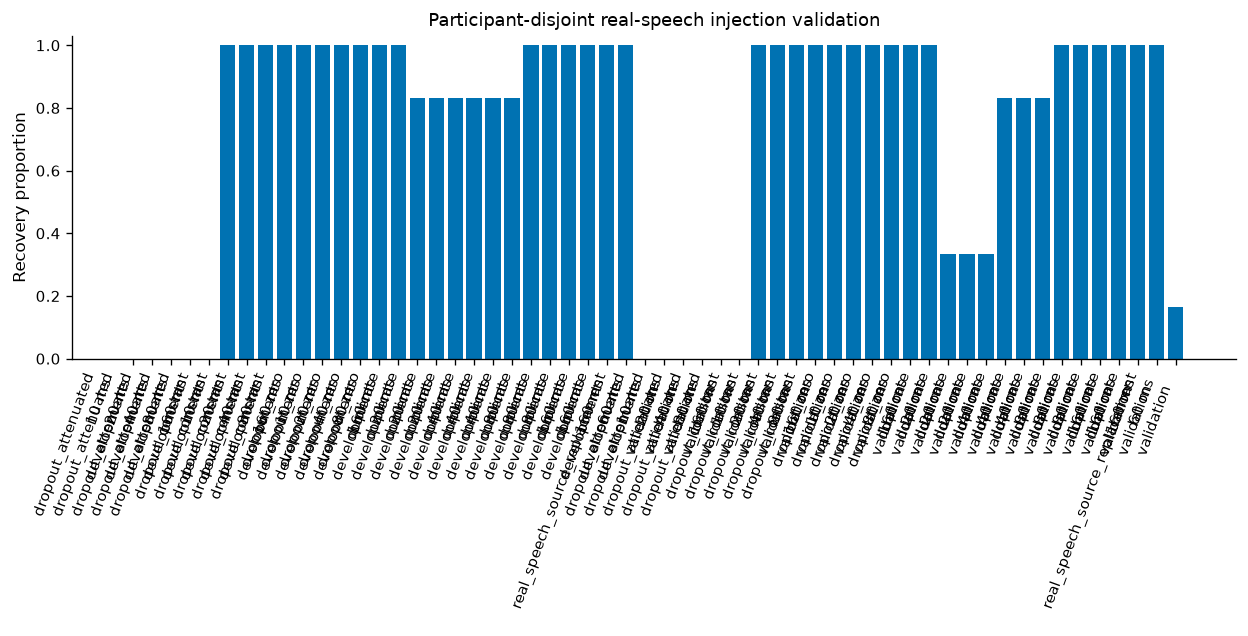

In [9]:
REAL_RESULT_COLUMNS = [
    "logical_recording_id", "qtemp_subject_id", "validation_split", "mechanism",
    "dose", "dose_unit", "perturbation_fraction_rms", "detected",
    "boundary_recall", "matched_event_count", "start_error_ms", "end_error_ms",
    "accepted_dropout", "accepted_duplicate", "accepted_splice",
    "background_event_count", "native_sample_rate_hz", "native_channels",
    "codec_name", "donor_recording_id",
]
real_validation_sources = pd.DataFrame()
real_injection_results = pd.DataFrame(columns=REAL_RESULT_COLUMNS)
real_validation_summary = pd.DataFrame()
real_validation_errors = pd.DataFrame(columns=["logical_recording_id", "stage", "error_type", "message"])


reused_v03_real_evidence = False

if REUSE_VALIDATED_V03_EVIDENCE:
    previous_manifest_path = (
        DEVELOPMENT_STAGE
        / "audit"
        / "qtemp_v03_candidate_manifest.json"
    )
    previous_results_stem = (
        DEVELOPMENT_STAGE
        / "tables"
        / "qtemp_v03_real_speech_injection_results"
    )
    previous_sources_stem = (
        DEVELOPMENT_STAGE
        / "tables"
        / "qtemp_v03_real_speech_validation_sources"
    )
    previous_errors_stem = (
        DEVELOPMENT_STAGE
        / "audit"
        / "qtemp_v03_real_speech_validation_errors"
    )

    try:
        if previous_manifest_path.exists():
            previous_manifest = json.loads(
                previous_manifest_path.read_text(encoding="utf-8")
            )
            current_hash = sha256_file(
                ROOT / "src/paper1_qc/qtemp.py"
            )
            manifest_hash = previous_manifest.get(
                "implementation_sha256"
            )
            parameter_match = (
                json.dumps(
                    previous_manifest.get("parameters"),
                    sort_keys=True,
                )
                == json.dumps(
                    PARAMETERS.to_dict(),
                    sort_keys=True,
                )
            )

            if (
                manifest_hash == current_hash
                and parameter_match
            ):
                real_injection_results = read_table(
                    previous_results_stem
                )
                real_validation_sources = read_table(
                    previous_sources_stem
                )
                real_validation_errors = read_table(
                    previous_errors_stem
                )

                required_columns = set(
                    REAL_RESULT_COLUMNS
                )
                if (
                    required_columns.issubset(
                        real_injection_results.columns
                    )
                    and len(real_injection_results)
                    and len(real_validation_sources)
                ):
                    reused_v03_real_evidence = True
                    save_table_bundle(
                        real_injection_results,
                        TABLES,
                        f"{PREFIX}_real_speech_injection_results",
                    )
                    save_table_bundle(
                        real_validation_sources,
                        TABLES,
                        f"{PREFIX}_real_speech_validation_sources",
                    )
                    save_table_bundle(
                        real_validation_errors,
                        AUDIT,
                        f"{PREFIX}_real_speech_validation_errors",
                    )
                    print(
                        "Reused hash-compatible v0.3 "
                        "real-speech validation evidence."
                    )
    except Exception as exc:
        print(
            "Could not reuse v0.3 real-speech evidence; "
            f"recomputing. {type(exc).__name__}: {exc}"
        )
        reused_v03_real_evidence = False


def _event_background_count(event_ledger, truth_points, tolerance_sec=0.02):
    if not len(event_ledger):
        return 0
    truth_points = np.atleast_1d(np.asarray(truth_points, dtype=float))
    near = np.zeros(len(event_ledger), dtype=bool)
    for point in truth_points:
        near |= event_ledger["start_sec"].sub(point).abs().le(tolerance_sec).to_numpy()
    return int((~near).sum())


def _match_interval_or_points(extraction, event_type, start, end=None, points=None, tolerance_ms=10.0):
    if points is not None:
        matched = match_events_to_truth_points(extraction.event_ledger, event_type=event_type, truth_times_sec=points, tolerance_ms=tolerance_ms)
        return {
            "detected": bool(matched["boundary_recall"] == 1.0),
            "boundary_recall": matched["boundary_recall"],
            "matched_event_count": matched["matched_boundary_count"],
            "start_error_ms": matched["median_abs_error_ms"],
            "end_error_ms": matched["maximum_abs_error_ms"],
        }
    matched = match_events_to_truth(extraction.event_ledger, event_type=event_type, truth_start_sec=start, truth_end_sec=end, tolerance_ms=tolerance_ms)
    return {**matched, "boundary_recall": float(bool(matched["detected"]))}


def _select_strong_foreign_replacement(target, donor, injection_sample, replacement_n, fs):
    target_arr=np.asarray(target,dtype=float); donor_arr=np.asarray(donor,dtype=float)
    if target_arr.ndim==1: target_arr=target_arr[:,None]
    if donor_arr.ndim==1: donor_arr=donor_arr[:,None]
    donor_mono=np.mean(donor_arr,axis=1)
    if len(donor_mono) < replacement_n + 2: raise ValueError("donor clip too short")
    target_segment=target_arr[injection_sample:injection_sample+replacement_n]
    target_rms=np.sqrt(np.mean(target_segment**2,axis=0))
    offsets=np.arange(0,len(donor_mono)-replacement_n,max(1,int(round(.010*fs))),dtype=int)
    if len(offsets)>120: offsets=offsets[np.linspace(0,len(offsets)-1,120,dtype=int)]
    scores=[]; candidates=[]
    left_sample=target_arr[injection_sample-1]; right_sample=target_arr[min(len(target_arr)-1,injection_sample+replacement_n)]
    for offset in offsets:
        segment=donor_mono[offset:offset+replacement_n]
        scale=target_rms/max(np.sqrt(np.mean(segment**2)),1e-12)
        candidate=segment[:,None]*scale[None,:]
        endpoint=np.mean(np.abs(candidate[0]-left_sample)+np.abs(candidate[-1]-right_sample))/max(float(np.mean(target_rms)),1e-12)
        scores.append(endpoint); candidates.append(candidate)
    best=candidates[int(np.argmax(scores))]
    return best[:,0] if np.asarray(target).ndim==1 else best


if RUN_REAL_SPEECH_INJECTION and not reused_v03_real_evidence:
    ffmpeg, ffprobe = shutil.which("ffmpeg"), shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError("ffmpeg and ffprobe are required")

    selection = frozen["recordings"].copy()
    selection["qtemp_subject_id"] = selection["qtemp_subject_id"].astype(str)
    selection["logical_recording_id"] = selection["logical_recording_id"].astype(str)
    subject_hash = selection["qtemp_subject_id"].map(stable_hash_fraction)
    selection["validation_split"] = np.where(subject_hash < 0.5, "development", "validation")
    selection["selection_hash"] = selection["logical_recording_id"].map(stable_hash_fraction)
    selection = (
        selection.sort_values(["qtemp_subject_id", "selection_hash"])
        .drop_duplicates("qtemp_subject_id", keep="first")
        .reset_index(drop=True)
    )
    per_split = max(2, REAL_SPEECH_SOURCE_RECORDINGS // 2)
    selected = pd.concat(
        [
            local.sort_values("selection_hash").head(per_split)
            for _, local in selection.groupby("validation_split", sort=True)
        ],
        ignore_index=True,
    )
    if selected.groupby("qtemp_subject_id")["validation_split"].nunique().gt(1).any():
        raise RuntimeError("Participant-disjoint split violation")
    real_validation_sources = selected[["logical_recording_id", "qtemp_subject_id", "validation_split", "selection_hash", "media_path"]].copy()
    save_table_bundle(real_validation_sources, TABLES, f"{PREFIX}_real_speech_validation_sources")

    clip_cache, error_rows = {}, []
    for row in selected.itertuples(index=False):
        recording_id = str(row.logical_recording_id)
        try:
            views = decode_audio_views(media_path_for(row), ffmpeg=ffmpeg, ffprobe=ffprobe)
            task, speech = task_intervals_for(recording_id), speech_intervals_for(recording_id)
            if not task:
                raise ValueError("no task interval")
            clip_start, clip_end, injection_sample_absolute = choose_active_site(views.native, views.sample_rate_native, task[0], speech)
            clip = views.native[clip_start:clip_end].copy()
            fs = int(views.sample_rate_native)
            injection_sample = int(injection_sample_absolute - clip_start)
            clip_duration = len(clip) / fs
            clip_speech = [
                TimeInterval(max(0.0, item.start_sec - clip_start/fs), min(clip_duration, item.end_sec - clip_start/fs))
                for item in speech if item.end_sec > clip_start/fs and item.start_sec < clip_end/fs
            ]
            clip_cache[recording_id] = {
                "clip": clip, "fs": fs, "injection_sample": injection_sample,
                "speech": clip_speech, "task": [TimeInterval(0.0, clip_duration)],
                "split": row.validation_split, "subject": row.qtemp_subject_id,
                "codec": views.probe.get("codec_name"),
            }
        except Exception as exc:
            error_rows.append({"logical_recording_id": recording_id, "stage": "real_speech_clip_selection", "error_type": type(exc).__name__, "message": str(exc)})

    result_rows, available_ids = [], sorted(clip_cache)
    for recording_id in available_ids:
        item = clip_cache[recording_id]
        clip, fs, injection_sample = item["clip"], item["fs"], item["injection_sample"]
        injection_sec = injection_sample / fs
        common = {
            "logical_recording_id": recording_id, "qtemp_subject_id": item["subject"],
            "validation_split": item["split"], "native_sample_rate_hz": fs,
            "native_channels": clip.shape[1] if clip.ndim == 2 else 1,
            "codec_name": item["codec"], "donor_recording_id": "",
        }
        try:
            baseline = extract_qtemp(clip, fs, analysis_intervals=item["task"], speech_intervals=item["speech"], logical_recording_id=f"{recording_id}__baseline")
            result_rows.append({**common, "mechanism": "baseline_unmodified", "dose": 0, "dose_unit": "none", "perturbation_fraction_rms": np.nan, "detected": np.nan, "boundary_recall": np.nan, "matched_event_count": np.nan, "start_error_ms": np.nan, "end_error_ms": np.nan, "accepted_dropout": baseline.recording["qtemp_dropout_accepted_event_count"], "accepted_duplicate": baseline.recording["qtemp_frozen_audio_accepted_event_count"], "accepted_splice": baseline.recording["qtemp_splice_accepted_event_count"], "background_event_count": int(len(baseline.event_ledger))})

            for mode in ["zero", "constant", "attenuated"]:
                for duration_ms in [10, 20, 40, 80, 160]:
                    kwargs = {"mode": mode}
                    if mode == "constant": kwargs["constant_value"] = 1e-5
                    elif mode == "attenuated": kwargs["attenuation_db"] = -40
                    perturbed = inject_dropout(clip, fs, injection_sec, duration_ms, **kwargs)
                    extraction = extract_qtemp(perturbed, fs, analysis_intervals=item["task"], speech_intervals=item["speech"], logical_recording_id=f"{recording_id}__dropout", enabled_event_types=("dropout",))
                    truth_end = injection_sec + duration_ms/1000
                    matched = _match_interval_or_points(extraction, "dropout", injection_sec, truth_end, tolerance_ms=5)
                    result_rows.append({**common, "mechanism": f"dropout_{mode}", "dose": duration_ms, "dose_unit": "ms", "perturbation_fraction_rms": np.nan, **matched, "accepted_dropout": extraction.recording["qtemp_dropout_accepted_event_count"], "accepted_duplicate": 0, "accepted_splice": 0, "background_event_count": _event_background_count(extraction.event_ledger, [injection_sec, truth_end])})

            clip_rms = float(np.sqrt(np.mean(np.asarray(clip, dtype=float)**2)))
            for duration_ms in [20, 40, 80, 160]:
                for fraction in [0.0, 5e-4, 5e-3]:
                    source_start = injection_sec - duration_ms/1000
                    perturbed = inject_consecutive_duplicate(clip, fs, source_start, duration_ms, perturbation_sd=fraction*clip_rms, random_seed=PARAMETERS.random_seed)
                    extraction = extract_qtemp(perturbed, fs, analysis_intervals=item["task"], speech_intervals=item["speech"], logical_recording_id=f"{recording_id}__duplicate", enabled_event_types=("frozen_audio",))
                    truth_start, truth_end = injection_sec, injection_sec + duration_ms/1000
                    matched = _match_interval_or_points(extraction, "frozen_audio", truth_start, truth_end, tolerance_ms=10)
                    result_rows.append({**common, "mechanism": "duplicate", "dose": duration_ms, "dose_unit": "ms", "perturbation_fraction_rms": fraction, **matched, "accepted_dropout": 0, "accepted_duplicate": extraction.recording["qtemp_frozen_audio_accepted_event_count"], "accepted_splice": 0, "background_event_count": _event_background_count(extraction.event_ledger, [truth_start, truth_end])})

            # Smooth deletion remains a nonblocking identifiability characterization.
            for deleted_ms in [15, 40, 80]:
                perturbed, join_sec = inject_splice_delete(clip, fs, injection_sec, deleted_ms)
                extraction = extract_qtemp(perturbed, fs, analysis_intervals=[TimeInterval(0, len(perturbed)/fs)], logical_recording_id=f"{recording_id}__smooth_delete", enabled_event_types=("splice",))
                matched = _match_interval_or_points(extraction, "splice", join_sec, tolerance_ms=10)
                result_rows.append({**common, "mechanism": "smooth_deletion_characterization", "dose": deleted_ms, "dose_unit": "ms", "perturbation_fraction_rms": np.nan, **matched, "accepted_dropout": 0, "accepted_duplicate": 0, "accepted_splice": extraction.recording["qtemp_splice_accepted_event_count"], "background_event_count": _event_background_count(extraction.event_ledger, [join_sec])})

            donor_ids = [value for value in available_ids if value != recording_id and clip_cache[value]["split"] == item["split"] and str(clip_cache[value]["subject"]) != str(item["subject"])]
            if donor_ids:
                donor_id = sorted(donor_ids, key=lambda value: stable_hash_fraction(recording_id + "|" + value))[0]
                donor = clip_cache[donor_id]
                donor_clip = donor["clip"]
                if donor["fs"] != fs:
                    donor_clip = signal.resample_poly(donor_clip, up=fs, down=donor["fs"], axis=0)
                replacement_n = min(int(round(0.060*fs)), len(donor_clip)//4, len(clip)-injection_sample-1)
                donor_segment = _select_strong_foreign_replacement(clip, donor_clip, injection_sample, replacement_n, fs)
                switched, boundaries = inject_splice_replace(clip, fs, injection_sec, donor_segment)
                extraction = extract_qtemp(switched, fs, analysis_intervals=item["task"], speech_intervals=item["speech"], logical_recording_id=f"{recording_id}__source_replacement", enabled_event_types=("splice",))
                matched = _match_interval_or_points(extraction, "splice", injection_sec, points=boundaries, tolerance_ms=10)
                result_rows.append({**common, "donor_recording_id": donor_id, "mechanism": "real_speech_source_replacement", "dose": 60, "dose_unit": "ms", "perturbation_fraction_rms": np.nan, **matched, "accepted_dropout": 0, "accepted_duplicate": 0, "accepted_splice": extraction.recording["qtemp_splice_accepted_event_count"], "background_event_count": _event_background_count(extraction.event_ledger, boundaries)})
        except Exception as exc:
            error_rows.append({"logical_recording_id": recording_id, "stage": "real_speech_injection", "error_type": type(exc).__name__, "message": str(exc)})

    real_injection_results = pd.DataFrame(result_rows, columns=REAL_RESULT_COLUMNS)
    real_validation_errors = pd.DataFrame(error_rows, columns=real_validation_errors.columns)
    save_table_bundle(real_injection_results, TABLES, f"{PREFIX}_real_speech_injection_results")
    save_table_bundle(real_validation_errors, AUDIT, f"{PREFIX}_real_speech_validation_errors")

if len(real_injection_results):
    evaluated = real_injection_results.loc[real_injection_results["mechanism"].ne("baseline_unmodified")]
    real_validation_summary = evaluated.groupby(["validation_split", "mechanism", "dose", "dose_unit", "perturbation_fraction_rms"], dropna=False, as_index=False).agg(source_recordings=("logical_recording_id", "nunique"), recovery=("detected", "mean"), boundary_recall=("boundary_recall", "mean"), median_abs_start_error_ms=("start_error_ms", lambda value: np.nanmedian(np.abs(value)) if value.notna().any() else np.nan), background_events=("background_event_count", "sum"))
    save_table_bundle(real_validation_summary, TABLES, f"{PREFIX}_real_speech_injection_summary")


def _heldout_recovery(pattern, extra_mask=None, column="detected"):
    if not len(real_injection_results): return np.nan
    mask = (
        real_injection_results["validation_split"].eq("validation")
        & real_injection_results["mechanism"].astype("string").str.contains(
            pattern,
            regex=True,
            na=False,
        )
    )
    if extra_mask is not None: mask &= extra_mask(real_injection_results)
    local = pd.to_numeric(real_injection_results.loc[mask, column], errors="coerce").dropna()
    return float(local.mean()) if len(local) else np.nan

heldout_dropout = _heldout_recovery(r"dropout_(?:zero|constant)")
heldout_attenuated = _heldout_recovery(r"dropout_attenuated")
heldout_duplicate = _heldout_recovery(
    r"^duplicate$",
    lambda f: (
        pd.to_numeric(f["dose"], errors="coerce").ge(
            FINAL_DUPLICATE_MIN_DURATION_MS
        )
        & pd.to_numeric(
            f["perturbation_fraction_rms"],
            errors="coerce",
        ).le(5e-4)
    ),
)
heldout_splice = _heldout_recovery(r"real_speech_source_replacement", column="boundary_recall")
participant_split_ok = bool(len(real_validation_sources)) and real_validation_sources.groupby("qtemp_subject_id")["validation_split"].nunique().max() == 1

real_injection_checks = validation_frame([
    ValidationCheck("real_speech", "development and participant-disjoint validation strata are both present", bool(len(real_injection_results)) and set(real_injection_results["validation_split"].dropna()) == {"development", "validation"} and participant_split_ok, str(sorted(real_injection_results["validation_split"].dropna().unique())) if len(real_injection_results) else "NOT RUN", "participant-disjoint development + validation", "repair identity/split selection"),
    ValidationCheck("real_speech", "held-out exact/constant dropout recovery", np.isfinite(heldout_dropout) and heldout_dropout >= 0.85, f"recovery={heldout_dropout:.3f}" if np.isfinite(heldout_dropout) else "NOT RUN", ">=0.85", "revise support or narrow scope"),
    ValidationCheck("real_speech", "held-out attenuated speech is not classified as dropout", np.isfinite(heldout_attenuated) and heldout_attenuated == 0, f"detection={heldout_attenuated:.3f}" if np.isfinite(heldout_attenuated) else "NOT RUN", "0", "tighten low-information evidence"),
    ValidationCheck(
        "real_speech",
        "held-out exact/near-exact decoded repetition recovery at >=40 ms",
        np.isfinite(heldout_duplicate) and heldout_duplicate >= 0.85,
        (
            f"recovery={heldout_duplicate:.3f}"
            if np.isfinite(heldout_duplicate)
            else "NOT RUN"
        ),
        ">=0.85",
        "revise detector or narrow duration/perturbation scope",
    ),
    ValidationCheck(
        "real_speech",
        (
            "failed held-out source-replacement hypothesis is explicitly "
            "resolved by dropping the splice-like feature"
        ),
        (
            np.isfinite(heldout_splice)
            and "qtemp_splice_discontinuity_rate_per_min"
            in DROPPED_ANALYSIS_FEATURES
        ),
        (
            f"boundary recall={heldout_splice:.3f}; "
            "final disposition=dropped"
            if np.isfinite(heldout_splice)
            else "NOT RUN"
        ),
        "held-out performance reported and splice excluded",
        (
            "retain the failed performance audit and prohibit splice from "
            "final/downstream feature tables"
        ),
    ),
    ValidationCheck("real_speech", "real-speech validation completes without errors", bool(len(real_injection_results)) and len(real_validation_errors) == 0, f"errors={len(real_validation_errors)}", "0", "repair media/clip adapter"),
])

display(real_validation_sources); display(real_validation_summary); display(real_validation_errors); display(real_injection_checks)
if len(real_validation_summary):
    plot_data = real_validation_summary.loc[real_validation_summary["mechanism"].isin(["dropout_zero", "dropout_constant", "dropout_attenuated", "duplicate", "real_speech_source_replacement"])].copy()
    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    labels = plot_data["mechanism"].astype(str) + "\n" + plot_data["dose"].astype(str) + " " + plot_data["dose_unit"].astype(str) + "\n" + plot_data["validation_split"].astype(str)
    ax.bar(np.arange(len(plot_data)), plot_data["recovery"], color=OKABE_ITO["blue"])
    ax.set_xticks(np.arange(len(plot_data)), labels, rotation=70, ha="right")
    ax.set(ylabel="Recovery proportion", ylim=(0, 1.03), title="Participant-disjoint real-speech injection validation")
    fig.tight_layout()
    save_publication_figure(fig, FIGURES, "figure_qtemp_real_speech_injection", caption="Recovery of injected dropout-like, near-exact consecutive repetition, and finite foreign-source replacement events on participant-disjoint real Bamboo speech clips. Smooth deletion and attenuation are explicit characterization/negative series.", alt_text="Recovery proportions for QTEMP mechanisms in development and held-out validation speech clips.")
    plt.show()


## 9. Native-versus-transformed signal-chain characterization


Reused v0.3 signal-chain characterization.


,case,target_event_type,signal_view,sample_rate_hz,channels,dropout_events,duplicate_events,splice_events,qtemp_dropout_duration_fraction,qtemp_dropout_event_rate_per_min,qtemp_frozen_audio_duration_fraction,qtemp_frozen_audio_event_rate_per_min,qtemp_splice_discontinuity_rate_per_min
0,dropout_channel_1_only,dropout,native_decoded_reference,16000,2,1,0,0,0.005128,7.692308,0.000000,0.000000,0.000000
1,dropout_channel_1_only,dropout,mono_average,16000,1,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000
2,dropout_channel_1_only,dropout,peak_normalized,16000,2,1,0,0,0.005128,7.692308,0.000000,0.000000,0.000000
3,dropout_channel_1_only,dropout,per_channel_dc_removed,16000,2,1,0,0,0.005128,7.692308,0.000000,0.000000,0.000000
4,dropout_channel_1_only,dropout,resampled_8k,8000,2,1,0,0,0.004824,7.692308,0.000000,0.000000,0.000000
5,dropout_channel_1_only,dropout,resampled_48k,48000,2,1,0,0,0.004979,7.692308,0.000000,0.000000,0.000000
6,dropout_channel_1_only,dropout,codec_opus,48000,2,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000
7,dropout_channel_1_only,dropout,codec_aac,16000,2,1,0,0,0.002051,7.692308,0.000000,0.000000,0.000000
8,duplicate_both_channels,frozen_audio,native_decoded_reference,16000,2,0,1,0,0.000000,0.000000,0.010256,7.692308,0.000000
9,duplicate_both_channels,frozen_audio,mono_average,16000,1,0,1,0,0.000000,0.000000,0.010256,7.692308,0.000000


,case,signal_view,error_type,message


,layer,check,passed,observed,required,action_if_failed,blocking
0,signal_chain,native channel-specific evidence can be erased by mono conversion,True,"native=1.0, mono=0.0",native positive; mono zero,repair channel-specific control or native-channel contract,True
1,signal_chain,"resampling, normalization, DC removal, and mono conversion are characterized",True,"['codec_aac', 'codec_opus', 'mono_average', 'native_decoded_reference', 'peak_normalized', 'per_channel_dc_removed', 'resampled_48k', 'resampled_8k']","['mono_average', 'native_decoded_reference', 'peak_normalized', 'per_channel_dc_removed', 'resampled_48k', 'resampled_8k']",complete transformation grid,True
2,signal_chain,codec round-trip observability is recorded when encoders are available,True,"views=['codec_aac', 'codec_opus', 'mono_average', 'native_decoded_reference', 'peak_normalized', 'per_channel_dc_removed', 'resampled_48k', 'resampled_8k']; errors=0",codec rows or explicit encoder errors,install/resolve ffmpeg codec support or document unavailability,False


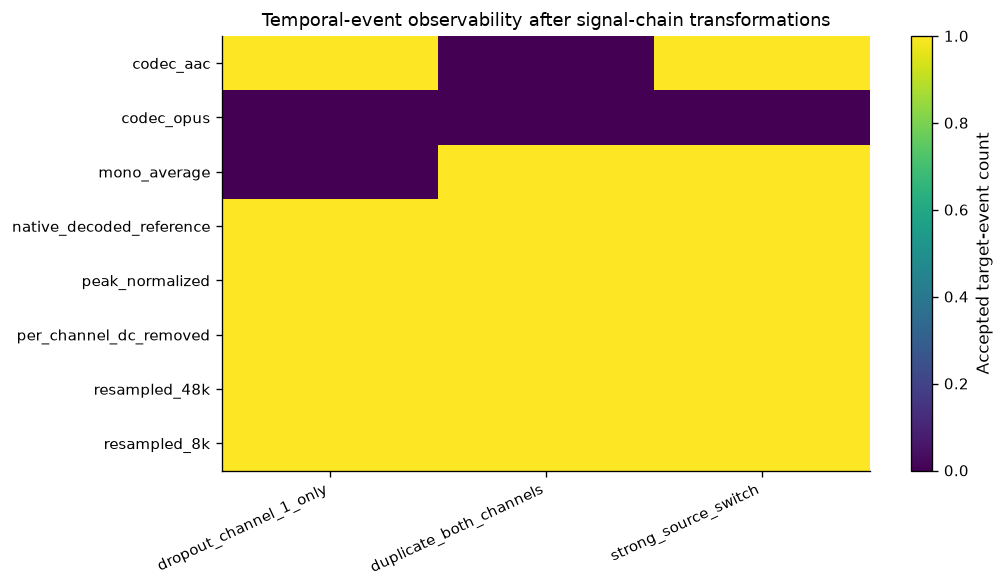

In [10]:
def ffmpeg_roundtrip(waveform, fs, codec_name):
    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if not ffmpeg or not ffprobe:
        raise RuntimeError("ffmpeg/ffprobe unavailable")
    values = np.asarray(waveform)
    with TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        source_path = tmp / "source.wav"
        sf.write(source_path, values, fs, subtype="PCM_16")
        if codec_name == "opus":
            encoded = tmp / "roundtrip.webm"
            command = [
                ffmpeg, "-y", "-v", "error", "-i", str(source_path),
                "-c:a", "libopus", "-b:a", "64k", str(encoded),
            ]
        elif codec_name == "aac":
            encoded = tmp / "roundtrip.m4a"
            command = [
                ffmpeg, "-y", "-v", "error", "-i", str(source_path),
                "-c:a", "aac", "-b:a", "96k", str(encoded),
            ]
        else:
            raise ValueError(codec_name)
        completed = subprocess.run(command, capture_output=True, text=True)
        if completed.returncode != 0:
            raise RuntimeError(completed.stderr)
        decoded = decode_audio_views(encoded, ffmpeg=ffmpeg, ffprobe=ffprobe)
        return decoded.native, decoded.sample_rate_native


SIGNAL_CHAIN_COLUMNS = [
    "case", "target_event_type", "signal_view", "sample_rate_hz", "channels",
    "dropout_events", "duplicate_events", "splice_events", *ANALYSIS_FEATURES,
]
signal_chain_rows = []
signal_chain_error_rows = []

reused_v03_signal_chain = False

if REUSE_VALIDATED_V03_EVIDENCE:
    previous_signal_chain_stem = (
        DEVELOPMENT_STAGE
        / "tables"
        / "qtemp_v03_signal_chain_characterization"
    )
    previous_signal_errors_stem = (
        DEVELOPMENT_STAGE
        / "audit"
        / "qtemp_v03_signal_chain_errors"
    )
    try:
        previous_manifest_path = (
            DEVELOPMENT_STAGE
            / "audit"
            / "qtemp_v03_candidate_manifest.json"
        )
        previous_manifest = json.loads(
            previous_manifest_path.read_text(encoding="utf-8")
        )
        current_hash = sha256_file(
            ROOT / "src/paper1_qc/qtemp.py"
        )
        compatible = (
            previous_manifest.get("implementation_sha256")
            == current_hash
            and json.dumps(
                previous_manifest.get("parameters"),
                sort_keys=True,
            )
            == json.dumps(
                PARAMETERS.to_dict(),
                sort_keys=True,
            )
        )
        if not compatible:
            raise ValueError(
                "v0.3 signal-chain evidence is not hash/parameter compatible"
            )
        signal_chain = read_table(
            previous_signal_chain_stem
        )
        signal_chain_errors = read_table(
            previous_signal_errors_stem
        )
        if len(signal_chain):
            reused_v03_signal_chain = True
            save_table_bundle(
                signal_chain,
                TABLES,
                f"{PREFIX}_signal_chain_characterization",
            )
            save_table_bundle(
                signal_chain_errors,
                AUDIT,
                f"{PREFIX}_signal_chain_errors",
            )
            print(
                "Reused v0.3 signal-chain characterization."
            )
    except Exception as exc:
        print(
            "Could not reuse v0.3 signal-chain evidence; "
            f"recomputing. {type(exc).__name__}: {exc}"
        )
        reused_v03_signal_chain = False
if RUN_SIGNAL_CHAIN_CHARACTERIZATION and not reused_v03_signal_chain:
    base = np.column_stack([stochastic_carrier(seed=77), stochastic_carrier(seed=78)])
    switched, _ = source_switch_splice(8800)
    switched = np.column_stack([switched, switched])
    cases = {
        "dropout_channel_1_only": (
            inject_dropout(base, FS_SYNTH, 3.0, 40, mode="zero", channel=1),
            "dropout",
        ),
        "duplicate_both_channels": (
            inject_consecutive_duplicate(base, FS_SYNTH, 2.0, 80),
            "frozen_audio",
        ),
        "strong_source_switch": (switched, "splice"),
    }
    for case_name, (native, target_event_type) in cases.items():
        transformed_views = {
            "native_decoded_reference": (native, FS_SYNTH),
            "mono_average": (native.mean(axis=1), FS_SYNTH),
            "peak_normalized": (native / max(np.max(np.abs(native)), 1e-12), FS_SYNTH),
            "per_channel_dc_removed": (native - native.mean(axis=0, keepdims=True), FS_SYNTH),
            "resampled_8k": (signal.resample_poly(native, up=1, down=2, axis=0), FS_SYNTH // 2),
            "resampled_48k": (signal.resample_poly(native, up=3, down=1, axis=0), FS_SYNTH * 3),
        }
        for codec in ["opus", "aac"]:
            try:
                transformed_views[f"codec_{codec}"] = ffmpeg_roundtrip(native, FS_SYNTH, codec)
            except Exception as exc:
                signal_chain_error_rows.append({
                    "case": case_name,
                    "signal_view": f"codec_{codec}",
                    "error_type": type(exc).__name__,
                    "message": str(exc),
                })
        for view_name, (waveform, view_fs) in transformed_views.items():
            extraction = extract_qtemp(
                waveform,
                view_fs,
                logical_recording_id=f"{case_name}-{view_name}",
            )
            signal_chain_rows.append({
                "case": case_name,
                "target_event_type": target_event_type,
                "signal_view": view_name,
                "sample_rate_hz": view_fs,
                "channels": waveform.shape[1] if np.asarray(waveform).ndim == 2 else 1,
                "dropout_events": extraction.recording["qtemp_dropout_accepted_event_count"],
                "duplicate_events": extraction.recording["qtemp_frozen_audio_accepted_event_count"],
                "splice_events": extraction.recording["qtemp_splice_accepted_event_count"],
                **{feature: extraction.recording[feature] for feature in ANALYSIS_FEATURES},
            })

if not reused_v03_signal_chain:
    signal_chain = pd.DataFrame(
        signal_chain_rows,
        columns=SIGNAL_CHAIN_COLUMNS,
    )
    signal_chain_errors = pd.DataFrame(
        signal_chain_error_rows,
        columns=[
            "case",
            "signal_view",
            "error_type",
            "message",
        ],
    )
    save_table_bundle(
        signal_chain,
        TABLES,
        f"{PREFIX}_signal_chain_characterization",
    )
    save_table_bundle(
        signal_chain_errors,
        AUDIT,
        f"{PREFIX}_signal_chain_errors",
    )

def _chain_count(case, view, column):
    if not len(signal_chain):
        return np.nan
    local = signal_chain.loc[
        signal_chain["case"].eq(case) & signal_chain["signal_view"].eq(view),
        column,
    ]
    return float(local.iloc[0]) if len(local) else np.nan

native_dropout = _chain_count("dropout_channel_1_only", "native_decoded_reference", "dropout_events")
mono_dropout = _chain_count("dropout_channel_1_only", "mono_average", "dropout_events")
required_views = {
    "native_decoded_reference", "mono_average", "peak_normalized",
    "per_channel_dc_removed", "resampled_8k", "resampled_48k",
}

signal_chain_checks = validation_frame([
    ValidationCheck(
        "signal_chain",
        "native channel-specific evidence can be erased by mono conversion",
        np.isfinite(native_dropout) and native_dropout >= 1 and np.isfinite(mono_dropout) and mono_dropout == 0,
        f"native={native_dropout}, mono={mono_dropout}" if np.isfinite(native_dropout) else "NOT RUN",
        "native positive; mono zero",
        "repair channel-specific control or native-channel contract",
    ),
    ValidationCheck(
        "signal_chain",
        "resampling, normalization, DC removal, and mono conversion are characterized",
        bool(len(signal_chain)) and required_views.issubset(set(signal_chain["signal_view"])),
        str(sorted(signal_chain["signal_view"].unique())) if len(signal_chain) else "NOT RUN",
        str(sorted(required_views)),
        "complete transformation grid",
    ),
    ValidationCheck(
        "signal_chain",
        "codec round-trip observability is recorded when encoders are available",
        bool(len(signal_chain)) and (
            {"codec_opus", "codec_aac"}.intersection(set(signal_chain["signal_view"]))
            or len(signal_chain_errors) >= 2
        ),
        f"views={sorted(signal_chain['signal_view'].unique()) if len(signal_chain) else []}; errors={len(signal_chain_errors)}",
        "codec rows or explicit encoder errors",
        "install/resolve ffmpeg codec support or document unavailability",
        blocking=False,
    ),
])

display(signal_chain)
display(signal_chain_errors)
display(signal_chain_checks)

if len(signal_chain):
    plot = signal_chain.copy()
    plot["target_event_count"] = np.select(
        [
            plot["target_event_type"].eq("dropout"),
            plot["target_event_type"].eq("frozen_audio"),
            plot["target_event_type"].eq("splice"),
        ],
        [plot["dropout_events"], plot["duplicate_events"], plot["splice_events"]],
        default=np.nan,
    )
    pivot = plot.pivot(index="signal_view", columns="case", values="target_event_count")
    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    image = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set(title="Temporal-event observability after signal-chain transformations")
    fig.colorbar(image, ax=ax, label="Accepted target-event count")
    fig.tight_layout()
    save_publication_figure(
        fig,
        FIGURES,
        "figure_qtemp_signal_chain_characterization",
        caption="Accepted target-event count after transformations that can preserve, erase, or smear native temporal evidence. Invariance is not assumed.",
        alt_text="Heatmap of accepted target-event counts by transformation and injected temporal mechanism.",
    )
    plt.show()


## 10. Full frozen-cohort native-stream extraction and reconstructable ledgers


In [11]:
import json
import pickle
import shutil
import time as pytime

from concurrent.futures import ThreadPoolExecutor, as_completed
from hashlib import sha256
from pathlib import Path
from types import SimpleNamespace


recording_table = pd.DataFrame()
analysis_feature_table = pd.DataFrame()

candidate_ledger = pd.DataFrame()
disposition_ledger = pd.DataFrame()
event_ledger = pd.DataFrame()
exposure_ledger = pd.DataFrame()

native_inventory = pd.DataFrame()

extraction_errors = pd.DataFrame(
    columns=[
        "logical_recording_id",
        "error_type",
        "message",
        "media_path",
    ]
)


# Ensure runtime directories exist before starting threaded extraction.
CACHE.mkdir(parents=True, exist_ok=True)
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)
AUDIT.mkdir(parents=True, exist_ok=True)


def _safe_row_value(row, field: str, default=""):
    """Return a usable row attribute without propagating missing pandas values."""
    value = getattr(row, field, default)

    if value is None or pd.isna(value):
        return default

    return value


def unavailable_recording_row(
    row,
    path,
    status,
    message="",
):
    """Construct a complete unavailable-status recording row."""
    path = Path(path)

    record = {
        "logical_recording_id": str(
            _safe_row_value(
                row,
                "logical_recording_id",
                "",
            )
        ),
        "qtemp_measurement_version": MEASUREMENT_VERSION,
        "qtemp_subject_id": str(
            _safe_row_value(
                row,
                "qtemp_subject_id",
                "",
            )
        ),
        "file_name": str(
            _safe_row_value(
                row,
                "file_name",
                path.name,
            )
        ),
        "media_path": str(path),
        "qtemp_status": status,
        "qtemp_extraction_error": message,
        "qtemp_native_sample_rate_hz": np.nan,
        "qtemp_native_channel_count": np.nan,
        "qtemp_native_duration_sec": np.nan,
        "qtemp_eligible_duration_sec": np.nan,
        "qtemp_eligible_interval_count": 0,
        "qtemp_runtime_decode_sec": np.nan,
        "qtemp_runtime_detector_sec": np.nan,
        "qtemp_runtime_total_sec": np.nan,
    }

    for feature in RETAINED_ANALYSIS_FEATURES:
        record[feature] = np.nan
        record[f"{feature}_status"] = status

    for prefix in [
        "dropout",
        "frozen_audio",
        "splice",
    ]:
        for suffix in [
            "candidate_count",
            "accepted_candidate_count",
            "indeterminate_candidate_count",
            "rejected_candidate_count",
            "accepted_event_count",
            "rate_ci95_low_per_min",
            "rate_ci95_high_per_min",
        ]:
            record[f"qtemp_{prefix}_{suffix}"] = np.nan

    return record


def _interval_payload(intervals):
    """Create a stable serializable representation of interval support."""
    return [
        [
            round(float(interval.start_sec), 9),
            round(float(interval.end_sec), 9),
        ]
        for interval in intervals
    ]


def _recording_fingerprint(
    recording_id,
    path,
    task,
    speech,
    clipping,
):
    """
    Hash all extraction-relevant inputs.

    A cache entry is reused only when the native file, intervals,
    parameters, and QTEMP implementation are unchanged.
    """
    path = Path(path)
    stat = path.stat()

    implementation_path = ROOT / "src/paper1_qc/qtemp.py"

    payload = {
        "measurement": MEASUREMENT_VERSION,
        "implementation": sha256_file(
            implementation_path
        ),
        "parameters": PARAMETERS.to_dict(),
        "recording_id": str(recording_id),
        "path": str(path.resolve()),
        "size": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
        "task": _interval_payload(task),
        "speech": _interval_payload(speech),
        "qdist": _interval_payload(clipping),
    }

    encoded = json.dumps(
        payload,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")

    return sha256(encoded).hexdigest()


def _cache_path(recording_id):
    """Return a filesystem-safe cache path for one recording."""
    digest = sha256(
        str(recording_id).encode("utf-8")
    ).hexdigest()[:20]

    return CACHE / f"{digest}.pkl"


def _empty_inventory(
    recording_id,
    path,
    *,
    error_message="",
):
    """Construct a native-inventory row for an unavailable recording."""
    path = Path(path)

    return {
        "logical_recording_id": str(recording_id),
        "media_path": str(path),
        "file_exists": bool(path.exists()),
        "file_size_bytes": (
            int(path.stat().st_size)
            if path.exists()
            else np.nan
        ),
        "decode_error": error_message,
        "native_detection_input": False,
        "mono_before_detection": False,
        "resampled_before_detection": False,
        "normalized_before_detection": False,
        "runtime_decode_sec": np.nan,
        "runtime_detector_sec": np.nan,
    }


def _process_one_recording(
    row_dict,
    ffmpeg_path,
    ffprobe_path,
):
    """
    Decode and extract QTEMP features for one recording.

    All recording-specific failures are returned as structured unavailable
    results instead of escaping the worker thread.
    """
    row = SimpleNamespace(**row_dict)

    recording_id = str(
        _safe_row_value(
            row,
            "logical_recording_id",
            "",
        )
    )

    path = Path(
        str(
            _safe_row_value(
                row,
                "media_path",
                "",
            )
        )
    )

    started = pytime.perf_counter()

    try:
        # Resolve through the project helper so relative project paths remain valid.
        path = Path(media_path_for(row))

        if not path.exists():
            raise FileNotFoundError(
                f"Native media file does not exist: {path}"
            )

        task = task_intervals_for(recording_id)

        if not task:
            raise ValueError(
                "No frozen task interval is available"
            )

        speech = speech_intervals_for(recording_id)
        clipping = qdist_clipping_intervals_for(
            recording_id
        )

        fingerprint = _recording_fingerprint(
            recording_id,
            path,
            task,
            speech,
            clipping,
        )

        cache_path = _cache_path(recording_id)

        if (
            REUSE_COHORT_CACHE
            and not FORCE_REEXTRACT
            and cache_path.exists()
        ):
            try:
                with cache_path.open("rb") as handle:
                    cached = pickle.load(handle)

                if (
                    isinstance(cached, dict)
                    and cached.get("fingerprint")
                    == fingerprint
                ):
                    cached = dict(cached)
                    cached["cache_hit"] = True
                    return cached

            except Exception as cache_error:
                # A damaged or obsolete cache entry must not invalidate
                # the recording. Remove it and perform a fresh extraction.
                print(
                    "Ignoring invalid QTEMP cache for "
                    f"{recording_id}: "
                    f"{type(cache_error).__name__}: "
                    f"{cache_error}"
                )

                try:
                    cache_path.unlink(missing_ok=True)
                except Exception:
                    pass

        decode_started = pytime.perf_counter()

        views = decode_audio_views(
            path,
            ffmpeg=ffmpeg_path,
            ffprobe=ffprobe_path,
        )

        decode_sec = (
            pytime.perf_counter()
            - decode_started
        )

        detector_started = pytime.perf_counter()

        extraction = extract_qtemp(
            views.native,
            views.sample_rate_native,
            analysis_intervals=task,
            speech_intervals=speech,
            clipping_event_intervals=clipping,
            logical_recording_id=recording_id,
            native_source_confirmed=True,
            preprocessing_provenance_ok=True,
        )

        detector_sec = (
            pytime.perf_counter()
            - detector_started
        )

        native_array = np.asarray(views.native)

        native_channel_count = (
            int(native_array.shape[1])
            if native_array.ndim == 2
            else 1
        )

        native_duration_sec = (
            float(native_array.shape[0])
            / float(views.sample_rate_native)
        )

        record = {
            **extraction.recording,
            "qtemp_subject_id": str(
                _safe_row_value(
                    row,
                    "qtemp_subject_id",
                    "",
                )
            ),
            "file_name": str(
                _safe_row_value(
                    row,
                    "file_name",
                    path.name,
                )
            ),
            "media_path": str(path),
            "codec_name": views.probe.get(
                "codec_name"
            ),
            "container_format": views.probe.get(
                "container_format"
            ),
            "native_sample_format": views.probe.get(
                "sample_format"
            ),
            "native_channels_probe": views.probe.get(
                "channels"
            ),
            "task_start_sec": float(
                task[0].start_sec
            ),
            "task_end_sec": float(
                task[-1].end_sec
            ),
            "frozen_speech_interval_count": int(
                len(speech)
            ),
            (
                "qdist_clipping_event_count_used_"
                "for_arbitration"
            ): int(len(clipping)),
            "qtemp_extraction_error": "",
            "qtemp_runtime_decode_sec": float(
                decode_sec
            ),
            "qtemp_runtime_detector_sec": float(
                detector_sec
            ),
            "qtemp_runtime_total_sec": float(
                pytime.perf_counter()
                - started
            ),
        }

        inventory = {
            "logical_recording_id": recording_id,
            "media_path": str(path),
            "file_exists": True,
            "file_size_bytes": int(
                path.stat().st_size
            ),
            "codec_name": views.probe.get(
                "codec_name"
            ),
            "container_format": views.probe.get(
                "container_format"
            ),
            "sample_format": views.probe.get(
                "sample_format"
            ),
            "sample_rate_hz": int(
                views.sample_rate_native
            ),
            "channels": native_channel_count,
            "duration_sec": native_duration_sec,
            "decode_warning": views.decode_stderr,
            "native_detection_input": True,
            "mono_before_detection": False,
            "resampled_before_detection": False,
            "normalized_before_detection": False,
            "runtime_decode_sec": float(
                decode_sec
            ),
            "runtime_detector_sec": float(
                detector_sec
            ),
            "runtime_total_sec": float(
                pytime.perf_counter()
                - started
            ),
        }

        result = {
            "fingerprint": fingerprint,
            "record": record,
            "candidate": extraction.candidate_ledger,
            "disposition": extraction.disposition_ledger,
            "event": extraction.event_ledger,
            "exposure": extraction.exposure_ledger,
            "inventory": inventory,
            "error": None,
            "cache_hit": False,
        }

        # Write one complete cache object atomically.
        temporary_cache_path = cache_path.with_suffix(
            ".tmp"
        )

        with temporary_cache_path.open("wb") as handle:
            pickle.dump(
                result,
                handle,
                protocol=pickle.HIGHEST_PROTOCOL,
            )

        temporary_cache_path.replace(cache_path)

        return result

    except Exception as exc:
        status = (
            f"unavailable_"
            f"{type(exc).__name__.lower()}"
        )
        message = str(exc)

        elapsed_sec = (
            pytime.perf_counter()
            - started
        )

        record = unavailable_recording_row(
            row,
            path,
            status,
            message,
        )
        record["qtemp_runtime_total_sec"] = float(
            elapsed_sec
        )

        return {
            "fingerprint": "",
            "record": record,
            "candidate": pd.DataFrame(),
            "disposition": pd.DataFrame(),
            "event": pd.DataFrame(),
            "exposure": pd.DataFrame(),
            "inventory": _empty_inventory(
                recording_id,
                path,
                error_message=(
                    f"{type(exc).__name__}: "
                    f"{message}"
                ),
            ),
            "error": {
                "logical_recording_id": recording_id,
                "error_type": type(exc).__name__,
                "message": message,
                "media_path": str(path),
            },
            "cache_hit": False,
        }


def _unexpected_worker_failure(
    row_dict,
    exc,
):
    """
    Convert an exception escaping the worker wrapper into a structured result.

    This is a final defensive layer. Normally _process_one_recording handles
    all recording-specific exceptions internally.
    """
    row = SimpleNamespace(**row_dict)

    recording_id = str(
        row_dict.get(
            "logical_recording_id",
            "",
        )
    )

    raw_path = row_dict.get(
        "media_path",
        row_dict.get(
            "selected_media_path",
            "",
        ),
    )

    path = Path(
        str(raw_path)
        if raw_path is not None
        else ""
    )

    status = (
        f"unavailable_worker_"
        f"{type(exc).__name__.lower()}"
    )
    message = str(exc)

    return {
        "fingerprint": "",
        "record": unavailable_recording_row(
            row,
            path,
            status,
            message,
        ),
        "candidate": pd.DataFrame(),
        "disposition": pd.DataFrame(),
        "event": pd.DataFrame(),
        "exposure": pd.DataFrame(),
        "inventory": _empty_inventory(
            recording_id,
            path,
            error_message=(
                f"{type(exc).__name__}: "
                f"{message}"
            ),
        ),
        "error": {
            "logical_recording_id": recording_id,
            "error_type": type(exc).__name__,
            "message": message,
            "media_path": str(path),
        },
        "cache_hit": False,
    }


def _write_recording_checkpoint(results):
    """Write a deterministic partial recording-level checkpoint."""
    if not results:
        return

    checkpoint = pd.DataFrame(
        [
            item["record"]
            for item in results
        ]
    )

    if (
        len(checkpoint)
        and "logical_recording_id"
        in checkpoint.columns
    ):
        checkpoint = checkpoint.sort_values(
            "logical_recording_id",
            kind="stable",
        )

    checkpoint.to_csv(
        CHECKPOINTS
        / f"{PREFIX}_recording_checkpoint.csv",
        index=False,
    )


def combine_result_frames(
    results,
    key,
):
    """Combine nonempty DataFrame components from worker results."""
    parts = [
        item[key]
        for item in results
        if (
            isinstance(
                item.get(key),
                pd.DataFrame,
            )
            and len(item[key])
        )
    ]

    if not parts:
        return pd.DataFrame()

    return pd.concat(
        parts,
        ignore_index=True,
        sort=False,
    )


if RUN_COHORT_EXTRACTION:
    ffmpeg_path = shutil.which("ffmpeg")
    ffprobe_path = shutil.which("ffprobe")

    if not ffmpeg_path or not ffprobe_path:
        raise RuntimeError(
            "ffmpeg and ffprobe are required for QTEMP extraction"
        )

    if frozen is None:
        raise RuntimeError(
            "Frozen inputs must be loaded before cohort extraction"
        )

    rows = frozen["recordings"].to_dict(
        orient="records"
    )

    if not rows:
        raise RuntimeError(
            "No eligible frozen recordings were available"
        )

    worker_count = max(
        1,
        min(
            int(COHORT_WORKERS),
            len(rows),
        ),
    )

    results = []
    completed_count = 0

    print(
        f"Starting QTEMP extraction for {len(rows)} recordings "
        f"with {worker_count} worker(s)."
    )

    with ThreadPoolExecutor(
        max_workers=worker_count
    ) as executor:
        future_map = {
            executor.submit(
                _process_one_recording,
                row_dict,
                ffmpeg_path,
                ffprobe_path,
            ): row_dict
            for row_dict in rows
        }

        for future in as_completed(future_map):
            row_dict = future_map[future]

            try:
                result = future.result()
            except Exception as exc:
                result = _unexpected_worker_failure(
                    row_dict,
                    exc,
                )

            results.append(result)
            completed_count += 1

            if (
                completed_count
                % int(CHECKPOINT_EVERY)
                == 0
                or completed_count
                == len(rows)
            ):
                _write_recording_checkpoint(
                    results
                )

                cache_hits = sum(
                    bool(item.get("cache_hit"))
                    for item in results
                )

                failures = sum(
                    item.get("error") is not None
                    for item in results
                )

                print(
                    f"Completed {completed_count}/{len(rows)} "
                    f"(workers={worker_count}, "
                    f"cache_hits={cache_hits}, "
                    f"failures={failures})"
                )

    results.sort(
        key=lambda item: str(
            item["record"][
                "logical_recording_id"
            ]
        )
    )

    recording_table = pd.DataFrame(
        [
            item["record"]
            for item in results
        ]
    )

    candidate_ledger = combine_result_frames(
        results,
        "candidate",
    )
    disposition_ledger = combine_result_frames(
        results,
        "disposition",
    )
    event_ledger = combine_result_frames(
        results,
        "event",
    )
    exposure_ledger = combine_result_frames(
        results,
        "exposure",
    )

    # Finalization retains only analytically supportable event types.
    # The v0.3 development cache may contain splice candidates/events; preserve
    # only a compact audit summary and exclude them from finalization ledgers.
    dropped_event_audit = pd.DataFrame()

    if len(candidate_ledger) and "event_type" in candidate_ledger.columns:
        dropped_candidates = candidate_ledger.loc[
            candidate_ledger["event_type"].astype(str).isin(
                DROPPED_EVENT_TYPES
            )
        ].copy()
        candidate_ledger = candidate_ledger.loc[
            candidate_ledger["event_type"].astype(str).isin(
                RETAINED_EVENT_TYPES
            )
        ].copy()
    else:
        dropped_candidates = pd.DataFrame()

    if len(disposition_ledger) and "event_type" in disposition_ledger.columns:
        dropped_dispositions = disposition_ledger.loc[
            disposition_ledger["event_type"].astype(str).isin(
                DROPPED_EVENT_TYPES
            )
        ].copy()
        disposition_ledger = disposition_ledger.loc[
            disposition_ledger["event_type"].astype(str).isin(
                RETAINED_EVENT_TYPES
            )
        ].copy()
    else:
        dropped_dispositions = pd.DataFrame()

    if len(event_ledger) and "event_type" in event_ledger.columns:
        dropped_events = event_ledger.loc[
            event_ledger["event_type"].astype(str).isin(
                DROPPED_EVENT_TYPES
            )
        ].copy()
        event_ledger = event_ledger.loc[
            event_ledger["event_type"].astype(str).isin(
                RETAINED_EVENT_TYPES
            )
        ].copy()
    else:
        dropped_events = pd.DataFrame()

    # Apply the final, validation-supported repetition scope. The development
    # detector scanned more permissively, but the retained feature accepts only
    # near-exact repeated targets lasting at least 40 ms. This is a deterministic
    # stricter post-filter, so the v0.3 cache remains valid.
    final_duplicate_min_sec = (
        FINAL_DUPLICATE_MIN_DURATION_MS / 1000.0
    )

    def _filter_short_duplicate_rows(frame):
        if (
            not len(frame)
            or "event_type" not in frame.columns
            or "duration_sec" not in frame.columns
        ):
            return frame.copy(), pd.DataFrame()
        duration = pd.to_numeric(
            frame["duration_sec"],
            errors="coerce",
        )
        short = (
            frame["event_type"].astype(str).eq("frozen_audio")
            & duration.lt(final_duplicate_min_sec)
        )
        return (
            frame.loc[~short].copy(),
            frame.loc[short].copy(),
        )

    candidate_ledger, short_duplicate_candidates = (
        _filter_short_duplicate_rows(candidate_ledger)
    )
    disposition_ledger, short_duplicate_dispositions = (
        _filter_short_duplicate_rows(disposition_ledger)
    )
    event_ledger, short_duplicate_events = (
        _filter_short_duplicate_rows(event_ledger)
    )

    duplicate_scope_audit = pd.DataFrame(
        [
            {
                "final_duplicate_min_duration_ms": (
                    FINAL_DUPLICATE_MIN_DURATION_MS
                ),
                "short_candidate_rows_removed": int(
                    len(short_duplicate_candidates)
                ),
                "short_disposition_rows_removed": int(
                    len(short_duplicate_dispositions)
                ),
                "short_accepted_events_removed": int(
                    len(short_duplicate_events)
                ),
                "final_scope": (
                    "near-exact consecutive decoded-waveform repetition "
                    f">= {FINAL_DUPLICATE_MIN_DURATION_MS:.0f} ms"
                ),
            }
        ]
    )
    save_table_bundle(
        duplicate_scope_audit,
        AUDIT,
        f"{PREFIX}_duplicate_scope_audit",
    )

    # Reconstruct the retained recording-level outputs from the final accepted
    # event ledger. This guarantees that the exported table reflects both the
    # splice drop and the >=40 ms repetition scope, not stale cached summaries.
    def _exact_rate_interval(count, exposure_sec, confidence=0.95):
        count = int(count)
        exposure_sec = float(exposure_sec)
        if (
            count < 0
            or not np.isfinite(exposure_sec)
            or exposure_sec <= 0
        ):
            return np.nan, np.nan
        alpha = 1.0 - confidence
        lower_count = (
            0.0
            if count == 0
            else 0.5 * stats.chi2.ppf(
                alpha / 2.0,
                2 * count,
            )
        )
        upper_count = 0.5 * stats.chi2.ppf(
            1.0 - alpha / 2.0,
            2 * (count + 1),
        )
        scale = 60.0 / exposure_sec
        return (
            float(lower_count * scale),
            float(upper_count * scale),
        )

    for row_index, row in recording_table.iterrows():
        if str(row.get("qtemp_status", "")) != "measured":
            continue

        recording_id = str(row["logical_recording_id"])
        exposure_sec = float(
            pd.to_numeric(
                pd.Series(
                    [row.get("qtemp_eligible_duration_sec", np.nan)]
                ),
                errors="coerce",
            ).iloc[0]
        )
        local_events = (
            event_ledger.loc[
                event_ledger["logical_recording_id"]
                .astype(str)
                .eq(recording_id)
            ].copy()
            if len(event_ledger)
            else pd.DataFrame()
        )
        rebuilt = reconstruct_recording_features(
            local_events,
            exposure_sec,
        )

        for feature in RETAINED_ANALYSIS_FEATURES:
            value = float(rebuilt[feature])
            recording_table.loc[row_index, feature] = value
            recording_table.loc[
                row_index,
                f"{feature}_status",
            ] = (
                "measured_positive"
                if value > 0
                else "measured_zero"
            )

        for event_type, prefix in [
            ("dropout", "dropout"),
            ("frozen_audio", "frozen_audio"),
        ]:
            local_candidates = (
                candidate_ledger.loc[
                    candidate_ledger["logical_recording_id"]
                    .astype(str)
                    .eq(recording_id)
                    & candidate_ledger["event_type"]
                    .astype(str)
                    .eq(event_type)
                ]
                if len(candidate_ledger)
                else pd.DataFrame()
            )
            local_dispositions = (
                disposition_ledger.loc[
                    disposition_ledger["logical_recording_id"]
                    .astype(str)
                    .eq(recording_id)
                    & disposition_ledger["event_type"]
                    .astype(str)
                    .eq(event_type)
                ]
                if len(disposition_ledger)
                else pd.DataFrame()
            )
            local_accepted_events = (
                local_events.loc[
                    local_events["event_type"]
                    .astype(str)
                    .eq(event_type)
                ]
                if len(local_events)
                else pd.DataFrame()
            )

            recording_table.loc[
                row_index,
                f"qtemp_{prefix}_candidate_count",
            ] = int(len(local_candidates))
            recording_table.loc[
                row_index,
                f"qtemp_{prefix}_accepted_candidate_count",
            ] = int(
                local_dispositions["disposition"]
                .astype(str)
                .eq("accepted")
                .sum()
            ) if len(local_dispositions) else 0
            recording_table.loc[
                row_index,
                f"qtemp_{prefix}_indeterminate_candidate_count",
            ] = int(
                local_dispositions["disposition"]
                .astype(str)
                .eq("indeterminate")
                .sum()
            ) if len(local_dispositions) else 0
            recording_table.loc[
                row_index,
                f"qtemp_{prefix}_rejected_candidate_count",
            ] = int(
                local_dispositions["disposition"]
                .astype(str)
                .eq("rejected")
                .sum()
            ) if len(local_dispositions) else 0
            accepted_count = int(len(local_accepted_events))
            recording_table.loc[
                row_index,
                f"qtemp_{prefix}_accepted_event_count",
            ] = accepted_count
            rate_low, rate_high = _exact_rate_interval(
                accepted_count,
                exposure_sec,
            )
            recording_table.loc[
                row_index,
                f"qtemp_{prefix}_rate_ci95_low_per_min",
            ] = rate_low
            recording_table.loc[
                row_index,
                f"qtemp_{prefix}_rate_ci95_high_per_min",
            ] = rate_high

        recording_table.loc[
            row_index,
            "qtemp_finalization_revision",
        ] = FINALIZATION_REVISION

    dropped_event_audit = pd.DataFrame(
        [
            {
                "event_type": "splice",
                "candidate_rows_removed": int(len(dropped_candidates)),
                "disposition_rows_removed": int(len(dropped_dispositions)),
                "accepted_events_removed": int(len(dropped_events)),
                "recordings_with_accepted_events_removed": (
                    int(
                        dropped_events["logical_recording_id"].nunique()
                    )
                    if len(dropped_events)
                    and "logical_recording_id" in dropped_events.columns
                    else 0
                ),
                "scientific_disposition": (
                    "DROP_FROM_RETAINED_ANALYSIS: held-out real-speech "
                    "recovery and empirical specificity failed."
                ),
            }
        ]
    )

    save_table_bundle(
        dropped_event_audit,
        AUDIT,
        f"{PREFIX}_dropped_splice_audit_summary",
    )

    native_inventory = pd.DataFrame(
        [
            item["inventory"]
            for item in results
        ]
    )

    error_rows = [
        item["error"]
        for item in results
        if item["error"] is not None
    ]

    extraction_errors = pd.DataFrame(
        error_rows,
        columns=[
            "logical_recording_id",
            "error_type",
            "message",
            "media_path",
        ],
    )

    cache_summary = pd.DataFrame(
        [
            {
                "logical_recording_id": item[
                    "record"
                ][
                    "logical_recording_id"
                ],
                "cache_hit": bool(
                    item.get(
                        "cache_hit",
                        False,
                    )
                ),
                "fingerprint": item.get(
                    "fingerprint",
                    "",
                ),
            }
            for item in results
        ]
    )

    output_frames = [
        (
            recording_table,
            TABLES,
            f"{PREFIX}_recording_features",
        ),
        (
            candidate_ledger,
            TABLES,
            f"{PREFIX}_candidate_ledger",
        ),
        (
            disposition_ledger,
            TABLES,
            (
                f"{PREFIX}_candidate_"
                "disposition_ledger"
            ),
        ),
        (
            event_ledger,
            TABLES,
            f"{PREFIX}_accepted_event_ledger",
        ),
        (
            exposure_ledger,
            TABLES,
            f"{PREFIX}_exposure_ledger",
        ),
        (
            native_inventory,
            TABLES,
            f"{PREFIX}_native_inventory",
        ),
        (
            cache_summary,
            AUDIT,
            f"{PREFIX}_cache_summary",
        ),
        (
            extraction_errors,
            AUDIT,
            f"{PREFIX}_extraction_errors",
        ),
    ]

    for frame, directory, stem in output_frames:
        save_table_bundle(
            frame,
            directory,
            stem,
        )

    analysis_columns = [
        "logical_recording_id",
        "qtemp_subject_id",
        "qtemp_measurement_version",
        "qtemp_finalization_revision",
        "qtemp_native_sample_rate_hz",
        "qtemp_native_channel_count",
        "qtemp_native_duration_sec",
        "qtemp_eligible_duration_sec",
        "qtemp_eligible_interval_count",
        "qtemp_status",
        *RETAINED_ANALYSIS_FEATURES,
        *[
            f"{feature}_status"
            for feature in RETAINED_ANALYSIS_FEATURES
        ],
        *[
            column
            for prefix in [
                "dropout",
                "frozen_audio",
            ]
            for column in [
                (
                    f"qtemp_{prefix}_"
                    "accepted_event_count"
                ),
                (
                    f"qtemp_{prefix}_"
                    "indeterminate_candidate_count"
                ),
                (
                    f"qtemp_{prefix}_"
                    "rate_ci95_low_per_min"
                ),
                (
                    f"qtemp_{prefix}_"
                    "rate_ci95_high_per_min"
                ),
            ]
        ],
    ]

    analysis_feature_table = (
        recording_table[
            [
                column
                for column in analysis_columns
                if column
                in recording_table.columns
            ]
        ].copy()
    )

    save_table_bundle(
        analysis_feature_table,
        TABLES,
        f"{PREFIX}_analysis_features",
    )


expected_ids = (
    set(
        frozen["recordings"][
            "logical_recording_id"
        ].astype(str)
    )
    if frozen is not None
    else set()
)

observed_ids = (
    set(
        recording_table[
            "logical_recording_id"
        ].astype(str)
    )
    if len(recording_table)
    else set()
)

measured_fraction = (
    float(
        recording_table[
            "qtemp_status"
        ].eq("measured").mean()
    )
    if len(recording_table)
    else 0.0
)

runtime_total = (
    float(
        pd.to_numeric(
            recording_table.get(
                "qtemp_runtime_total_sec",
                pd.Series(dtype=float),
            ),
            errors="coerce",
        ).sum()
    )
    if len(recording_table)
    else np.nan
)

ledger_paths = [
    TABLES
    / f"{PREFIX}_candidate_ledger.csv",
    TABLES
    / (
        f"{PREFIX}_candidate_"
        "disposition_ledger.csv"
    ),
    TABLES
    / f"{PREFIX}_accepted_event_ledger.csv",
    TABLES
    / f"{PREFIX}_exposure_ledger.csv",
]

measured_channel_counts = (
    pd.to_numeric(
        recording_table.loc[
            recording_table[
                "qtemp_status"
            ].eq("measured"),
            "qtemp_native_channel_count",
        ],
        errors="coerce",
    )
    if (
        len(recording_table)
        and "qtemp_native_channel_count"
        in recording_table.columns
    )
    else pd.Series(dtype=float)
)

extraction_checks = validation_frame(
    [
        ValidationCheck(
            "extraction",
            (
                "every eligible logical recording "
                "has a status row"
            ),
            bool(expected_ids)
            and observed_ids == expected_ids,
            (
                f"{len(observed_ids)}/"
                f"{len(expected_ids)}"
            ),
            "100%",
            "repair input/status propagation",
        ),
        ValidationCheck(
            "extraction",
            (
                "native measurement completed for "
                "at least 99% of eligible recordings"
            ),
            measured_fraction >= 0.99,
            (
                f"measured="
                f"{measured_fraction:.3f}"
            ),
            ">=0.99",
            "resolve failures",
        ),
        ValidationCheck(
            "extraction",
            (
                "one recording row per "
                "logical ID"
            ),
            bool(len(recording_table))
            and not recording_table[
                "logical_recording_id"
            ].duplicated().any(),
            str(len(recording_table)),
            "unique",
            "repair aggregation",
        ),
        ValidationCheck(
            "extraction",
            (
                "measured recordings retain "
                "native channel geometry"
            ),
            bool(len(recording_table))
            and (
                measured_channel_counts.ge(1).all()
            ),
            (
                str(
                    measured_channel_counts
                    .value_counts()
                    .sort_index()
                    .to_dict()
                )
                if len(measured_channel_counts)
                else "NOT RUN"
            ),
            ">=1",
            "repair decoder",
        ),
        ValidationCheck(
            "extraction",
            (
                "candidate, disposition, "
                "accepted-event, and exposure "
                "ledgers are saved"
            ),
            bool(RUN_COHORT_EXTRACTION)
            and all(
                path.exists()
                for path in ledger_paths
            ),
            str(
                [
                    path.name
                    for path in ledger_paths
                    if path.exists()
                ]
            ),
            "all four",
            "rerun extraction",
        ),
        ValidationCheck(
            "runtime",
            (
                "cohort extraction runtime is "
                "recorded and resumable"
            ),
            (
                bool(len(recording_table))
                and (
                    "qtemp_runtime_total_sec"
                    in recording_table.columns
                )
                and CACHE.exists()
            ),
            (
                f"summed uncached runtime="
                f"{runtime_total:.1f}s"
            ),
            "timed + per-record cache",
            (
                "repair runtime/cache "
                "instrumentation"
            ),
        ),
    ]
)

display(extraction_checks)

if len(recording_table):
    display(
        recording_table[
            "qtemp_status"
        ]
        .value_counts(dropna=False)
        .rename_axis("status")
        .reset_index(name="recordings")
    )
else:
    display(recording_table)

display(
    extraction_errors.head(30)
)

Starting QTEMP extraction for 519 recordings with 4 worker(s).
Completed 25/519 (workers=4, cache_hits=25, failures=0)
Completed 50/519 (workers=4, cache_hits=50, failures=0)
Completed 75/519 (workers=4, cache_hits=75, failures=0)
Completed 100/519 (workers=4, cache_hits=100, failures=0)
Completed 125/519 (workers=4, cache_hits=125, failures=0)
Completed 150/519 (workers=4, cache_hits=150, failures=0)
Completed 175/519 (workers=4, cache_hits=175, failures=0)
Completed 200/519 (workers=4, cache_hits=200, failures=0)
Completed 225/519 (workers=4, cache_hits=225, failures=0)
Completed 250/519 (workers=4, cache_hits=250, failures=0)
Completed 275/519 (workers=4, cache_hits=275, failures=0)
Completed 300/519 (workers=4, cache_hits=300, failures=0)
Completed 325/519 (workers=4, cache_hits=325, failures=0)
Completed 350/519 (workers=4, cache_hits=350, failures=0)
Completed 375/519 (workers=4, cache_hits=375, failures=0)
Completed 400/519 (workers=4, cache_hits=400, failures=0)
Completed 425/5

,layer,check,passed,observed,required,action_if_failed,blocking
0,extraction,every eligible logical recording has a status row,True,519/519,100%,repair input/status propagation,True
1,extraction,native measurement completed for at least 99% of eligible recordings,True,measured=1.000,>=0.99,resolve failures,True
2,extraction,one recording row per logical ID,True,519,unique,repair aggregation,True
3,extraction,measured recordings retain native channel geometry,True,"{1: 517, 2: 2}",>=1,repair decoder,True
4,extraction,"candidate, disposition, accepted-event, and exposure ledgers are saved",True,"['qtemp_v031_candidate_ledger.csv', 'qtemp_v031_candidate_disposition_ledger.csv', 'qtemp_v031_accepted_event_ledger.csv', 'qtemp_v031_exposure_ledger.csv']",all four,rerun extraction,True
5,runtime,cohort extraction runtime is recorded and resumable,True,summed uncached runtime=2114.7s,timed + per-record cache,repair runtime/cache instrumentation,True


,status,recordings
0,measured,519


,logical_recording_id,error_type,message,media_path


## 11. Exact cohort reconstruction and event-exposure audit


In [12]:
reconstruction_rows = []
exposure_rows = []
status_rows = []
if len(recording_table):
    for row in recording_table.itertuples(index=False):
        recording_id = str(row.logical_recording_id)
        if str(row.qtemp_status) != "measured":
            continue
        local_events = (
            event_ledger.loc[event_ledger["logical_recording_id"].eq(recording_id)]
            if len(event_ledger)
            else event_ledger
        )
        rebuilt = reconstruct_recording_features(
            local_events,
            float(row.qtemp_eligible_duration_sec),
        )
        for feature in RETAINED_ANALYSIS_FEATURES:
            value = getattr(row, feature)
            ledger_value = rebuilt[feature]
            reconstruction_rows.append({
                "logical_recording_id": recording_id,
                "feature": feature,
                "recording_value": value,
                "ledger_value": ledger_value,
                "absolute_error": abs(value - ledger_value),
            })
            status_rows.append({
                "logical_recording_id": recording_id,
                "feature": feature,
                "value": value,
                "status": getattr(row, f"{feature}_status"),
                "status_correct": (
                    (value > 0 and getattr(row, f"{feature}_status") == "measured_positive")
                    or (value == 0 and getattr(row, f"{feature}_status") == "measured_zero")
                ),
            })
        local_exposure = (
            exposure_ledger.loc[exposure_ledger["logical_recording_id"].eq(recording_id)]
            if len(exposure_ledger)
            else exposure_ledger
        )
        exposure_rows.append({
            "logical_recording_id": recording_id,
            "recording_eligible_duration_sec": float(row.qtemp_eligible_duration_sec),
            "ledger_eligible_duration_sec": float(local_exposure["duration_sec"].sum()) if len(local_exposure) else 0.0,
        })

cohort_reconstruction = pd.DataFrame(
    reconstruction_rows,
    columns=["logical_recording_id", "feature", "recording_value", "ledger_value", "absolute_error"],
)
cohort_exposure_reconstruction = pd.DataFrame(
    exposure_rows,
    columns=["logical_recording_id", "recording_eligible_duration_sec", "ledger_eligible_duration_sec"],
)
status_audit = pd.DataFrame(
    status_rows,
    columns=["logical_recording_id", "feature", "value", "status", "status_correct"],
)
if len(cohort_exposure_reconstruction):
    cohort_exposure_reconstruction["absolute_error_sec"] = np.abs(
        cohort_exposure_reconstruction["recording_eligible_duration_sec"]
        - cohort_exposure_reconstruction["ledger_eligible_duration_sec"]
    )

save_table_bundle(cohort_reconstruction, TABLES, f"{PREFIX}_cohort_reconstruction_audit")
save_table_bundle(cohort_exposure_reconstruction, TABLES, f"{PREFIX}_exposure_reconstruction_audit")
save_table_bundle(status_audit, TABLES, f"{PREFIX}_status_semantics_audit")

support_geometry_ok = True
if len(event_ledger) and {"support_duration_sec", "span_duration_sec"}.issubset(event_ledger):
    support_geometry_ok = bool(
        (event_ledger["support_duration_sec"] <= event_ledger["span_duration_sec"] + 1e-12).all()
        and (event_ledger["support_duration_sec"] > 0).all()
    )

reconstruction_checks = validation_frame([
    ValidationCheck(
        "reconstruction",
        "all retained measured cohort features reconstruct exactly from accepted events",
        bool(len(cohort_reconstruction)) and cohort_reconstruction["absolute_error"].max() < 1e-12,
        f"max={cohort_reconstruction['absolute_error'].max():.3g}" if len(cohort_reconstruction) else "NOT RUN",
        "<1e-12",
        "repair event aggregation or denominator",
    ),
    ValidationCheck(
        "reconstruction",
        "eligible exposure reconstructs exactly from the exposure ledger",
        bool(len(cohort_exposure_reconstruction)) and cohort_exposure_reconstruction["absolute_error_sec"].max() < 1e-12,
        f"max={cohort_exposure_reconstruction['absolute_error_sec'].max():.3g}" if len(cohort_exposure_reconstruction) else "NOT RUN",
        "<1e-12",
        "repair task/exposure ledger",
    ),
    ValidationCheck(
        "reconstruction",
        "measured-zero and measured-positive statuses match feature values",
        bool(len(status_audit)) and status_audit["status_correct"].all(),
        f"correct={int(status_audit['status_correct'].sum())}/{len(status_audit)}" if len(status_audit) else "NOT RUN",
        "all",
        "repair status propagation",
    ),
    ValidationCheck(
        "reconstruction",
        "accepted event ledger contains accepted events only",
        not len(event_ledger) or event_ledger["disposition"].eq("accepted").all(),
        "accepted only",
        "accepted only",
        "repair ledger separation",
    ),
    ValidationCheck(
        "reconstruction",
        "event support duration is positive and never exceeds enclosing span",
        support_geometry_ok,
        "valid" if support_geometry_ok else "invalid support geometry",
        "valid",
        "repair event support-union aggregation",
    ),
])

display(cohort_reconstruction.groupby("feature")["absolute_error"].agg(["count", "max"]) if len(cohort_reconstruction) else cohort_reconstruction)
display(cohort_exposure_reconstruction.describe() if len(cohort_exposure_reconstruction) else cohort_exposure_reconstruction)
display(status_audit.loc[~status_audit["status_correct"]].head(20) if len(status_audit) else status_audit)
display(reconstruction_checks)


,count,max
feature,,
qtemp_dropout_duration_fraction,519,0.0
qtemp_dropout_event_rate_per_min,519,0.0
qtemp_frozen_audio_duration_fraction,519,0.0
qtemp_frozen_audio_event_rate_per_min,519,0.0


,recording_eligible_duration_sec,ledger_eligible_duration_sec,absolute_error_sec
count,519.000000,519.000000,519.0
mean,44.360460,44.360460,0.0
std,16.958263,16.958263,0.0
min,13.144000,13.144000,0.0
25%,33.704000,33.704000,0.0
50%,37.976000,37.976000,0.0
75%,51.128000,51.128000,0.0
max,161.720000,161.720000,0.0


,logical_recording_id,feature,value,status,status_correct


,layer,check,passed,observed,required,action_if_failed,blocking
0,reconstruction,all retained measured cohort features reconstruct exactly from accepted events,True,max=0,<1e-12,repair event aggregation or denominator,True
1,reconstruction,eligible exposure reconstructs exactly from the exposure ledger,True,max=0,<1e-12,repair task/exposure ledger,True
2,reconstruction,measured-zero and measured-positive statuses match feature values,True,correct=2076/2076,all,repair status propagation,True
3,reconstruction,accepted event ledger contains accepted events only,True,accepted only,accepted only,repair ledger separation,True
4,reconstruction,event support duration is positive and never exceeds enclosing span,True,valid,valid,repair event support-union aggregation,True


## 12. Retained-detector parameter, edge, merge, and availability sensitivity

Native audio is decoded once per selected recording. Only the retained dropout and near-exact repetition detectors are rerun under one-at-a-time parameter changes; the dropped splice detector is excluded from G6 and from the final feature set.


,logical_recording_id,selection_stratum,selection_hash,qtemp_status,qtemp_eligible_duration_sec
0,TIBD94_270_1_20240220_240_PSG_BAMBOO,accepted_event,0.098714,measured,58.776
1,MIBD63_270_1_20240108_240_PSG_BAMBOO,accepted_event,0.285089,measured,71.544
2,TIBD101_1003_2_20240926_240_PSG_BAMBOO,candidate_without_accepted_event,0.009811,measured,64.728
3,TIBD117_1003_1_20241202_240_PSG_BAMBOO,candidate_without_accepted_event,0.047863,measured,40.856
4,TIBD102_270_2_20241112_240_PSG_BAMBOO,candidate_without_accepted_event,0.049248,measured,19.608
5,TIBD107_1003_2_20240703_240_PSG_BAMBOO,candidate_without_accepted_event,0.080815,measured,41.976
6,TIBD67_1003_1_20230111_240_PSG_BAMBOO,event_free,0.002221,measured,40.696
7,CAPT0000072_272_2_20240718_240_PSG_BAMBOO,event_free,0.005059,measured,34.744
8,TIBD33_270_4_20230523_240_PSG_BAMBOO,event_free,0.006802,measured,43.000
9,TIBD68_270_1_20230113_240_PSG_BAMBOO,event_free,0.008266,measured,58.136


,detector,profile,feature,paired_n,finite_pair_n,median_absolute_change,maximum_absolute_change,changed_recording_fraction,zero_to_positive_n,positive_to_zero_n,status_change_fraction
0,dropout,context_20ms,qtemp_dropout_duration_fraction,12,12,0.0,0.011309,0.166667,0,2,0.0
1,dropout,context_20ms,qtemp_dropout_event_rate_per_min,12,12,0.0,4.193224,0.166667,0,2,0.0
2,dropout,context_60ms,qtemp_dropout_duration_fraction,12,12,0.0,0.003924,0.166667,0,0,0.0
3,dropout,context_60ms,qtemp_dropout_event_rate_per_min,12,12,0.0,7.145774,0.166667,0,0,0.0
4,dropout,merge_8ms,qtemp_dropout_duration_fraction,12,12,0.0,0.000000,0.000000,0,0,0.0
5,dropout,merge_8ms,qtemp_dropout_event_rate_per_min,12,12,0.0,0.000000,0.000000,0,0,0.0
6,dropout,min_15ms,qtemp_dropout_duration_fraction,12,12,0.0,0.000155,0.083333,0,0,0.0
7,dropout,min_15ms,qtemp_dropout_event_rate_per_min,12,12,0.0,0.838645,0.083333,0,0,0.0
8,frozen_audio,min_32ms,qtemp_frozen_audio_duration_fraction,12,12,0.0,0.000000,0.000000,0,0,0.0
9,frozen_audio,min_32ms,qtemp_frozen_audio_event_rate_per_min,12,12,0.0,0.000000,0.000000,0,0,0.0


,logical_recording_id,selection_stratum,detector,profile,error_type,message


,layer,check,passed,observed,required,action_if_failed,blocking
0,selection,sensitivity audit includes event-free and candidate/positive recordings when available,True,"{'event_free': 6, 'candidate_without_accepted_event': 4, 'accepted_event': 2}",event-free + candidate/positive,repair selection,True
1,execution,every selected recording is evaluated under every retained-detector profile,True,rows=120 expected=120,complete retained-detector Cartesian evaluation,inspect errors,True
2,errors,parameter sensitivity completes without extraction errors,True,errors=0,0,resolve failures,True
3,status,one-at-a-time changes do not alter availability status,True,max=0.000,0,repair support coupling,True


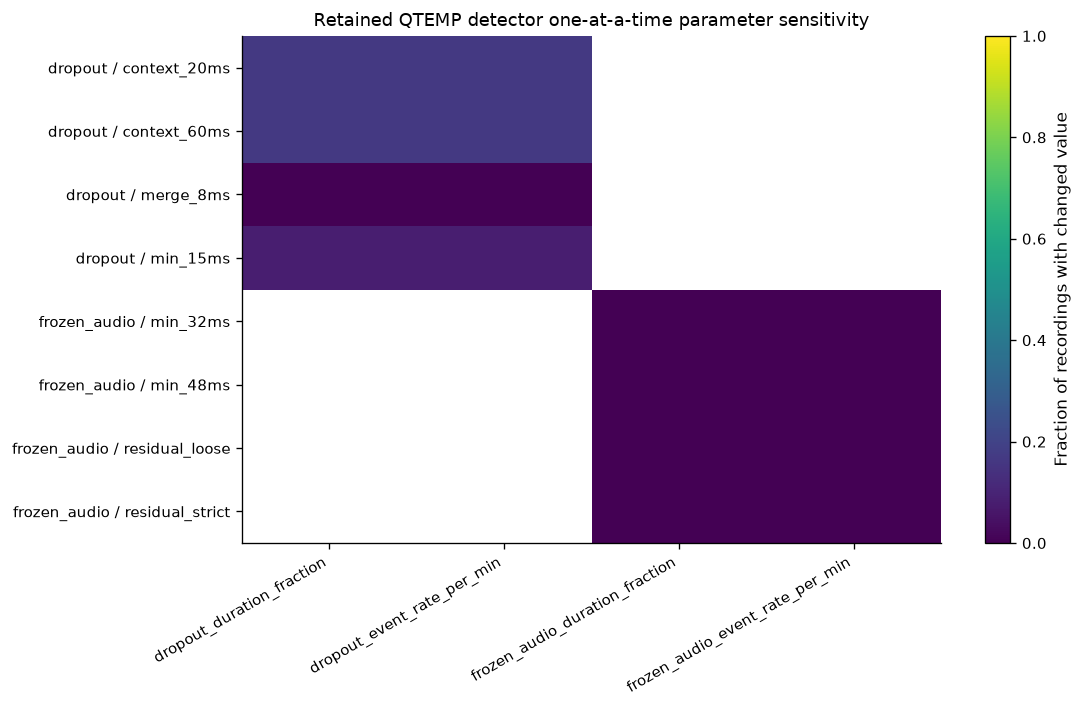

In [13]:
sensitivity_rows = []
sensitivity_errors = []
sensitivity_selection_rows = []

sensitivity_table = pd.DataFrame()
sensitivity_summary = pd.DataFrame()
sensitivity_checks = validation_frame([])
profiles = {}


if RUN_PARAMETER_SENSITIVITY and len(recording_table):
    measured_recordings = recording_table.loc[
        recording_table["qtemp_status"].eq("measured")
    ].copy()

    measured_recordings["logical_recording_id"] = (
        measured_recordings["logical_recording_id"].astype(str)
    )

    candidate_ids = (
        set(
            disposition_ledger[
                "logical_recording_id"
            ].astype(str).unique()
        )
        if len(disposition_ledger)
        else set()
    )

    accepted_ids = (
        set(
            event_ledger[
                "logical_recording_id"
            ].astype(str).unique()
        )
        if len(event_ledger)
        else set()
    )

    measured_recordings["selection_hash"] = (
        measured_recordings[
            "logical_recording_id"
        ].map(stable_hash_fraction)
    )

    measured_recordings["selection_stratum"] = np.select(
        [
            measured_recordings[
                "logical_recording_id"
            ].isin(accepted_ids),
            measured_recordings[
                "logical_recording_id"
            ].isin(candidate_ids),
        ],
        [
            "accepted_event",
            "candidate_without_accepted_event",
        ],
        default="event_free",
    )

    selected_parts = []
    budgets = [
        ("accepted_event", 4),
        ("candidate_without_accepted_event", 4),
        ("event_free", MAX_SENSITIVITY_RECORDINGS),
    ]

    for stratum, budget in budgets:
        used = (
            set(
                pd.concat(
                    selected_parts,
                    ignore_index=True,
                )["logical_recording_id"]
            )
            if selected_parts
            else set()
        )

        remaining = max(
            0,
            MAX_SENSITIVITY_RECORDINGS
            - len(used),
        )

        if remaining == 0:
            break

        pool = measured_recordings.loc[
            measured_recordings[
                "selection_stratum"
            ].eq(stratum)
            & ~measured_recordings[
                "logical_recording_id"
            ].isin(used)
        ].sort_values(
            "selection_hash",
            kind="stable",
        )

        selected_parts.append(
            pool.head(
                min(
                    int(budget),
                    remaining,
                )
            )
        )

    selected = (
        pd.concat(
            selected_parts,
            ignore_index=True,
        )
        .drop_duplicates("logical_recording_id")
        .head(MAX_SENSITIVITY_RECORDINGS)
    )

    sensitivity_selection_rows = selected[
        [
            "logical_recording_id",
            "selection_stratum",
            "selection_hash",
            "qtemp_status",
            "qtemp_eligible_duration_sec",
        ]
    ].to_dict(orient="records")

    # Detector-specific one-at-a-time profiles. The dropped splice detector
    # is intentionally excluded from the finalization sensitivity gate.
    profiles = {
        "dropout": {
            "primary": PARAMETERS,
            "min_15ms": replace(
                PARAMETERS,
                dropout_min_duration_ms=15,
            ),
            "context_20ms": replace(
                PARAMETERS,
                dropout_context_ms=20,
            ),
            "context_60ms": replace(
                PARAMETERS,
                dropout_context_ms=60,
            ),
            "merge_8ms": replace(
                PARAMETERS,
                dropout_merge_gap_ms=8,
            ),
        },
        "frozen_audio": {
            "primary": FINAL_DUPLICATE_PARAMETERS,
            "residual_strict": replace(
                FINAL_DUPLICATE_PARAMETERS,
                duplicate_residual_accept=0.0015,
                duplicate_residual_indeterminate=0.008,
            ),
            "residual_loose": replace(
                FINAL_DUPLICATE_PARAMETERS,
                duplicate_residual_accept=0.005,
                duplicate_residual_indeterminate=0.025,
            ),
            "min_32ms": replace(
                FINAL_DUPLICATE_PARAMETERS,
                duplicate_min_sequence_ms=32,
            ),
            "min_48ms": replace(
                FINAL_DUPLICATE_PARAMETERS,
                duplicate_min_sequence_ms=48,
            ),
        },
    }

    feature_by_detector = {
        "dropout": [
            "qtemp_dropout_duration_fraction",
            "qtemp_dropout_event_rate_per_min",
        ],
        "frozen_audio": [
            "qtemp_frozen_audio_duration_fraction",
            "qtemp_frozen_audio_event_rate_per_min",
        ],
    }

    event_count_by_detector = {
        "dropout": "qtemp_dropout_accepted_event_count",
        "frozen_audio": (
            "qtemp_frozen_audio_accepted_event_count"
        ),
    }

    lookup = frozen["recordings"].copy()
    lookup["logical_recording_id"] = (
        lookup["logical_recording_id"].astype(str)
    )
    lookup = lookup.set_index("logical_recording_id")

    ffmpeg_path = shutil.which("ffmpeg")
    ffprobe_path = shutil.which("ffprobe")

    if not ffmpeg_path or not ffprobe_path:
        raise RuntimeError(
            "ffmpeg and ffprobe are required for sensitivity analysis"
        )

    def _run_sensitivity_recording(selection):
        recording_id = str(
            selection["logical_recording_id"]
        )
        local_rows = []
        local_errors = []

        try:
            row = lookup.loc[recording_id]

            views = decode_audio_views(
                media_path_for(row),
                ffmpeg=ffmpeg_path,
                ffprobe=ffprobe_path,
            )

            analysis_intervals = task_intervals_for(
                recording_id
            )
            speech_intervals = speech_intervals_for(
                recording_id
            )
            clipping_intervals = (
                qdist_clipping_intervals_for(
                    recording_id
                )
            )

            if not analysis_intervals:
                raise ValueError(
                    "No frozen task interval"
                )

            for detector, detector_profiles in profiles.items():
                for profile_name, profile in detector_profiles.items():
                    started = pytime.perf_counter()

                    try:
                        extraction = extract_qtemp(
                            views.native,
                            views.sample_rate_native,
                            analysis_intervals=analysis_intervals,
                            speech_intervals=speech_intervals,
                            clipping_event_intervals=clipping_intervals,
                            logical_recording_id=recording_id,
                            parameters=profile,
                            enabled_event_types=(detector,),
                        )

                        row_out = {
                            "logical_recording_id": recording_id,
                            "selection_stratum": selection[
                                "selection_stratum"
                            ],
                            "detector": detector,
                            "profile": profile_name,
                            "qtemp_status": extraction.recording[
                                "qtemp_status"
                            ],
                            "runtime_sec": (
                                pytime.perf_counter()
                                - started
                            ),
                            "candidate_count": int(
                                len(
                                    extraction.candidate_ledger
                                )
                            ),
                            "indeterminate_count": int(
                                extraction.disposition_ledger[
                                    "disposition"
                                ].eq("indeterminate").sum()
                            )
                            if len(
                                extraction.disposition_ledger
                            )
                            else 0,
                            "event_count": extraction.recording[
                                event_count_by_detector[
                                    detector
                                ]
                            ],
                        }

                        for feature in (
                            RETAINED_ANALYSIS_FEATURES
                        ):
                            row_out[feature] = (
                                extraction.recording[
                                    feature
                                ]
                                if feature
                                in feature_by_detector[
                                    detector
                                ]
                                else np.nan
                            )

                        local_rows.append(row_out)

                    except Exception as exc:
                        local_errors.append(
                            {
                                "logical_recording_id": (
                                    recording_id
                                ),
                                "selection_stratum": selection[
                                    "selection_stratum"
                                ],
                                "detector": detector,
                                "profile": profile_name,
                                "error_type": type(
                                    exc
                                ).__name__,
                                "message": str(exc),
                            }
                        )

        except Exception as exc:
            local_errors.append(
                {
                    "logical_recording_id": recording_id,
                    "selection_stratum": selection[
                        "selection_stratum"
                    ],
                    "detector": "all",
                    "profile": "decode_or_adapter",
                    "error_type": type(exc).__name__,
                    "message": str(exc),
                }
            )

        return local_rows, local_errors

    worker_count = max(
        1,
        min(
            SENSITIVITY_WORKERS,
            len(sensitivity_selection_rows),
        ),
    )

    with ThreadPoolExecutor(
        max_workers=worker_count
    ) as executor:
        future_map = {
            executor.submit(
                _run_sensitivity_recording,
                selection,
            ): selection["logical_recording_id"]
            for selection in sensitivity_selection_rows
        }

        for future in as_completed(future_map):
            rows_local, errors_local = future.result()
            sensitivity_rows.extend(rows_local)
            sensitivity_errors.extend(errors_local)


sensitivity_selection = pd.DataFrame(
    sensitivity_selection_rows
)

sensitivity_table = pd.DataFrame(
    sensitivity_rows
)

sensitivity_errors = pd.DataFrame(
    sensitivity_errors,
    columns=[
        "logical_recording_id",
        "selection_stratum",
        "detector",
        "profile",
        "error_type",
        "message",
    ],
)

for frame, directory, stem in [
    (
        sensitivity_selection,
        TABLES,
        f"{PREFIX}_parameter_sensitivity_selection",
    ),
    (
        sensitivity_table,
        TABLES,
        f"{PREFIX}_parameter_sensitivity",
    ),
    (
        sensitivity_errors,
        AUDIT,
        f"{PREFIX}_parameter_sensitivity_errors",
    ),
]:
    save_table_bundle(
        frame,
        directory,
        stem,
    )


if len(sensitivity_table):
    summary_rows = []

    for detector, detector_local in (
        sensitivity_table.groupby("detector")
    ):
        primary = (
            detector_local.loc[
                detector_local["profile"].eq(
                    "primary"
                )
            ]
            .set_index("logical_recording_id")
        )

        detector_features = [
            feature
            for feature
            in RETAINED_ANALYSIS_FEATURES
            if feature
            in sensitivity_table.columns
            and primary[feature].notna().any()
        ]

        for profile_name, local in (
            detector_local.loc[
                ~detector_local[
                    "profile"
                ].eq("primary")
            ].groupby("profile")
        ):
            local = local.set_index(
                "logical_recording_id"
            )
            common = primary.index.intersection(
                local.index
            )

            status_change = (
                float(
                    (
                        local.loc[
                            common,
                            "qtemp_status",
                        ]
                        != primary.loc[
                            common,
                            "qtemp_status",
                        ]
                    ).mean()
                )
                if len(common)
                else np.nan
            )

            for feature in detector_features:
                baseline = pd.to_numeric(
                    primary.loc[
                        common,
                        feature,
                    ],
                    errors="coerce",
                )
                alternate = pd.to_numeric(
                    local.loc[
                        common,
                        feature,
                    ],
                    errors="coerce",
                )

                finite = (
                    baseline.notna()
                    & alternate.notna()
                )
                difference = (
                    alternate.loc[finite]
                    - baseline.loc[finite]
                )

                summary_rows.append(
                    {
                        "detector": detector,
                        "profile": profile_name,
                        "feature": feature,
                        "paired_n": int(
                            len(common)
                        ),
                        "finite_pair_n": int(
                            finite.sum()
                        ),
                        "median_absolute_change": (
                            float(
                                np.nanmedian(
                                    np.abs(
                                        difference
                                    )
                                )
                            )
                            if len(difference)
                            else np.nan
                        ),
                        "maximum_absolute_change": (
                            float(
                                np.nanmax(
                                    np.abs(
                                        difference
                                    )
                                )
                            )
                            if len(difference)
                            else np.nan
                        ),
                        "changed_recording_fraction": (
                            float(
                                np.mean(
                                    np.abs(
                                        difference
                                    )
                                    > 1e-12
                                )
                            )
                            if len(difference)
                            else np.nan
                        ),
                        "zero_to_positive_n": int(
                            (
                                ~baseline.fillna(
                                    0
                                ).gt(0)
                                & alternate.fillna(
                                    0
                                ).gt(0)
                            ).sum()
                        ),
                        "positive_to_zero_n": int(
                            (
                                baseline.fillna(
                                    0
                                ).gt(0)
                                & ~alternate.fillna(
                                    0
                                ).gt(0)
                            ).sum()
                        ),
                        "status_change_fraction": (
                            status_change
                        ),
                    }
                )

    sensitivity_summary = pd.DataFrame(
        summary_rows
    )

save_table_bundle(
    sensitivity_summary,
    TABLES,
    f"{PREFIX}_parameter_sensitivity_summary",
)

expected_per_record = sum(
    len(detector_profiles)
    for detector_profiles in profiles.values()
)

expected_rows = (
    len(sensitivity_selection)
    * expected_per_record
)

sensitivity_checks = validation_frame(
    [
        ValidationCheck(
            "selection",
            (
                "sensitivity audit includes event-free "
                "and candidate/positive recordings when available"
            ),
            bool(len(sensitivity_selection))
            and sensitivity_selection[
                "selection_stratum"
            ].eq("event_free").any()
            and (
                sensitivity_selection[
                    "selection_stratum"
                ].ne("event_free").any()
                or not len(disposition_ledger)
            ),
            (
                sensitivity_selection[
                    "selection_stratum"
                ].value_counts().to_dict()
                if len(sensitivity_selection)
                else "NOT RUN"
            ),
            "event-free + candidate/positive",
            "repair selection",
        ),
        ValidationCheck(
            "execution",
            (
                "every selected recording is evaluated "
                "under every retained-detector profile"
            ),
            bool(len(sensitivity_selection))
            and len(sensitivity_table)
            == expected_rows,
            (
                f"rows={len(sensitivity_table)} "
                f"expected={expected_rows}"
                if len(sensitivity_selection)
                else "NOT RUN"
            ),
            "complete retained-detector Cartesian evaluation",
            "inspect errors",
        ),
        ValidationCheck(
            "errors",
            (
                "parameter sensitivity completes "
                "without extraction errors"
            ),
            bool(len(sensitivity_selection))
            and len(sensitivity_errors) == 0,
            (
                f"errors={len(sensitivity_errors)}"
                if len(sensitivity_selection)
                else "NOT RUN"
            ),
            "0",
            "resolve failures",
        ),
        ValidationCheck(
            "status",
            (
                "one-at-a-time changes do not alter "
                "availability status"
            ),
            bool(len(sensitivity_summary))
            and sensitivity_summary[
                "status_change_fraction"
            ].fillna(0).max()
            == 0,
            (
                f"max={sensitivity_summary['status_change_fraction'].fillna(0).max():.3f}"
                if len(sensitivity_summary)
                else "NOT RUN"
            ),
            "0",
            "repair support coupling",
        ),
    ]
)

save_table_bundle(
    sensitivity_checks,
    TABLES,
    f"{PREFIX}_parameter_sensitivity_checks",
)

display(sensitivity_selection)
display(sensitivity_summary)
display(sensitivity_errors)
display(sensitivity_checks)

if len(sensitivity_summary):
    pivot = sensitivity_summary.pivot_table(
        index=["detector", "profile"],
        columns="feature",
        values="changed_recording_fraction",
    )

    fig, ax = plt.subplots(
        figsize=(9.5, 6.0)
    )
    image = ax.imshow(
        pivot.to_numpy(),
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap="viridis",
    )
    ax.set_xticks(
        range(len(pivot.columns)),
        [
            value.replace("qtemp_", "")
            for value in pivot.columns
        ],
        rotation=30,
        ha="right",
    )
    ax.set_yticks(
        range(len(pivot.index)),
        [
            " / ".join(value)
            for value in pivot.index
        ],
    )
    ax.set(
        title=(
            "Retained QTEMP detector "
            "one-at-a-time parameter sensitivity"
        )
    )
    fig.colorbar(
        image,
        ax=ax,
        label=(
            "Fraction of recordings with changed value"
        ),
    )
    fig.tight_layout()

    save_publication_figure(
        fig,
        FIGURES,
        "figure_qtemp_parameter_sensitivity",
        caption=(
            "Recording-level changes under retained-detector "
            "one-at-a-time parameter perturbations. Native audio "
            "is decoded once per selected recording."
        ),
        alt_text=(
            "Heatmap of retained QTEMP detector-specific "
            "parameter sensitivity."
        ),
    )
    plt.show()


## 13. Empirical availability, prevalence, event burden, and technical concentration


,qtemp_status,recordings
0,measured,519


,feature,recordings_total,available_n,unavailable_n,available_fraction,measured_zero_n,positive_n,positive_prevalence_among_available,positive_prevalence_ci95_low,positive_prevalence_ci95_high,median_all_available,q25_all_available,q75_all_available,median_among_positive,q25_among_positive,q75_among_positive,maximum
0,qtemp_dropout_duration_fraction,519,519,0,1.0,517,2,0.003854,0.000467,0.013851,0.0,0.0,0.0,0.005972,0.003304,0.008641,0.011309
1,qtemp_dropout_event_rate_per_min,519,519,0,1.0,517,2,0.003854,0.000467,0.013851,0.0,0.0,0.0,2.607024,1.813925,3.400124,4.193224
2,qtemp_frozen_audio_duration_fraction,519,519,0,1.0,519,0,0.000000,0.000000,0.007082,0.0,0.0,0.0,NaN,NaN,NaN,0.000000
3,qtemp_frozen_audio_event_rate_per_min,519,519,0,1.0,519,0,0.000000,0.000000,0.007082,0.0,0.0,0.0,NaN,NaN,NaN,0.000000


,event_type,event_count,recordings_positive,total_eligible_exposure_min,aggregate_event_rate_per_min,aggregate_rate_ci95_low_per_min,aggregate_rate_ci95_high_per_min,median_support_duration_ms,q25_support_duration_ms,q75_support_duration_ms,maximum_support_duration_ms,median_span_duration_ms,median_channels_detected
0,dropout,6,2,383.717982,0.015636,0.005738,0.034034,141.360544,61.269841,188.730159,313.537415,141.360544,1.0


,event_type,disposition,candidate_count,candidate_fraction
0,dropout,accepted,6,0.00293
1,dropout,rejected,2042,0.99707


,event_type,stratum,stratum_value,recordings,positives,positive_fraction,events,exposure_sec,event_rate_per_min
0,dropout,codec_name,pcm_s16le,519,2,0.003854,6,23023.078937,0.015636
1,dropout,qtemp_native_sample_rate_hz,44100,215,2,0.009302,6,9913.366937,0.036315
2,dropout,qtemp_native_sample_rate_hz,48000,304,0,0.000000,0,13109.712000,0.000000
3,dropout,qtemp_native_channel_count,1,517,2,0.003868,6,22954.454937,0.015683
4,dropout,qtemp_native_channel_count,2,2,0,0.000000,0,68.624000,0.000000
5,frozen_audio,codec_name,pcm_s16le,519,0,0.000000,0,23023.078937,0.000000
6,frozen_audio,qtemp_native_sample_rate_hz,44100,215,0,0.000000,0,9913.366937,0.000000
7,frozen_audio,qtemp_native_sample_rate_hz,48000,304,0,0.000000,0,13109.712000,0.000000
8,frozen_audio,qtemp_native_channel_count,1,517,0,0.000000,0,22954.454937,0.000000
9,frozen_audio,qtemp_native_channel_count,2,2,0,0.000000,0,68.624000,0.000000


,layer,check,passed,observed,required,action_if_failed,blocking
0,empirical,"availability, measured-zero prevalence, and exact prevalence intervals are reported",True,4,four complete retained-feature rows,complete cohort extraction and prevalence audit,True
1,empirical,candidate dispositions are reported by detector,True,2,reported or truly zero candidates,repair disposition reporting,True
2,empirical,technical concentration is characterized without clinical labels,True,10,>0 rows,complete codec/rate/channel audit,True


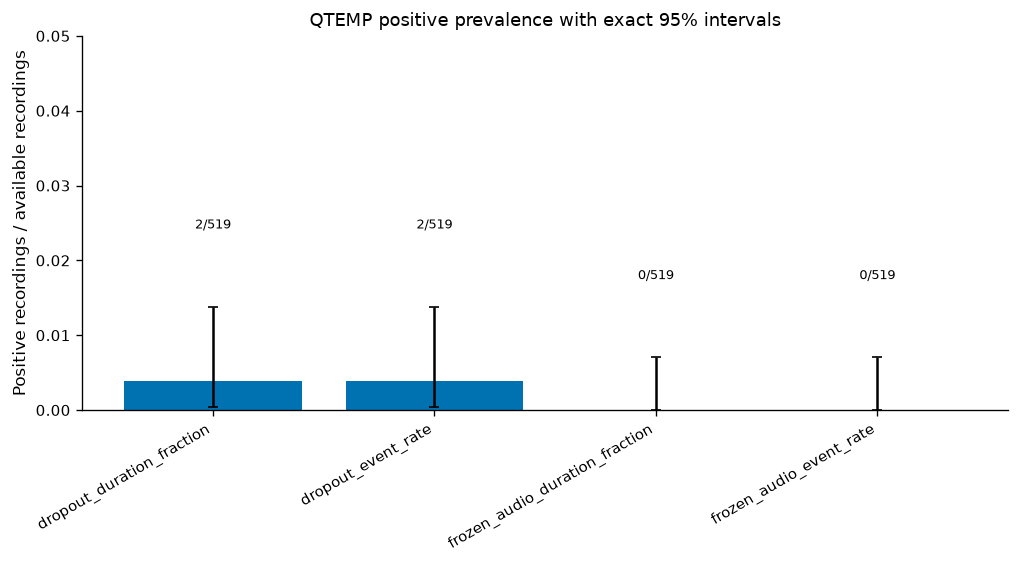

In [14]:
empirical_summary = pd.DataFrame()
event_summary = pd.DataFrame()
disposition_summary = pd.DataFrame()
technical_concentration = pd.DataFrame()
recording_status_summary = pd.DataFrame()


def clopper_pearson(
    successes: int,
    total: int,
    confidence: float = 0.95,
) -> tuple[float, float]:
    """Exact Clopper–Pearson confidence interval for a binomial proportion."""
    successes = int(successes)
    total = int(total)

    if total <= 0 or successes < 0 or successes > total:
        return np.nan, np.nan

    alpha = 1.0 - confidence

    lower = (
        0.0
        if successes == 0
        else stats.beta.ppf(
            alpha / 2.0,
            successes,
            total - successes + 1,
        )
    )

    upper = (
        1.0
        if successes == total
        else stats.beta.ppf(
            1.0 - alpha / 2.0,
            successes + 1,
            total - successes,
        )
    )

    return float(lower), float(upper)


def poisson_rate_interval(
    event_count: int,
    exposure_sec: float,
    confidence: float = 0.95,
) -> tuple[float, float]:
    """
    Exact Garwood confidence interval for a Poisson event rate.

    Parameters
    ----------
    event_count
        Number of observed events.
    exposure_sec
        Total eligible exposure in seconds.
    confidence
        Confidence level.

    Returns
    -------
    lower_rate_per_min, upper_rate_per_min
        Exact confidence limits expressed as events per minute.
    """
    event_count = int(event_count)
    exposure_sec = float(exposure_sec)

    if event_count < 0 or not np.isfinite(exposure_sec) or exposure_sec <= 0:
        return np.nan, np.nan

    alpha = 1.0 - confidence

    lower_count = (
        0.0
        if event_count == 0
        else 0.5 * stats.chi2.ppf(
            alpha / 2.0,
            2 * event_count,
        )
    )

    upper_count = 0.5 * stats.chi2.ppf(
        1.0 - alpha / 2.0,
        2 * (event_count + 1),
    )

    conversion = 60.0 / exposure_sec

    return (
        float(lower_count * conversion),
        float(upper_count * conversion),
    )


if len(recording_table):
    required_recording_columns = {
        "logical_recording_id",
        "qtemp_status",
        "qtemp_eligible_duration_sec",
        *RETAINED_ANALYSIS_FEATURES,
    }
    missing_recording_columns = sorted(
        required_recording_columns.difference(recording_table.columns)
    )

    if missing_recording_columns:
        raise KeyError(
            "The recording table is missing required QTEMP columns: "
            + ", ".join(missing_recording_columns)
        )

    measured_mask = recording_table["qtemp_status"].eq("measured")

    recording_status_summary = (
        recording_table["qtemp_status"]
        .value_counts(dropna=False)
        .rename_axis("qtemp_status")
        .reset_index(name="recordings")
    )

    rows = []

    for feature in RETAINED_ANALYSIS_FEATURES:
        values = pd.to_numeric(
            recording_table[feature],
            errors="coerce",
        )

        available_values = values.dropna()
        positive_values = available_values.loc[available_values > 0]

        available_n = int(available_values.size)
        positive_n = int(positive_values.size)
        measured_zero_n = int((available_values == 0).sum())

        prevalence_low, prevalence_high = clopper_pearson(
            positive_n,
            available_n,
        )

        rows.append(
            {
                "feature": feature,
                "recordings_total": int(len(recording_table)),
                "available_n": available_n,
                "unavailable_n": int(values.isna().sum()),
                "available_fraction": (
                    float(available_n / len(recording_table))
                    if len(recording_table)
                    else np.nan
                ),
                "measured_zero_n": measured_zero_n,
                "positive_n": positive_n,
                "positive_prevalence_among_available": (
                    float(positive_n / available_n)
                    if available_n > 0
                    else np.nan
                ),
                "positive_prevalence_ci95_low": prevalence_low,
                "positive_prevalence_ci95_high": prevalence_high,
                "median_all_available": (
                    float(available_values.median())
                    if available_n
                    else np.nan
                ),
                "q25_all_available": (
                    float(available_values.quantile(0.25))
                    if available_n
                    else np.nan
                ),
                "q75_all_available": (
                    float(available_values.quantile(0.75))
                    if available_n
                    else np.nan
                ),
                "median_among_positive": (
                    float(positive_values.median())
                    if positive_n
                    else np.nan
                ),
                "q25_among_positive": (
                    float(positive_values.quantile(0.25))
                    if positive_n
                    else np.nan
                ),
                "q75_among_positive": (
                    float(positive_values.quantile(0.75))
                    if positive_n
                    else np.nan
                ),
                "maximum": (
                    float(available_values.max())
                    if available_n
                    else np.nan
                ),
            }
        )

    empirical_summary = pd.DataFrame(rows)

    if len(event_ledger):
        required_event_columns = {
            "event_type",
            "logical_recording_id",
            "duration_sec",
        }
        missing_event_columns = sorted(
            required_event_columns.difference(event_ledger.columns)
        )

        if missing_event_columns:
            raise KeyError(
                "The accepted-event ledger is missing required columns: "
                + ", ".join(missing_event_columns)
            )

        total_exposure_sec = float(
            pd.to_numeric(
                recording_table.loc[
                    measured_mask,
                    "qtemp_eligible_duration_sec",
                ],
                errors="coerce",
            )
            .fillna(0.0)
            .sum()
        )

        event_rows = []

        for event_type, local in event_ledger.groupby(
            "event_type",
            dropna=False,
            sort=True,
        ):
            local = local.copy()

            duration_sec = pd.to_numeric(
                local["duration_sec"],
                errors="coerce",
            )

            event_count = int(len(local))

            aggregate_rate = (
                event_count * 60.0 / total_exposure_sec
                if total_exposure_sec > 0
                else np.nan
            )

            rate_low, rate_high = poisson_rate_interval(
                event_count,
                total_exposure_sec,
            )

            span_duration_sec = (
                pd.to_numeric(
                    local["span_duration_sec"],
                    errors="coerce",
                )
                if "span_duration_sec" in local.columns
                else pd.Series(dtype=float)
            )

            channel_count = (
                pd.to_numeric(
                    local["channel_count"],
                    errors="coerce",
                )
                if "channel_count" in local.columns
                else pd.Series(dtype=float)
            )

            event_rows.append(
                {
                    "event_type": event_type,
                    "event_count": event_count,
                    "recordings_positive": int(
                        local["logical_recording_id"].nunique()
                    ),
                    "total_eligible_exposure_min": (
                        total_exposure_sec / 60.0
                        if total_exposure_sec > 0
                        else np.nan
                    ),
                    "aggregate_event_rate_per_min": aggregate_rate,
                    "aggregate_rate_ci95_low_per_min": rate_low,
                    "aggregate_rate_ci95_high_per_min": rate_high,
                    "median_support_duration_ms": (
                        float(1000.0 * duration_sec.median())
                        if duration_sec.notna().any()
                        else np.nan
                    ),
                    "q25_support_duration_ms": (
                        float(1000.0 * duration_sec.quantile(0.25))
                        if duration_sec.notna().any()
                        else np.nan
                    ),
                    "q75_support_duration_ms": (
                        float(1000.0 * duration_sec.quantile(0.75))
                        if duration_sec.notna().any()
                        else np.nan
                    ),
                    "maximum_support_duration_ms": (
                        float(1000.0 * duration_sec.max())
                        if duration_sec.notna().any()
                        else np.nan
                    ),
                    "median_span_duration_ms": (
                        float(1000.0 * span_duration_sec.median())
                        if span_duration_sec.notna().any()
                        else np.nan
                    ),
                    "median_channels_detected": (
                        float(channel_count.median())
                        if channel_count.notna().any()
                        else np.nan
                    ),
                }
            )

        event_summary = pd.DataFrame(event_rows)

    if len(disposition_ledger):
        required_disposition_columns = {
            "event_type",
            "disposition",
        }
        missing_disposition_columns = sorted(
            required_disposition_columns.difference(
                disposition_ledger.columns
            )
        )

        if missing_disposition_columns:
            raise KeyError(
                "The disposition ledger is missing required columns: "
                + ", ".join(missing_disposition_columns)
            )

        disposition_summary = (
            disposition_ledger.groupby(
                ["event_type", "disposition"],
                dropna=False,
                as_index=False,
            )
            .size()
            .rename(columns={"size": "candidate_count"})
        )

        totals = disposition_summary.groupby(
            "event_type",
            dropna=False,
        )["candidate_count"].transform("sum")

        disposition_summary["candidate_fraction"] = np.where(
            totals > 0,
            disposition_summary["candidate_count"] / totals,
            np.nan,
        )

    technical_rows = []

    detector_count_columns = [
        (
            "dropout",
            "qtemp_dropout_accepted_event_count",
        ),
        (
            "frozen_audio",
            "qtemp_frozen_audio_accepted_event_count",
        ),
    ]

    technical_strata = [
        "codec_name",
        "qtemp_native_sample_rate_hz",
        "qtemp_native_channel_count",
    ]

    for event_type, count_column in detector_count_columns:
        if count_column not in recording_table.columns:
            continue

        for column in technical_strata:
            if column not in recording_table.columns:
                continue

            working = recording_table.loc[
                measured_mask,
                [
                    "logical_recording_id",
                    column,
                    count_column,
                    "qtemp_eligible_duration_sec",
                ],
            ].copy()

            working[count_column] = pd.to_numeric(
                working[count_column],
                errors="coerce",
            ).fillna(0.0)

            working["qtemp_eligible_duration_sec"] = pd.to_numeric(
                working["qtemp_eligible_duration_sec"],
                errors="coerce",
            ).fillna(0.0)

            local = (
                working.groupby(
                    column,
                    dropna=False,
                )
                .agg(
                    recordings=(
                        "logical_recording_id",
                        "size",
                    ),
                    positives=(
                        count_column,
                        lambda value: int((value > 0).sum()),
                    ),
                    events=(
                        count_column,
                        "sum",
                    ),
                    exposure_sec=(
                        "qtemp_eligible_duration_sec",
                        "sum",
                    ),
                )
                .reset_index()
            )

            local["event_type"] = event_type
            local["stratum"] = column

            local["positive_fraction"] = np.where(
                local["recordings"] > 0,
                local["positives"] / local["recordings"],
                np.nan,
            )

            local["event_rate_per_min"] = np.where(
                local["exposure_sec"] > 0,
                local["events"] * 60.0 / local["exposure_sec"],
                np.nan,
            )

            local = local.rename(
                columns={column: "stratum_value"}
            )

            technical_rows.append(
                local[
                    [
                        "event_type",
                        "stratum",
                        "stratum_value",
                        "recordings",
                        "positives",
                        "positive_fraction",
                        "events",
                        "exposure_sec",
                        "event_rate_per_min",
                    ]
                ]
            )

    technical_concentration = (
        pd.concat(
            technical_rows,
            ignore_index=True,
        )
        if technical_rows
        else pd.DataFrame()
    )


for frame, directory, stem in [
    (
        recording_status_summary,
        TABLES,
        f"{PREFIX}_recording_status_summary",
    ),
    (
        empirical_summary,
        TABLES,
        f"{PREFIX}_empirical_feature_summary",
    ),
    (
        event_summary,
        TABLES,
        f"{PREFIX}_empirical_event_summary",
    ),
    (
        disposition_summary,
        TABLES,
        f"{PREFIX}_candidate_disposition_summary",
    ),
    (
        technical_concentration,
        TABLES,
        f"{PREFIX}_technical_concentration",
    ),
]:
    save_table_bundle(
        frame,
        directory,
        stem,
    )


candidate_counts_are_zero = False

if len(recording_table):
    candidate_columns = [
        "qtemp_dropout_candidate_count",
        "qtemp_frozen_audio_candidate_count",
    ]

    if all(
        column in recording_table.columns
        for column in candidate_columns
    ):
        candidate_counts_are_zero = all(
            pd.to_numeric(
                recording_table[column],
                errors="coerce",
            )
            .fillna(0)
            .sum()
            == 0
            for column in candidate_columns
        )


empirical_checks = validation_frame(
    [
        ValidationCheck(
            "empirical",
            (
                "availability, measured-zero prevalence, and exact "
                "prevalence intervals are reported"
            ),
            bool(len(empirical_summary))
            and len(empirical_summary) == len(RETAINED_ANALYSIS_FEATURES)
            and empirical_summary[
                "positive_prevalence_ci95_low"
            ].notna().all()
            and empirical_summary[
                "positive_prevalence_ci95_high"
            ].notna().all(),
            (
                str(len(empirical_summary))
                if len(empirical_summary)
                else "NOT RUN"
            ),
            "four complete retained-feature rows",
            "complete cohort extraction and prevalence audit",
        ),
        ValidationCheck(
            "empirical",
            "candidate dispositions are reported by detector",
            bool(len(disposition_summary))
            or candidate_counts_are_zero,
            str(len(disposition_summary)),
            "reported or truly zero candidates",
            "repair disposition reporting",
        ),
        ValidationCheck(
            "empirical",
            (
                "technical concentration is characterized without "
                "clinical labels"
            ),
            bool(len(technical_concentration)),
            str(len(technical_concentration)),
            ">0 rows",
            "complete codec/rate/channel audit",
        ),
    ]
)


display(recording_status_summary)
display(empirical_summary)
display(event_summary)
display(disposition_summary)
display(technical_concentration)
display(empirical_checks)


if len(empirical_summary):
    plot_frame = empirical_summary.loc[
        empirical_summary[
            "positive_prevalence_among_available"
        ].notna()
        & empirical_summary[
            "positive_prevalence_ci95_low"
        ].notna()
        & empirical_summary[
            "positive_prevalence_ci95_high"
        ].notna()
    ].reset_index(drop=True)

    if len(plot_frame):
        fig, ax = plt.subplots(
            figsize=(8.6, 4.8)
        )

        labels = [
            value.replace("qtemp_", "").replace(
                "_per_min",
                "",
            )
            for value in plot_frame["feature"]
        ]

        positions = np.arange(len(labels))

        prevalence = plot_frame[
            "positive_prevalence_among_available"
        ].to_numpy(dtype=float)

        lower_error = np.maximum(
            0.0,
            prevalence
            - plot_frame[
                "positive_prevalence_ci95_low"
            ].to_numpy(dtype=float),
        )

        upper_error = np.maximum(
            0.0,
            plot_frame[
                "positive_prevalence_ci95_high"
            ].to_numpy(dtype=float)
            - prevalence,
        )

        ax.bar(
            positions,
            prevalence,
            color=OKABE_ITO["blue"],
        )

        ax.errorbar(
            positions,
            prevalence,
            yerr=np.vstack(
                [
                    lower_error,
                    upper_error,
                ]
            ),
            fmt="none",
            capsize=3,
            color=OKABE_ITO["black"],
        )

        ax.set_xticks(
            positions,
            labels,
            rotation=30,
            ha="right",
        )

        maximum_upper = float(
            plot_frame[
                "positive_prevalence_ci95_high"
            ].max()
        )

        ax.set(
            ylabel=(
                "Positive recordings / available recordings"
            ),
            ylim=(
                0,
                min(
                    1.0,
                    max(
                        0.05,
                        maximum_upper * 1.15,
                    ),
                ),
            ),
            title=(
                "QTEMP positive prevalence with exact "
                "95% intervals"
            ),
        )

        for index, row in plot_frame.iterrows():
            label_y = min(
                0.995,
                float(
                    row[
                        "positive_prevalence_ci95_high"
                    ]
                )
                + 0.01,
            )

            ax.text(
                index,
                label_y,
                (
                    f"{int(row['positive_n'])}/"
                    f"{int(row['available_n'])}"
                ),
                ha="center",
                va="bottom",
                fontsize=8,
            )

        fig.tight_layout()

        save_publication_figure(
            fig,
            FIGURES,
            "figure_qtemp_empirical_prevalence",
            caption=(
                "Recording-level positive prevalence for each QTEMP "
                "feature with exact Clopper–Pearson 95% confidence "
                "intervals and positive/available counts."
            ),
            alt_text=(
                "Bar chart of positive recording prevalence with "
                "confidence intervals for the four retained "
                "temporal-discontinuity features."
            ),
        )

        plt.show()


## 14. Sparse-event recurrence, redundancy, and downstream suitability


In [15]:
recurrence = pd.DataFrame()
pairwise_persistence = pd.DataFrame()
redundancy = pd.DataFrame()
suitability = pd.DataFrame()

if len(recording_table):
    measured = recording_table.loc[recording_table["qtemp_status"].eq("measured")].copy()
    presence_columns = {
        "dropout": "qtemp_dropout_accepted_event_count",
        "frozen_audio": "qtemp_frozen_audio_accepted_event_count",
    }
    recurrence_rows = []
    pair_rows = []
    for subject_id, local in measured.groupby("qtemp_subject_id"):
        if len(local) < 2:
            continue
        local = local.sort_values("logical_recording_id").reset_index(drop=True)
        for event_type, column in presence_columns.items():
            positive = pd.to_numeric(local[column], errors="coerce").fillna(0).gt(0)
            recurrence_rows.append({
                "qtemp_subject_id": subject_id,
                "event_type": event_type,
                "recording_count": len(local),
                "positive_recording_count": int(positive.sum()),
                "positive_fraction": float(positive.mean()),
                "recurrent_positive": bool(positive.sum() >= 2),
            })
            for first in range(len(local) - 1):
                for second in range(first + 1, len(local)):
                    first_positive = bool(positive.iloc[first])
                    second_positive = bool(positive.iloc[second])
                    pair_rows.append({
                        "qtemp_subject_id": subject_id,
                        "event_type": event_type,
                        "recording_id_1": local.loc[first, "logical_recording_id"],
                        "recording_id_2": local.loc[second, "logical_recording_id"],
                        "first_positive": first_positive,
                        "second_positive": second_positive,
                        "both_positive": first_positive and second_positive,
                        "both_negative": (not first_positive) and (not second_positive),
                        "discordant": first_positive != second_positive,
                        "overall_agreement": first_positive == second_positive,
                    })
    recurrence = pd.DataFrame(recurrence_rows)
    pairwise_persistence = pd.DataFrame(pair_rows)

    finite = measured[list(RETAINED_ANALYSIS_FEATURES)].apply(pd.to_numeric, errors="coerce")
    if len(finite):
        redundancy = finite.corr(method="spearman", min_periods=10).reset_index().rename(columns={"index": "feature"})

    suitability_rows = []
    for _, row in empirical_summary.iterrows():
        prevalence = float(row["positive_prevalence_among_available"])
        positive_n = int(row["positive_n"])
        available_n = int(row["available_n"])
        if positive_n == 0:
            distribution_status = "all measured values zero"
        elif prevalence < 0.05:
            distribution_status = "extremely sparse"
        elif prevalence < 0.20:
            distribution_status = "sparse"
        else:
            distribution_status = "continuous/count analysis potentially supportable"
        suitability_rows.append({
            "feature": row["feature"],
            "available_n": available_n,
            "positive_n": positive_n,
            "positive_prevalence": prevalence,
            "zero_fraction": row["measured_zero_n"] / max(available_n, 1),
            "distribution_status": distribution_status,
            "continuous_distribution_analysis": "consider" if prevalence >= 0.20 else "not recommended",
            "binary_any_event_analysis": "potentially appropriate" if positive_n >= 20 else "insufficient positives",
            "count_or_rate_model": "potentially appropriate" if positive_n >= 20 else "descriptive only",
            "PCA_correlation_inclusion": "consider" if prevalence >= 0.20 else "exclude from continuous PCA/correlation",
            "repeatability_analysis": "binary pairwise persistence / count model" if positive_n >= 10 else "descriptive only",
            "same_ledger_warning": "duration fraction and event rate are complementary summaries, not independent evidence",
            "rationale": "Rare-event validity is not judged by whether broad variance exists in this cohort.",
        })
    suitability = pd.DataFrame(suitability_rows)

for frame, stem in [
    (recurrence, f"{PREFIX}_participant_recurrence"),
    (pairwise_persistence, f"{PREFIX}_participant_pairwise_event_persistence"),
    (redundancy, f"{PREFIX}_within_family_spearman"),
    (suitability, f"{PREFIX}_downstream_suitability"),
]:
    save_table_bundle(frame, TABLES, stem)

pairwise_summary = pd.DataFrame()
if len(pairwise_persistence):
    pairwise_summary = pairwise_persistence.groupby("event_type", as_index=False).agg(
        recording_pairs=("overall_agreement", "size"),
        both_positive=("both_positive", "sum"),
        both_negative=("both_negative", "sum"),
        discordant=("discordant", "sum"),
        overall_agreement=("overall_agreement", "mean"),
    )
    pairwise_summary["positive_agreement"] = (
        2 * pairwise_summary["both_positive"]
        / np.maximum(2 * pairwise_summary["both_positive"] + pairwise_summary["discordant"], 1)
    )
    pairwise_summary["negative_agreement"] = (
        2 * pairwise_summary["both_negative"]
        / np.maximum(2 * pairwise_summary["both_negative"] + pairwise_summary["discordant"], 1)
    )
    save_table_bundle(pairwise_summary, TABLES, f"{PREFIX}_participant_pairwise_event_persistence_summary")

display(recurrence.groupby("event_type").agg(subjects=("qtemp_subject_id", "nunique"), recurrent=("recurrent_positive", "sum")) if len(recurrence) else recurrence)
display(pairwise_summary)
display(redundancy)
display(suitability)
display(Markdown(
    "Pairwise within-participant event persistence is reported descriptively. "
    "Temporal acquisition failures are not assumed to be stable participant traits; "
    "high negative agreement under extreme sparsity is not evidence of detector reliability."
))


,subjects,recurrent
event_type,,
dropout,158,0
frozen_audio,158,0


,event_type,recording_pairs,both_positive,both_negative,discordant,overall_agreement,positive_agreement,negative_agreement
0,dropout,495,0,492,3,0.993939,0.0,0.99696
1,frozen_audio,495,0,495,0,1.000000,0.0,1.00000


,feature,qtemp_dropout_duration_fraction,qtemp_dropout_event_rate_per_min,qtemp_frozen_audio_duration_fraction,qtemp_frozen_audio_event_rate_per_min
0,qtemp_dropout_duration_fraction,1.0,1.0,NaN,NaN
1,qtemp_dropout_event_rate_per_min,1.0,1.0,NaN,NaN
2,qtemp_frozen_audio_duration_fraction,NaN,NaN,NaN,NaN
3,qtemp_frozen_audio_event_rate_per_min,NaN,NaN,NaN,NaN


,feature,available_n,positive_n,positive_prevalence,zero_fraction,distribution_status,continuous_distribution_analysis,binary_any_event_analysis,count_or_rate_model,PCA_correlation_inclusion,repeatability_analysis,same_ledger_warning,rationale
0,qtemp_dropout_duration_fraction,519,2,0.003854,0.996146,extremely sparse,not recommended,insufficient positives,descriptive only,exclude from continuous PCA/correlation,descriptive only,"duration fraction and event rate are complementary summaries, not independent evidence",Rare-event validity is not judged by whether broad variance exists in this cohort.
1,qtemp_dropout_event_rate_per_min,519,2,0.003854,0.996146,extremely sparse,not recommended,insufficient positives,descriptive only,exclude from continuous PCA/correlation,descriptive only,"duration fraction and event rate are complementary summaries, not independent evidence",Rare-event validity is not judged by whether broad variance exists in this cohort.
2,qtemp_frozen_audio_duration_fraction,519,0,0.000000,1.000000,all measured values zero,not recommended,insufficient positives,descriptive only,exclude from continuous PCA/correlation,descriptive only,"duration fraction and event rate are complementary summaries, not independent evidence",Rare-event validity is not judged by whether broad variance exists in this cohort.
3,qtemp_frozen_audio_event_rate_per_min,519,0,0.000000,1.000000,all measured values zero,not recommended,insufficient positives,descriptive only,exclude from continuous PCA/correlation,descriptive only,"duration fraction and event rate are complementary summaries, not independent evidence",Rare-event validity is not judged by whether broad variance exists in this cohort.


Pairwise within-participant event persistence is reported descriptively. Temporal acquisition failures are not assumed to be stable participant traits; high negative agreement under extreme sparsity is not evidence of detector reliability.

## 15. Blinded adjudication of every accepted retained event and negative controls

The review set includes every accepted retained cohort event, high-scoring retained-detector rejected or indeterminate candidates when available, and deterministic candidate-free excerpts. The reviewer sheet omits detector labels, scores, dispositions, diagnosis, human-QC labels, and recording identity.


In [16]:
gallery_index = pd.DataFrame()
gallery_errors = pd.DataFrame()
adjudication_sheet = pd.DataFrame()
adjudication_summary = pd.DataFrame()
adjudication_metrics = pd.DataFrame()
gallery_checks = validation_frame([])


def _first_channel(value, default=0):
    try:
        text = str(value).strip()
        return (
            int(text.split("|")[0])
            if text
            else int(default)
        )
    except Exception:
        return int(default)


def _candidate_evidence(candidate):
    fields = [
        "candidate_id",
        "channel_index",
        "event_subtype",
        "score",
        "disposition",
        "disposition_reason",
        "initial_disposition",
        "initial_reason",
        "context_run_ac_ratio",
        "run_peak_context_fraction",
        "normalized_residual",
        "cosine_similarity",
        "spectral_cosine_similarity",
        "boundary_novelty",
        "spectral_entropy",
        "periodicity_similarity",
    ]

    output = {}

    for field in fields:
        value = candidate.get(field, np.nan)

        if isinstance(
            value,
            (np.integer, np.floating),
        ):
            value = value.item()

        if (
            isinstance(value, float)
            and np.isnan(value)
        ):
            continue

        output[field] = value

    return output


def _enrich_accepted_event(event_row):
    item = event_row.to_dict()
    item["review_stratum"] = "accepted"

    candidate_ids = [
        value
        for value
        in str(
            item.get(
                "channel_candidate_ids",
                "",
            )
        ).split("|")
        if value
    ]

    local = (
        disposition_ledger.loc[
            disposition_ledger[
                "candidate_id"
            ].astype(str).isin(candidate_ids)
            & disposition_ledger[
                "disposition"
            ].eq("accepted")
        ].copy()
        if len(disposition_ledger)
        else pd.DataFrame()
    )

    if len(local):
        best = (
            local.sort_values(
                "score",
                ascending=False,
                na_position="last",
            )
            .iloc[0]
            .to_dict()
        )

        item.update(
            {
                key: value
                for key, value in best.items()
                if key
                not in {
                    "logical_recording_id",
                    "qtemp_measurement_version",
                }
            }
        )

        item["channel_index"] = int(
            best.get("channel_index", 0)
        )
        item["candidate_evidence_json"] = (
            json.dumps(
                _candidate_evidence(best),
                sort_keys=True,
            )
        )
    else:
        item["channel_index"] = _first_channel(
            item.get(
                "channels_detected",
                "0",
            )
        )
        item["candidate_evidence_json"] = "{}"

    return item


def _review_id(item):
    start = pd.to_numeric(
        pd.Series(
            [
                item.get(
                    "start_sec",
                    0,
                )
            ]
        ),
        errors="coerce",
    ).iloc[0]

    if not np.isfinite(start):
        start = 0.0

    key = "|".join(
        [
            str(
                item.get(
                    "logical_recording_id",
                    "",
                )
            ),
            str(
                item.get(
                    "event_type",
                    "",
                )
            ),
            str(
                item.get(
                    "review_stratum",
                    "",
                )
            ),
            f"{float(start):.6f}",
            str(
                item.get(
                    "candidate_id",
                    item.get(
                        "event_id",
                        "",
                    ),
                )
            ),
        ]
    )

    return sha256(
        key.encode("utf-8")
    ).hexdigest()[:20]


def _finite_float(value, default):
    try:
        converted = float(value)
    except Exception:
        return float(default)

    return (
        converted
        if np.isfinite(converted)
        else float(default)
    )


if BUILD_GALLERY and len(recording_table):
    selections = []

    # Include every accepted retained event. In the present cohort this is
    # small and permits complete rather than sampled adjudication.
    if len(event_ledger):
        for _, event_row in (
            event_ledger.sort_values(
                [
                    "event_type",
                    "logical_recording_id",
                    "start_sec",
                ]
            ).iterrows()
        ):
            selections.append(
                _enrich_accepted_event(
                    event_row
                )
            )

    # Add hard candidate controls from retained detectors only.
    if len(disposition_ledger):
        candidate_pool = disposition_ledger.loc[
            disposition_ledger[
                "event_type"
            ].astype(str).isin(
                RETAINED_EVENT_TYPES
            )
            & disposition_ledger[
                "disposition"
            ].isin(
                [
                    "indeterminate",
                    "rejected",
                ]
            )
        ].copy()

        for (
            event_type,
            disposition,
        ), local in candidate_pool.groupby(
            [
                "event_type",
                "disposition",
            ],
            sort=True,
        ):
            local = local.sort_values(
                "score",
                ascending=False,
                na_position="last",
            ).head(
                MAX_GALLERY_CANDIDATES_PER_STRATUM
            )

            for _, row in local.iterrows():
                item = row.to_dict()
                item["review_stratum"] = disposition
                item[
                    "candidate_evidence_json"
                ] = json.dumps(
                    _candidate_evidence(item),
                    sort_keys=True,
                )
                selections.append(item)

    # Deterministic candidate-free negative excerpts.
    negatives = recording_table.loc[
        recording_table["qtemp_status"].eq(
            "measured"
        )
    ].copy()

    negatives["logical_recording_id"] = (
        negatives["logical_recording_id"].astype(
            str
        )
    )

    negatives["selection_hash"] = negatives[
        "logical_recording_id"
    ].map(stable_hash_fraction)

    candidate_times = (
        disposition_ledger.groupby(
            "logical_recording_id"
        )["start_sec"]
        .apply(
            lambda values: pd.to_numeric(
                values,
                errors="coerce",
            )
            .dropna()
            .to_numpy(dtype=float)
        )
        .to_dict()
        if len(disposition_ledger)
        else {}
    )

    negative_count = 0

    for _, row in (
        negatives.sort_values(
            "selection_hash",
            kind="stable",
        ).iterrows()
    ):
        if (
            negative_count
            >= MAX_GALLERY_RANDOM_NEGATIVES
        ):
            break

        recording_id = str(
            row.logical_recording_id
        )

        intervals = task_intervals_for(
            recording_id
        )

        if not intervals:
            native_duration = _finite_float(
                row.get(
                    "qtemp_native_duration_sec",
                    np.nan,
                ),
                0.0,
            )
            intervals = [
                TimeInterval(
                    0.0,
                    native_duration,
                )
            ]

        blocked = np.asarray(
            candidate_times.get(
                recording_id,
                [],
            ),
            dtype=float,
        )

        selected_center = None

        for interval in sorted(
            intervals,
            key=lambda item: item.duration_sec,
            reverse=True,
        ):
            if interval.duration_sec < 1.4:
                continue

            fractions = [
                0.50,
                0.30,
                0.70,
                0.20,
                0.80,
            ]

            rotation = int(
                stable_hash_fraction(
                    recording_id
                    + "|negative"
                )
                * len(fractions)
            )

            fractions = (
                fractions[rotation:]
                + fractions[:rotation]
            )

            for fraction in fractions:
                center = (
                    interval.start_sec
                    + fraction
                    * interval.duration_sec
                )

                if (
                    center
                    - interval.start_sec
                    < 0.65
                    or interval.end_sec
                    - center
                    < 0.65
                ):
                    continue

                if (
                    blocked.size
                    and np.min(
                        np.abs(
                            blocked
                            - center
                        )
                    )
                    < 0.50
                ):
                    continue

                selected_center = float(center)
                break

            if selected_center is not None:
                break

        if selected_center is None:
            continue

        selections.append(
            {
                "logical_recording_id": (
                    recording_id
                ),
                "event_type": "none",
                "event_subtype": (
                    "deterministic_candidate_free_excerpt"
                ),
                "review_stratum": (
                    "random_event_free"
                ),
                "start_sec": selected_center,
                "end_sec": selected_center,
                "maximum_score": np.nan,
                "channel_index": 0,
                "candidate_evidence_json": "{}",
            }
        )

        negative_count += 1

    lookup = frozen["recordings"].copy()
    lookup["logical_recording_id"] = (
        lookup["logical_recording_id"].astype(
            str
        )
    )
    lookup = lookup.set_index(
        "logical_recording_id"
    )

    ffmpeg_path = shutil.which("ffmpeg")
    ffprobe_path = shutil.which("ffprobe")

    if not ffmpeg_path or not ffprobe_path:
        raise RuntimeError(
            "ffmpeg and ffprobe are required "
            "for the review gallery"
        )

    grouped = {}
    for item in selections:
        grouped.setdefault(
            str(
                item[
                    "logical_recording_id"
                ]
            ),
            [],
        ).append(item)

    index_rows = []
    error_rows = []
    gallery_number = 0

    for recording_id, items in grouped.items():
        if recording_id not in lookup.index:
            error_rows.append(
                {
                    "gallery_id": np.nan,
                    "review_id": "",
                    "logical_recording_id": (
                        recording_id
                    ),
                    "error_type": (
                        "MissingFrozenRecording"
                    ),
                    "message": (
                        "Absent from frozen "
                        "recording table"
                    ),
                }
            )
            continue

        try:
            views = decode_audio_views(
                media_path_for(
                    lookup.loc[
                        recording_id
                    ]
                ),
                ffmpeg=ffmpeg_path,
                ffprobe=ffprobe_path,
            )

            native = np.asarray(
                views.native,
                dtype=float,
            )

            if native.ndim == 1:
                native = native[:, None]

            sample_rate = int(
                views.sample_rate_native
            )
            duration_sec = (
                native.shape[0]
                / sample_rate
            )

        except Exception as exc:
            error_rows.append(
                {
                    "gallery_id": np.nan,
                    "review_id": "",
                    "logical_recording_id": (
                        recording_id
                    ),
                    "error_type": type(
                        exc
                    ).__name__,
                    "message": str(exc),
                }
            )
            continue

        for item in items:
            gallery_number += 1
            review_id = _review_id(item)

            try:
                raw_center = _finite_float(
                    item.get(
                        "start_sec",
                        duration_sec / 2,
                    ),
                    duration_sec / 2,
                )

                # Clip a corrupt or stale candidate position to the actual
                # native stream rather than creating an empty slice.
                center = float(
                    np.clip(
                        raw_center,
                        0.0,
                        max(
                            0.0,
                            duration_sec
                            - 1.0
                            / sample_rate,
                        ),
                    )
                )

                clip_start = max(
                    0.0,
                    center - 0.9,
                )
                clip_end = min(
                    duration_sec,
                    center + 0.9,
                )

                if (
                    clip_end
                    - clip_start
                    < 0.20
                ):
                    clip_start = max(
                        0.0,
                        min(
                            center - 0.10,
                            duration_sec
                            - 0.20,
                        ),
                    )
                    clip_end = min(
                        duration_sec,
                        clip_start + 0.20,
                    )

                start_sample = max(
                    0,
                    int(
                        np.floor(
                            clip_start
                            * sample_rate
                        )
                    ),
                )
                end_sample = min(
                    native.shape[0],
                    int(
                        np.ceil(
                            clip_end
                            * sample_rate
                        )
                    ),
                )

                if end_sample <= start_sample:
                    raise ValueError(
                        "Empty gallery clip after "
                        "validated native-time clamping"
                    )

                clip = native[
                    start_sample:end_sample
                ]

                channel = int(
                    item.get(
                        "channel_index",
                        _first_channel(
                            item.get(
                                "channels_detected",
                                "0",
                            )
                        ),
                    )
                )

                if (
                    item.get(
                        "event_type"
                    )
                    == "none"
                    or not (
                        0
                        <= channel
                        < clip.shape[1]
                    )
                ):
                    ac = (
                        clip
                        - np.mean(
                            clip,
                            axis=0,
                            keepdims=True,
                        )
                    )
                    channel = int(
                        np.argmax(
                            np.sqrt(
                                np.mean(
                                    ac**2,
                                    axis=0,
                                )
                            )
                        )
                    )

                selected_channel = clip[
                    :,
                    channel,
                ]

                stem = f"review_{review_id}"

                multichannel_path = (
                    GALLERY
                    / (
                        f"{stem}_native_"
                        "channels_float32.wav"
                    )
                )
                audio_path = (
                    GALLERY
                    / (
                        f"{stem}_review_"
                        "channel.wav"
                    )
                )
                figure_path = (
                    GALLERY
                    / f"{stem}.png"
                )

                sf.write(
                    multichannel_path,
                    clip.astype(
                        np.float32
                    ),
                    sample_rate,
                    subtype="FLOAT",
                )
                sf.write(
                    audio_path,
                    selected_channel,
                    sample_rate,
                    subtype="PCM_16",
                )

                time_axis = (
                    np.arange(
                        len(
                            selected_channel
                        )
                    )
                    / sample_rate
                    + clip_start
                )

                event_start = float(
                    np.clip(
                        _finite_float(
                            item.get(
                                "start_sec",
                                center,
                            ),
                            center,
                        ),
                        clip_start,
                        clip_end,
                    )
                )

                event_end = float(
                    np.clip(
                        max(
                            _finite_float(
                                item.get(
                                    "end_sec",
                                    event_start,
                                ),
                                event_start,
                            ),
                            event_start
                            + 1
                            / sample_rate,
                        ),
                        event_start
                        + 1
                        / sample_rate,
                        clip_end,
                    )
                )

                zoom_start = max(
                    clip_start,
                    event_start - 0.12,
                )
                zoom_end = min(
                    clip_end,
                    event_end + 0.12,
                )

                mask = (
                    (time_axis >= zoom_start)
                    & (time_axis <= zoom_end)
                )

                fig, axes = plt.subplots(
                    3,
                    1,
                    figsize=(10, 7.2),
                )

                axes[0].plot(
                    time_axis,
                    selected_channel,
                    lw=0.65,
                    color=OKABE_ITO[
                        "black"
                    ],
                )
                axes[0].axvspan(
                    event_start,
                    event_end,
                    color=OKABE_ITO[
                        "vermillion"
                    ],
                    alpha=0.22,
                )
                axes[0].set(
                    ylabel="Decoded amplitude",
                    title=(
                        "Blinded QTEMP review "
                        f"item {review_id}"
                    ),
                )

                axes[1].plot(
                    time_axis[mask],
                    selected_channel[mask],
                    lw=0.9,
                    color=OKABE_ITO[
                        "black"
                    ],
                )
                axes[1].axvspan(
                    event_start,
                    event_end,
                    color=OKABE_ITO[
                        "vermillion"
                    ],
                    alpha=0.22,
                )
                axes[1].set(
                    xlim=(
                        zoom_start,
                        zoom_end,
                    ),
                    ylabel="Amplitude",
                    title=(
                        "Local waveform context"
                    ),
                )

                nfft = int(
                    min(
                        1024,
                        max(
                            128,
                            2
                            ** int(
                                np.floor(
                                    np.log2(
                                        max(
                                            128,
                                            len(
                                                selected_channel
                                            )
                                            // 8,
                                        )
                                    )
                                )
                            ),
                        ),
                    )
                )
                noverlap = min(
                    nfft - 1,
                    int(
                        0.75
                        * nfft
                    ),
                )

                frequencies, spec_times, power = signal.spectrogram(
                    selected_channel,
                    fs=sample_rate,
                    window="hann",
                    nperseg=nfft,
                    noverlap=noverlap,
                    detrend=False,
                    scaling="density",
                    mode="psd",
                )
                power_db = 10.0 * np.log10(
                    np.maximum(
                        power,
                        np.finfo(np.float64).tiny,
                    )
                )
                image = axes[2].pcolormesh(
                    spec_times,
                    frequencies,
                    power_db,
                    shading="auto",
                    cmap="magma",
                )
                axes[2].set(
                    xlabel=(
                        "Clip-relative time (s)"
                    ),
                    ylabel="Frequency (Hz)",
                    title="Local spectrogram",
                )
                fig.colorbar(
                    image,
                    ax=axes[2],
                    label="Power spectral density (dB)",
                )
                fig.tight_layout()
                fig.savefig(
                    figure_path,
                    dpi=240,
                    bbox_inches="tight",
                    facecolor="white",
                )
                plt.close(fig)

                index_rows.append(
                    {
                        "review_id": review_id,
                        "gallery_id": (
                            gallery_number
                        ),
                        "logical_recording_id": (
                            recording_id
                        ),
                        "event_type": item.get(
                            "event_type"
                        ),
                        "event_subtype": item.get(
                            "event_subtype"
                        ),
                        "review_stratum": item.get(
                            "review_stratum"
                        ),
                        "candidate_id": item.get(
                            "candidate_id",
                            "",
                        ),
                        "event_id": item.get(
                            "event_id",
                            "",
                        ),
                        "start_sec": item.get(
                            "start_sec"
                        ),
                        "end_sec": item.get(
                            "end_sec"
                        ),
                        "selected_channel_index": (
                            channel
                        ),
                        "native_channel_count": (
                            native.shape[1]
                        ),
                        "native_sample_rate_hz": (
                            sample_rate
                        ),
                        "score": item.get(
                            "maximum_score",
                            item.get(
                                "score",
                                np.nan,
                            ),
                        ),
                        "disposition_reason": item.get(
                            "disposition_reason",
                            "",
                        ),
                        "candidate_evidence_json": (
                            item.get(
                                "candidate_evidence_json",
                                "{}",
                            )
                        ),
                        "review_audio_path": str(
                            audio_path
                        ),
                        (
                            "native_multichannel_"
                            "audio_path"
                        ): str(
                            multichannel_path
                        ),
                        "figure_path": str(
                            figure_path
                        ),
                        "diagnosis_hidden": True,
                        "human_qc_hidden": True,
                    }
                )

            except Exception as exc:
                error_rows.append(
                    {
                        "gallery_id": (
                            gallery_number
                        ),
                        "review_id": review_id,
                        "logical_recording_id": (
                            recording_id
                        ),
                        "error_type": type(
                            exc
                        ).__name__,
                        "message": str(exc),
                    }
                )

    gallery_index = pd.DataFrame(
        index_rows
    )
    gallery_errors = pd.DataFrame(
        error_rows,
        columns=[
            "gallery_id",
            "review_id",
            "logical_recording_id",
            "error_type",
            "message",
        ],
    )

    save_table_bundle(
        gallery_index,
        GALLERY,
        f"{PREFIX}_gallery_index_unblinded",
    )
    save_table_bundle(
        gallery_errors,
        GALLERY,
        f"{PREFIX}_gallery_errors",
    )

    sheet_path = (
        GALLERY
        / (
            f"{PREFIX}_blinded_"
            "adjudication_sheet.csv"
        )
    )

    response_columns = [
        "reviewer",
        "review_date",
        (
            "observable_discontinuity_"
            "yes_no_uncertain"
        ),
        (
            "observed_type_none_dropout_"
            "duplicate_other"
        ),
        "estimated_start_sec_in_clip",
        "estimated_end_sec_in_clip",
        (
            "localization_acceptable_"
            "yes_no_uncertain"
        ),
        "confidence_1_to_5",
        "competing_mechanism",
        "audio_usable_yes_no",
        "review_comment",
    ]

    if len(gallery_index):
        base = gallery_index[
            [
                "review_id",
                "review_audio_path",
                (
                    "native_multichannel_"
                    "audio_path"
                ),
                "figure_path",
                "selected_channel_index",
                "native_channel_count",
                "native_sample_rate_hz",
            ]
        ].copy()

        base["review_order_hash"] = base[
            "review_id"
        ].map(stable_hash_fraction)

        base = (
            base.sort_values(
                "review_order_hash"
            )
            .drop(
                columns="review_order_hash"
            )
            .reset_index(drop=True)
        )

        base.insert(
            0,
            "review_order",
            np.arange(
                1,
                len(base) + 1,
            ),
        )

        old = (
            pd.read_csv(
                sheet_path,
                dtype=str,
            ).fillna("")
            if sheet_path.exists()
            else pd.DataFrame()
        )

        for column in response_columns:
            base[column] = ""

        if (
            len(old)
            and "review_id"
            in old.columns
        ):
            preserved_columns = [
                column
                for column
                in response_columns
                if column in old.columns
            ]

            preserved = old[
                [
                    "review_id",
                    *preserved_columns,
                ]
            ].drop_duplicates(
                "review_id"
            )

            base = (
                base.drop(
                    columns=response_columns
                )
                .merge(
                    preserved,
                    on="review_id",
                    how="left",
                    validate="one_to_one",
                )
            )

            for column in response_columns:
                if column not in base.columns:
                    base[column] = ""
                base[column] = (
                    base[column].fillna("")
                )

        adjudication_sheet = base
        adjudication_sheet.to_csv(
            sheet_path,
            index=False,
        )

    if len(adjudication_sheet):
        decision_column = (
            "observable_discontinuity_"
            "yes_no_uncertain"
        )

        completed = (
            adjudication_sheet[
                decision_column
            ]
            .astype(str)
            .str.strip()
            .str.lower()
            .isin(
                [
                    "yes",
                    "no",
                    "uncertain",
                ]
            )
        )

        if completed.all():
            joined = gallery_index.merge(
                adjudication_sheet[
                    [
                        "review_id",
                        decision_column,
                        (
                            "observed_type_none_"
                            "dropout_duplicate_other"
                        ),
                        "confidence_1_to_5",
                        "audio_usable_yes_no",
                    ]
                ],
                on="review_id",
                validate="one_to_one",
            )

            joined["decision_normalized"] = (
                joined[
                    decision_column
                ]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            joined["audio_usable_normalized"] = (
                joined[
                    "audio_usable_yes_no"
                ]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            adjudication_summary = (
                joined.groupby(
                    [
                        "review_stratum",
                        "event_type",
                    ],
                    dropna=False,
                    as_index=False,
                )
                .agg(
                    reviewed=(
                        "review_id",
                        "size",
                    ),
                    observable_yes=(
                        "decision_normalized",
                        lambda values: int(
                            values.eq(
                                "yes"
                            ).sum()
                        ),
                    ),
                    observable_no=(
                        "decision_normalized",
                        lambda values: int(
                            values.eq(
                                "no"
                            ).sum()
                        ),
                    ),
                    observable_uncertain=(
                        "decision_normalized",
                        lambda values: int(
                            values.eq(
                                "uncertain"
                            ).sum()
                        ),
                    ),
                    audio_usable_yes=(
                        "audio_usable_normalized",
                        lambda values: int(
                            values.eq(
                                "yes"
                            ).sum()
                        ),
                    ),
                )
            )

            adjudication_summary[
                "observable_yes_fraction"
            ] = (
                adjudication_summary[
                    "observable_yes"
                ]
                / adjudication_summary[
                    "reviewed"
                ]
            )

            adjudication_summary[
                "audio_usable_fraction"
            ] = (
                adjudication_summary[
                    "audio_usable_yes"
                ]
                / adjudication_summary[
                    "reviewed"
                ]
            )

            accepted_local = joined.loc[
                joined[
                    "review_stratum"
                ].eq("accepted")
            ]

            negative_local = joined.loc[
                joined[
                    "review_stratum"
                ].eq("random_event_free")
            ]

            hard_negative_local = joined.loc[
                joined[
                    "review_stratum"
                ].isin(
                    [
                        "indeterminate",
                        "rejected",
                    ]
                )
            ]

            adjudication_metrics = pd.DataFrame(
                [
                    {
                        "metric": (
                            "accepted_event_observable_yes_fraction"
                        ),
                        "numerator": int(
                            accepted_local[
                                "decision_normalized"
                            ].eq("yes").sum()
                        ),
                        "denominator": int(
                            len(
                                accepted_local
                            )
                        ),
                        "value": (
                            float(
                                accepted_local[
                                    "decision_normalized"
                                ].eq("yes").mean()
                            )
                            if len(
                                accepted_local
                            )
                            else np.nan
                        ),
                        "required": ">=0.80",
                    },
                    {
                        "metric": (
                            "candidate_free_observable_yes_fraction"
                        ),
                        "numerator": int(
                            negative_local[
                                "decision_normalized"
                            ].eq("yes").sum()
                        ),
                        "denominator": int(
                            len(
                                negative_local
                            )
                        ),
                        "value": (
                            float(
                                negative_local[
                                    "decision_normalized"
                                ].eq("yes").mean()
                            )
                            if len(
                                negative_local
                            )
                            else np.nan
                        ),
                        "required": "<=0.10",
                    },
                    {
                        "metric": (
                            "hard_negative_observable_yes_fraction"
                        ),
                        "numerator": int(
                            hard_negative_local[
                                "decision_normalized"
                            ].eq("yes").sum()
                        ),
                        "denominator": int(
                            len(
                                hard_negative_local
                            )
                        ),
                        "value": (
                            float(
                                hard_negative_local[
                                    "decision_normalized"
                                ].eq("yes").mean()
                            )
                            if len(
                                hard_negative_local
                            )
                            else np.nan
                        ),
                        "required": "<=0.20",
                    },
                    {
                        "metric": (
                            "review_audio_usable_fraction"
                        ),
                        "numerator": int(
                            joined[
                                "audio_usable_normalized"
                            ].eq("yes").sum()
                        ),
                        "denominator": int(
                            len(joined)
                        ),
                        "value": float(
                            joined[
                                "audio_usable_normalized"
                            ].eq("yes").mean()
                        ),
                        "required": ">=0.95",
                    },
                ]
            )

            save_table_bundle(
                adjudication_summary,
                GALLERY,
                f"{PREFIX}_adjudication_summary",
            )
            save_table_bundle(
                adjudication_metrics,
                GALLERY,
                f"{PREFIX}_adjudication_metrics",
            )

    observed_strata = (
        set(
            gallery_index[
                "review_stratum"
            ].astype(str)
        )
        if len(gallery_index)
        else set()
    )

    internal_columns = {
        "logical_recording_id",
        "event_type",
        "event_subtype",
        "review_stratum",
        "score",
        "disposition_reason",
        "candidate_evidence_json",
    }

    accepted_gallery_n = (
        int(
            gallery_index[
                "review_stratum"
            ].eq("accepted").sum()
        )
        if len(gallery_index)
        else 0
    )

    gallery_checks = validation_frame(
        [
            ValidationCheck(
                "files",
                (
                    "every gallery row has existing "
                    "review audio and figure"
                ),
                bool(len(gallery_index))
                and gallery_index.apply(
                    lambda row: (
                        Path(
                            row.review_audio_path
                        ).exists()
                        and Path(
                            row.figure_path
                        ).exists()
                    ),
                    axis=1,
                ).all(),
                (
                    f"items={len(gallery_index)} "
                    f"errors={len(gallery_errors)}"
                ),
                "all files",
                "repair media/plotting",
            ),
            ValidationCheck(
                "accepted",
                (
                    "every accepted retained event "
                    "is included"
                ),
                accepted_gallery_n
                == len(event_ledger),
                (
                    f"accepted gallery="
                    f"{accepted_gallery_n}; "
                    f"retained events="
                    f"{len(event_ledger)}"
                ),
                "complete",
                "repair accepted selection",
            ),
            ValidationCheck(
                "strata",
                (
                    "hard-negative candidate strata "
                    "are present when available"
                ),
                all(
                    (
                        not disposition_ledger[
                            "disposition"
                        ].eq(disposition).any()
                    )
                    or disposition
                    in observed_strata
                    for disposition in [
                        "indeterminate",
                        "rejected",
                    ]
                )
                if len(disposition_ledger)
                else True,
                str(
                    sorted(
                        observed_strata
                    )
                ),
                "all available strata",
                "repair stratification",
            ),
            ValidationCheck(
                "negative",
                (
                    "deterministic candidate-free "
                    "excerpts are included"
                ),
                "random_event_free"
                in observed_strata,
                str(
                    sorted(
                        observed_strata
                    )
                ),
                "random_event_free",
                "repair negative selection",
            ),
            ValidationCheck(
                "blinding",
                (
                    "blinded sheet excludes detector "
                    "labels, scores, identities, and dispositions"
                ),
                bool(len(adjudication_sheet))
                and internal_columns.isdisjoint(
                    adjudication_sheet.columns
                ),
                (
                    str(
                        sorted(
                            set(
                                adjudication_sheet.columns
                            )
                            & internal_columns
                        )
                    )
                    if len(
                        adjudication_sheet
                    )
                    else "NOT RUN"
                ),
                "none",
                "remove internal fields",
            ),
            ValidationCheck(
                "errors",
                (
                    "gallery generation completes "
                    "without errors"
                ),
                bool(len(gallery_index))
                and len(gallery_errors)
                == 0,
                f"errors={len(gallery_errors)}",
                "0",
                "resolve errors",
            ),
        ]
    )


save_table_bundle(
    gallery_checks,
    GALLERY,
    f"{PREFIX}_gallery_checks",
)

display(gallery_index)
display(gallery_errors)
display(adjudication_summary)
display(adjudication_metrics)
display(gallery_checks)

display(
    Markdown(
        "Blinded adjudication sheet: "
        f"`{GALLERY / f'{PREFIX}_blinded_adjudication_sheet.csv'}`\n\n"
        "Review every row without opening the unblinded gallery index. "
        "Existing responses are preserved by stable review ID. "
        "After completing the sheet, set the named review controls in "
        "Section 0 and rerun Sections 15–17."
    )
)


,review_id,gallery_id,logical_recording_id,event_type,event_subtype,review_stratum,candidate_id,event_id,start_sec,end_sec,selected_channel_index,native_channel_count,native_sample_rate_hz,score,disposition_reason,candidate_evidence_json,review_audio_path,native_multichannel_audio_path,figure_path,diagnosis_hidden,human_qc_hidden
0,6b5950a6b0c9a8ce5ec0,1,MIBD63_270_1_20240108_240_PSG_BAMBOO,dropout,near_zero_run,accepted,dropout-ch00-0000000,event-0000000,5.340658,5.654195,0,1,44100,1.004451e+12,,"{""candidate_id"": ""dropout-ch00-0000000"", ""channel_index"": 0, ""context_run_ac_ratio"": 1004451405456.9225, ""disposition"": ""accepted"", ""disposition_reason"": """", ""event_subtype"": ""...",C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_6b5950a6b0c9a8ce5ec0_review_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_6b5950a6b0c9a8ce5ec0_native_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_6b5950a6b0c9a8ce5ec0.png,True,True
1,0b208db42774a12be877,2,MIBD63_270_1_20240108_240_PSG_BAMBOO,dropout,near_zero_run,accepted,dropout-ch00-0000009,event-0000001,13.347778,13.497596,0,1,44100,6.227970e+11,,"{""candidate_id"": ""dropout-ch00-0000009"", ""channel_index"": 0, ""context_run_ac_ratio"": 622796981961.2118, ""disposition"": ""accepted"", ""disposition_reason"": """", ""event_subtype"": ""n...",C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_0b208db42774a12be877_review_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_0b208db42774a12be877_native_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_0b208db42774a12be877.png,True,True
2,2dfae3e18d242c2bc059,3,MIBD63_270_1_20240108_240_PSG_BAMBOO,dropout,near_zero_run,accepted,dropout-ch00-0000030,event-0000003,28.889773,29.022676,0,1,44100,4.815935e+11,,"{""candidate_id"": ""dropout-ch00-0000030"", ""channel_index"": 0, ""context_run_ac_ratio"": 481593525400.32196, ""disposition"": ""accepted"", ""disposition_reason"": """", ""event_subtype"": ""...",C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_2dfae3e18d242c2bc059_review_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_2dfae3e18d242c2bc059_native_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_2dfae3e18d242c2bc059.png,True,True
3,44cffae6aeea8a86824a,4,MIBD63_270_1_20240108_240_PSG_BAMBOO,dropout,near_zero_run,accepted,dropout-ch00-0000043,event-0000004,38.050385,38.061497,0,1,44100,4.705905e+11,,"{""candidate_id"": ""dropout-ch00-0000043"", ""channel_index"": 0, ""context_run_ac_ratio"": 470590509052.74567, ""disposition"": ""accepted"", ""disposition_reason"": """", ""event_subtype"": ""...",C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_44cffae6aeea8a86824a_review_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_44cffae6aeea8a86824a_native_channel...,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\review_44cffae6aeea8a86824a.png,True,True
4,665afbb4f9234bba02bd,5,MIBD63_27

,gallery_id,review_id,logical_recording_id,error_type,message


,review_stratum,event_type,reviewed,observable_yes,observable_no,observable_uncertain,audio_usable_yes,observable_yes_fraction,audio_usable_fraction
0,accepted,dropout,6,3,0,3,6,0.5,1.0
1,random_event_free,none,12,0,12,0,12,0.0,1.0
2,rejected,dropout,6,0,6,0,6,0.0,1.0


,metric,numerator,denominator,value,required
0,accepted_event_observable_yes_fraction,3,6,0.5,>=0.80
1,candidate_free_observable_yes_fraction,0,12,0.0,<=0.10
2,hard_negative_observable_yes_fraction,0,6,0.0,<=0.20
3,review_audio_usable_fraction,24,24,1.0,>=0.95


,layer,check,passed,observed,required,action_if_failed,blocking
0,files,every gallery row has existing review audio and figure,True,items=24 errors=0,all files,repair media/plotting,True
1,accepted,every accepted retained event is included,True,accepted gallery=6; retained events=6,complete,repair accepted selection,True
2,strata,hard-negative candidate strata are present when available,True,"['accepted', 'random_event_free', 'rejected']",all available strata,repair stratification,True
3,negative,deterministic candidate-free excerpts are included,True,"['accepted', 'random_event_free', 'rejected']",random_event_free,repair negative selection,True
4,blinding,"blinded sheet excludes detector labels, scores, identities, and dispositions",True,[],none,remove internal fields,True
5,errors,gallery generation completes without errors,True,errors=0,0,resolve errors,True


Blinded adjudication sheet: `C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs\02_features\temporal_discontinuity\qtemp-v0.3.1-finalization\gallery\qtemp_v031_blinded_adjudication_sheet.csv`

Review every row without opening the unblinded gallery index. Existing responses are preserved by stable review ID. After completing the sheet, set the named review controls in Section 0 and rerun Sections 15–17.

## 16. Computed G1–G10 gates, feature decisions, provisional snapshot, and publication freeze

G4 and G5 apply to every retained detector. The splice-like detector is recorded as a failed and dropped feature rather than allowed to contaminate or block the defensible retained subset.

When G1–G8 pass but G9 is pending, this section may create an immutable, explicitly labeled provisional analytical snapshot. G9 remains a genuine blinded human auditory-review requirement for the final `qtemp-v1.0.0` publication freeze.


In [18]:
package_test_passed = False
package_test_observed = "NOT RUN"

if RUN_PACKAGE_TESTS:
    completed = subprocess.run(
        [
            sys.executable,
            "-m",
            "pytest",
            "tests/test_qtemp_v03.py",
            "tests/test_qtemp_notebook_v031.py",
            "-q",
        ],
        cwd=ROOT,
        capture_output=True,
        text=True,
    )

    package_test_passed = (
        completed.returncode == 0
    )

    package_test_observed = (
        completed.stdout
        + "\n"
        + completed.stderr
    ).strip()[-6000:]

    print(package_test_observed)


def _check_named(
    frame,
    phrase,
):
    if (
        not len(frame)
        or not {
            "check",
            "passed",
        }.issubset(frame.columns)
    ):
        return False

    local = frame.loc[
        frame["check"]
        .astype(str)
        .str.contains(
            phrase,
            case=False,
            regex=False,
        )
    ]

    return (
        bool(len(local))
        and bool(
            local["passed"].all()
        )
    )


real_validation_complete = (
    bool(len(real_injection_results))
    and set(
        real_injection_results[
            "validation_split"
        ].dropna()
    )
    == {
        "development",
        "validation",
    }
    and gate_passed(
        real_injection_checks.loc[
            ~real_injection_checks[
                "check"
            ].str.contains(
                "source-replacement",
                case=False,
                regex=False,
            )
        ]
    )
)

gallery_complete = (
    bool(len(gallery_index))
    and (
        GALLERY
        / (
            f"{PREFIX}_blinded_"
            "adjudication_sheet.csv"
        )
    ).exists()
    and gate_passed(gallery_checks)
)

review_sheet_complete = (
    bool(len(adjudication_sheet))
    and adjudication_sheet[
        (
            "observable_discontinuity_"
            "yes_no_uncertain"
        )
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(
        [
            "yes",
            "no",
            "uncertain",
        ]
    )
    .all()
    and adjudication_sheet[
        "audio_usable_yes_no"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(
        [
            "yes",
            "no",
        ]
    )
    .all()
)

metric_lookup = (
    adjudication_metrics.set_index(
        "metric"
    )["value"].to_dict()
    if len(adjudication_metrics)
    and {
        "metric",
        "value",
    }.issubset(
        adjudication_metrics.columns
    )
    else {}
)

accepted_ppv = metric_lookup.get(
    "accepted_event_observable_yes_fraction",
    np.nan,
)
candidate_free_yes = metric_lookup.get(
    "candidate_free_observable_yes_fraction",
    np.nan,
)
hard_negative_yes = metric_lookup.get(
    "hard_negative_observable_yes_fraction",
    np.nan,
)
audio_usable_fraction = metric_lookup.get(
    "review_audio_usable_fraction",
    np.nan,
)

adjudication_thresholds_pass = (
    review_sheet_complete
    and np.isfinite(accepted_ppv)
    and accepted_ppv >= 0.80
    and np.isfinite(candidate_free_yes)
    and candidate_free_yes <= 0.10
    and (
        not np.isfinite(
            hard_negative_yes
        )
        or hard_negative_yes <= 0.20
    )
    and np.isfinite(
        audio_usable_fraction
    )
    and audio_usable_fraction >= 0.95
)

review_metadata_complete = (
    QTEMP_REVIEW_DECISION
    == "ACCEPT_QTEMP_V1"
    and bool(
        QTEMP_REVIEWER.strip()
    )
    and bool(
        QTEMP_REVIEW_DATE.strip()
    )
    and bool(
        QTEMP_REVIEW_RATIONALE.strip()
    )
)

review_passed = (
    gallery_complete
    and adjudication_thresholds_pass
    and review_metadata_complete
)

dropout_synthetic_pass = gate_passed(
    dropout_checks
)
duplicate_synthetic_pass = gate_passed(
    duplicate_checks
)

dropout_real_pass = (
    _check_named(
        real_injection_checks,
        (
            "held-out exact/constant "
            "dropout recovery"
        ),
    )
    and _check_named(
        real_injection_checks,
        (
            "attenuated speech is not "
            "classified as dropout"
        ),
    )
)

duplicate_real_pass = _check_named(
    real_injection_checks,
    (
        "held-out exact/near-exact "
        "decoded repetition recovery"
    ),
)

splice_real_pass = _check_named(
    real_injection_checks,
    (
        "held-out finite "
        "source-replacement boundary recovery"
    ),
)

cohort_complete = (
    gate_passed(extraction_checks)
    and gate_passed(empirical_checks)
)

sensitivity_complete = gate_passed(
    sensitivity_checks
)

reconstruction_complete = gate_passed(
    reconstruction_checks
)

signal_chain_complete = gate_passed(
    signal_chain_checks
)

subject_identity_pass = (
    gate_passed(input_checks)
    and frozen is not None
    and frozen["recordings"][
        "qtemp_subject_id"
    ].nunique()
    < len(
        frozen["recordings"]
    )
)

common_analytical = (
    package_test_passed
    and reconstruction_complete
    and signal_chain_complete
)

dropout_analytical = (
    common_analytical
    and dropout_synthetic_pass
    and dropout_real_pass
)

duplicate_analytical = (
    common_analytical
    and duplicate_synthetic_pass
    and duplicate_real_pass
)

dropout_decision = (
    "ANALYTICALLY_ACCEPTED_FOR_FREEZE"
    if (
        dropout_analytical
        and cohort_complete
        and sensitivity_complete
        and review_passed
    )
    else (
        "CANDIDATE_RETAIN_PENDING_G9"
        if (
            dropout_analytical
            and cohort_complete
            and sensitivity_complete
        )
        else "REVISE"
    )
)

duplicate_decision = (
    "ANALYTICALLY_ACCEPTED_ZERO_VARIATION_FOR_FREEZE"
    if (
        duplicate_analytical
        and cohort_complete
        and sensitivity_complete
        and review_passed
    )
    else (
        "CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9"
        if (
            duplicate_analytical
            and cohort_complete
            and sensitivity_complete
        )
        else "REVISE"
    )
)

feature_decisions = pd.DataFrame(
    [
        {
            "feature": (
                "qtemp_dropout_duration_fraction"
            ),
            "decision": dropout_decision,
            "synthetic_pass": (
                dropout_synthetic_pass
            ),
            "heldout_real_speech_pass": (
                dropout_real_pass
            ),
            "cohort_complete": cohort_complete,
            "sensitivity_complete": (
                sensitivity_complete
            ),
            "blinded_review_pass": (
                review_passed
            ),
            "cohort_positive_n": int(
                empirical_summary.loc[
                    empirical_summary[
                        "feature"
                    ].eq(
                        "qtemp_dropout_duration_fraction"
                    ),
                    "positive_n",
                ].iloc[0]
            )
            if len(empirical_summary)
            else 0,
            "basis": (
                "Primary duration-burden view "
                "reconstructed from the accepted "
                "bracketed-dropout ledger."
            ),
        },
        {
            "feature": (
                "qtemp_dropout_event_rate_per_min"
            ),
            "decision": dropout_decision,
            "synthetic_pass": (
                dropout_synthetic_pass
            ),
            "heldout_real_speech_pass": (
                dropout_real_pass
            ),
            "cohort_complete": cohort_complete,
            "sensitivity_complete": (
                sensitivity_complete
            ),
            "blinded_review_pass": (
                review_passed
            ),
            "cohort_positive_n": int(
                empirical_summary.loc[
                    empirical_summary[
                        "feature"
                    ].eq(
                        "qtemp_dropout_event_rate_per_min"
                    ),
                    "positive_n",
                ].iloc[0]
            )
            if len(empirical_summary)
            else 0,
            "basis": (
                "Same-ledger event-frequency "
                "view; not independent evidence."
            ),
        },
        {
            "feature": (
                "qtemp_frozen_audio_duration_fraction"
            ),
            "decision": duplicate_decision,
            "synthetic_pass": (
                duplicate_synthetic_pass
            ),
            "heldout_real_speech_pass": (
                duplicate_real_pass
            ),
            "cohort_complete": cohort_complete,
            "sensitivity_complete": (
                sensitivity_complete
            ),
            "blinded_review_pass": (
                review_passed
            ),
            "cohort_positive_n": int(
                empirical_summary.loc[
                    empirical_summary[
                        "feature"
                    ].eq(
                        "qtemp_frozen_audio_duration_fraction"
                    ),
                    "positive_n",
                ].iloc[0]
            )
            if len(empirical_summary)
            else 0,
            "basis": (
                "Near-exact consecutive decoded-repetition burden "
                f"with final minimum target duration "
                f"{FINAL_DUPLICATE_MIN_DURATION_MS:.0f} ms. "
                "No cohort events were observed; "
                "measured absence is retained, "
                "but continuous analyses are excluded."
            ),
        },
        {
            "feature": (
                "qtemp_frozen_audio_event_rate_per_min"
            ),
            "decision": duplicate_decision,
            "synthetic_pass": (
                duplicate_synthetic_pass
            ),
            "heldout_real_speech_pass": (
                duplicate_real_pass
            ),
            "cohort_complete": cohort_complete,
            "sensitivity_complete": (
                sensitivity_complete
            ),
            "blinded_review_pass": (
                review_passed
            ),
            "cohort_positive_n": int(
                empirical_summary.loc[
                    empirical_summary[
                        "feature"
                    ].eq(
                        "qtemp_frozen_audio_event_rate_per_min"
                    ),
                    "positive_n",
                ].iloc[0]
            )
            if len(empirical_summary)
            else 0,
            "basis": (
                "Secondary same-ledger frequency view for "
                f">={FINAL_DUPLICATE_MIN_DURATION_MS:.0f} ms repetition. "
                "No cohort "
                "events were observed."
            ),
        },
        {
            "feature": (
                "qtemp_splice_discontinuity_rate_per_min"
            ),
            "decision": (
                "DROP_FAILED_ANALYTICAL_VALIDATION"
            ),
            "synthetic_pass": gate_passed(
                splice_checks
            ),
            "heldout_real_speech_pass": (
                splice_real_pass
            ),
            "cohort_complete": cohort_complete,
            "sensitivity_complete": False,
            "blinded_review_pass": False,
            "cohort_positive_n": int(
                recording_table[
                    "qtemp_splice_accepted_event_count"
                ].gt(0).sum()
            )
            if (
                len(recording_table)
                and (
                    "qtemp_splice_accepted_event_count"
                    in recording_table.columns
                )
            )
            else 0,
            "basis": (
                "Dropped. Held-out real-speech "
                "boundary recovery failed; v0.3 "
                "cohort positivity was implausibly "
                "high and strongly sample-rate dependent."
            ),
        },
    ]
)

save_table_bundle(
    feature_decisions,
    TABLES,
    f"{PREFIX}_feature_decisions",
)


def gate_row(
    gate,
    requirement,
    passed,
    evidence,
    *,
    pending=False,
    blocked=False,
):
    return {
        "gate": gate,
        "requirement": requirement,
        "state": (
            "BLOCKED"
            if blocked
            else (
                "PENDING"
                if pending
                else (
                    "PASS"
                    if passed
                    else "FAIL"
                )
            )
        ),
        "passed": bool(passed),
        "evidence": evidence,
        "blocking": True,
    }


def _failed_blocking_check_names(frame):
    if (
        not len(frame)
        or not {"check", "passed"}.issubset(frame.columns)
    ):
        return ["NOT RUN"]

    blocking = (
        frame["blocking"].fillna(True).astype(bool)
        if "blocking" in frame.columns
        else pd.Series(True, index=frame.index)
    )
    failed = frame.loc[
        blocking & ~frame["passed"].astype(bool),
        "check",
    ].astype(str).tolist()
    return failed


g1_registry_failures = _failed_blocking_check_names(
    registry_checks
)
g1_input_failures = _failed_blocking_check_names(
    input_checks
)

g1_pass = (
    not g1_registry_failures
    and not g1_input_failures
)

g2_pass = (
    package_test_passed
    and gate_passed(formula_checks)
    and reconstruction_complete
)

g3_pass = signal_chain_complete

# G4/G5 are evaluated only for retained detectors. A detector that fails
# validation is dropped rather than allowed to block a scientifically valid
# retained subset.
g4_pass = (
    dropout_synthetic_pass
    and duplicate_synthetic_pass
    and dropout_real_pass
    and duplicate_real_pass
)

g5_pass = (
    dropout_synthetic_pass
    and duplicate_synthetic_pass
    and _check_named(
        real_injection_checks,
        (
            "attenuated speech is not "
            "classified as dropout"
        ),
    )
)

g6_pass = (
    gate_passed(extraction_checks)
    and sensitivity_complete
)

g7_pass = cohort_complete

g8_pass = (
    reconstruction_complete
    and subject_identity_pass
    and bool(len(suitability))
)

g9_pass = review_passed

gates = pd.DataFrame(
    [
        gate_row(
            "G1",
            (
                "immutable retained-feature registry, "
                "native ordering, participant identity, "
                "and frozen provenance"
            ),
            g1_pass,
            (
                "registry_failed="
                f"{g1_registry_failures}; "
                "input_failed="
                f"{g1_input_failures}; "
                "retained registry + native ordering + "
                "frozen provenance + participant identity"
            ),
        ),
        gate_row(
            "G2",
            (
                "package tests, formula/status/channel "
                "correctness, and exact reconstruction"
            ),
            g2_pass,
            (
                f"package_tests={package_test_passed}"
            ),
        ),
        gate_row(
            "G3",
            (
                "native-versus-transformed "
                "signal-chain characterization"
            ),
            g3_pass,
            (
                "native/mono/normalization/"
                "resampling/codec characterization"
            ),
        ),
        gate_row(
            "G4",
            (
                "synthetic and participant-disjoint "
                "real-speech recovery for every "
                "retained detector"
            ),
            g4_pass,
            (
                "dropout + >=40 ms near-exact repetition pass; "
                "splice explicitly dropped"
            ),
        ),
        gate_row(
            "G5",
            (
                "competing-mechanism, periodic, "
                "and low-level controls for retained detectors"
            ),
            g5_pass,
            (
                "stop/low-level + periodic/tone controls pass"
            ),
        ),
        gate_row(
            "G6",
            (
                "support/status integrity and "
                "retained-detector parameter sensitivity"
            ),
            g6_pass,
            (
                "exposure ledger + stratified "
                "one-at-a-time profiles"
            ),
        ),
        gate_row(
            "G7",
            (
                "complete cohort extraction and "
                "empirical rare-event characterization"
            ),
            g7_pass,
            (
                "519/519 recordings + retained "
                "candidate/event/exposure ledgers"
            ),
        ),
        gate_row(
            "G8",
            (
                "reconstructability, subject recurrence, "
                "redundancy, and analysis suitability"
            ),
            g8_pass,
            (
                "exact reconstruction + participant "
                "identity + sparse-feature suitability"
            ),
        ),
        gate_row(
            "G9",
            (
                "blinded review of every accepted retained "
                "event plus hard and candidate-free negatives"
            ),
            g9_pass,
            (
                f"gallery_complete={gallery_complete}; "
                f"sheet_complete={review_sheet_complete}; "
                f"thresholds_pass={adjudication_thresholds_pass}; "
                f"decision={QTEMP_REVIEW_DECISION}"
            ),
            pending=not g9_pass,
        ),
    ]
)

all_g1_g9_pass = bool(
    len(gates)
    and gates["passed"].all()
)

freeze_root = (
    MAIN_OUTPUTS
    / "02_FEATURE_FAMILY_FREEZES"
    / "temporal_discontinuity"
    / FREEZE_VERSION
)

central_feature_directory = (
    MAIN_OUTPUTS
    / "02_FEATURE_TABLES"
)


g1_g8_pass = bool(
    len(gates)
    and gates.loc[
        gates["gate"].ne("G9"),
        "passed",
    ].all()
)

provisional_snapshot_root = (
    MAIN_OUTPUTS
    / "02_FEATURE_FAMILY_SNAPSHOTS"
    / "temporal_discontinuity"
    / PROVISIONAL_SNAPSHOT_VERSION
)

provisional_central_directory = (
    MAIN_OUTPUTS
    / "02_FEATURE_TABLES_PROVISIONAL"
)

provisional_central_path = (
    provisional_central_directory
    / "qtemp_v09_g9_pending_features.csv"
)

provisional_snapshot_created = False
provisional_snapshot_available = False
provisional_snapshot_message = "NOT REQUESTED"


def _qtemp_retained_feature_table(
    *,
    version_column,
    version_value,
    publication_status,
):
    required_columns = [
        "logical_recording_id",
        "qtemp_subject_id",
        "qtemp_native_sample_rate_hz",
        "qtemp_native_channel_count",
        "qtemp_native_duration_sec",
        "qtemp_eligible_duration_sec",
        "qtemp_eligible_interval_count",
        "qtemp_status",
        *RETAINED_ANALYSIS_FEATURES,
        *[
            f"{feature}_status"
            for feature in RETAINED_ANALYSIS_FEATURES
        ],
    ]

    missing = [
        column
        for column in required_columns
        if column not in recording_table.columns
    ]

    if missing:
        raise RuntimeError(
            "QTEMP retained-feature export is missing required columns: "
            + ", ".join(missing)
        )

    table = recording_table[
        required_columns
    ].copy()

    table.insert(
        1,
        version_column,
        version_value,
    )
    table.insert(
        2,
        "qtemp_core_implementation_version",
        MEASUREMENT_VERSION,
    )
    table.insert(
        3,
        "qtemp_publication_status",
        publication_status,
    )
    table.insert(
        4,
        "qtemp_g9_state",
        "PASS" if g9_pass else "PENDING",
    )

    return table


def _existing_provisional_snapshot_is_compatible():
    manifest_path = (
        provisional_snapshot_root
        / "audit"
        / "qtemp_v09_snapshot_manifest.json"
    )
    feature_path = (
        provisional_snapshot_root
        / "tables"
        / "qtemp_v09_analysis_features.csv"
    )

    if not (
        manifest_path.exists()
        and feature_path.exists()
        and provisional_central_path.exists()
    ):
        return False, (
            "The provisional snapshot folder exists but its manifest, "
            "feature table, or central provisional table is missing."
        )

    try:
        existing_manifest = json.loads(
            manifest_path.read_text(
                encoding="utf-8"
            )
        )
    except Exception as exc:
        return False, (
            "The existing provisional manifest cannot be read: "
            f"{type(exc).__name__}: {exc}"
        )

    expected_implementation_hash = sha256_file(
        ROOT
        / "src"
        / "paper1_qc"
        / "qtemp.py"
    )

    compatible = (
        existing_manifest.get(
            "snapshot_version"
        )
        == PROVISIONAL_SNAPSHOT_VERSION
        and existing_manifest.get(
            "core_measurement_version"
        )
        == MEASUREMENT_VERSION
        and existing_manifest.get(
            "implementation_sha256"
        )
        == expected_implementation_hash
        and existing_manifest.get(
            "retained_analysis_features"
        )
        == list(RETAINED_ANALYSIS_FEATURES)
        and existing_manifest.get(
            "publication_status"
        )
        == "PROVISIONAL_G9_PENDING"
    )

    return compatible, (
        "Existing provisional snapshot is compatible."
        if compatible
        else (
            "Existing provisional snapshot does not match the current "
            "implementation or retained-feature contract."
        )
    )


if CREATE_PROVISIONAL_QTEMP_SNAPSHOT:
    if PUBLISH_AND_FREEZE_QTEMP_V1:
        raise RuntimeError(
            "Provisional and final publication release actions cannot run "
            "together."
        )

    if not g1_g8_pass:
        failed_programmatic = gates.loc[
            gates["gate"].ne("G9")
            & ~gates["passed"],
            [
                "gate",
                "state",
                "evidence",
            ],
        ].to_dict(orient="records")

        raise RuntimeError(
            "QTEMP provisional snapshot refused because one or more "
            f"programmatic gates G1-G8 failed: {failed_programmatic}"
        )

    if g9_pass:
        raise RuntimeError(
            "G9 already passes. Disable CREATE_PROVISIONAL_QTEMP_SNAPSHOT "
            "and use the final qtemp-v1.0.0 publication freeze instead."
        )

    provisional_allowed_decisions = {
        "CANDIDATE_RETAIN_PENDING_G9",
        "CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9",
    }

    provisional_retained_decisions = (
        feature_decisions.loc[
            feature_decisions[
                "feature"
            ].isin(
                RETAINED_ANALYSIS_FEATURES
            ),
            "decision",
        ]
    )

    if not provisional_retained_decisions.isin(
        provisional_allowed_decisions
    ).all():
        raise RuntimeError(
            "QTEMP provisional snapshot refused because one or more "
            "retained features are not analytically accepted pending G9."
        )

    provisional_feature_table = (
        _qtemp_retained_feature_table(
            version_column="qtemp_snapshot_version",
            version_value=PROVISIONAL_SNAPSHOT_VERSION,
            publication_status=(
                "PROVISIONAL_G9_PENDING_DO_NOT_CITE_AS_FULLY_VALIDATED"
            ),
        )
    )

    if (
        not provisional_snapshot_root.exists()
        and provisional_central_path.exists()
    ):
        raise FileExistsError(
            "A provisional central feature table already exists without the "
            "matching immutable snapshot folder. Move it aside or restore "
            f"the matching snapshot before rerunning: {provisional_central_path}"
        )

    if provisional_snapshot_root.exists():
        compatible, compatibility_message = (
            _existing_provisional_snapshot_is_compatible()
        )

        if not compatible:
            raise FileExistsError(
                "Refusing to overwrite or silently reuse an incompatible "
                f"provisional QTEMP snapshot: {provisional_snapshot_root}. "
                f"{compatibility_message}"
            )

        provisional_snapshot_available = True
        provisional_snapshot_message = (
            "Compatible immutable provisional snapshot already exists: "
            f"{provisional_snapshot_root}"
        )

    else:
        provisional_tables = (
            provisional_snapshot_root
            / "tables"
        )
        provisional_audit = (
            provisional_snapshot_root
            / "audit"
        )
        provisional_gallery = (
            provisional_snapshot_root
            / "gallery"
        )
        provisional_notebooks = (
            provisional_snapshot_root
            / "notebooks"
        )
        provisional_figures = (
            provisional_snapshot_root
            / "figures"
        )
        provisional_code = (
            provisional_snapshot_root
            / "code"
        )

        provisional_snapshot_root.mkdir(
            parents=True,
            exist_ok=False,
        )

        for directory in [
            provisional_tables,
            provisional_audit,
            provisional_gallery,
            provisional_notebooks,
            provisional_figures,
            provisional_code,
        ]:
            directory.mkdir(
                parents=True,
                exist_ok=True,
            )

        save_table_bundle(
            provisional_feature_table,
            provisional_tables,
            "qtemp_v09_analysis_features",
        )
        save_table_bundle(
            event_ledger,
            provisional_tables,
            "qtemp_v09_accepted_event_ledger",
        )
        save_table_bundle(
            candidate_ledger,
            provisional_tables,
            "qtemp_v09_candidate_ledger",
        )
        save_table_bundle(
            disposition_ledger,
            provisional_tables,
            "qtemp_v09_candidate_disposition_ledger",
        )
        save_table_bundle(
            exposure_ledger,
            provisional_tables,
            "qtemp_v09_exposure_ledger",
        )
        save_table_bundle(
            feature_registry.loc[
                feature_registry[
                    "name"
                ].isin(
                    [
                        *RETAINED_ANALYSIS_FEATURES,
                        *DROPPED_ANALYSIS_FEATURES,
                    ]
                )
            ],
            provisional_tables,
            "qtemp_v09_feature_registry",
        )
        save_table_bundle(
            feature_decisions,
            provisional_tables,
            "qtemp_v09_feature_decisions",
        )
        save_table_bundle(
            gates,
            provisional_tables,
            "qtemp_v09_gate_summary",
        )
        save_table_bundle(
            suitability,
            provisional_tables,
            "qtemp_v09_downstream_suitability",
        )
        save_table_bundle(
            sensitivity_summary,
            provisional_tables,
            "qtemp_v09_parameter_sensitivity_summary",
        )
        save_table_bundle(
            parameter_table,
            provisional_tables,
            "qtemp_v09_parameters",
        )
        save_table_bundle(
            empirical_summary,
            provisional_tables,
            "qtemp_v09_empirical_feature_summary",
        )
        save_table_bundle(
            event_summary,
            provisional_tables,
            "qtemp_v09_empirical_event_summary",
        )
        save_table_bundle(
            technical_concentration,
            provisional_tables,
            "qtemp_v09_technical_concentration",
        )
        save_table_bundle(
            recurrence,
            provisional_tables,
            "qtemp_v09_subject_recurrence",
        )
        save_table_bundle(
            pairwise_persistence,
            provisional_tables,
            "qtemp_v09_pairwise_persistence",
        )
        save_table_bundle(
            real_validation_summary,
            provisional_tables,
            "qtemp_v09_real_speech_validation_summary",
        )
        save_table_bundle(
            signal_chain,
            provisional_tables,
            "qtemp_v09_signal_chain_characterization",
        )

        save_table_bundle(
            input_checks,
            provisional_audit,
            "qtemp_v09_input_contract",
        )
        save_table_bundle(
            frozen["provenance"],
            provisional_audit,
            "qtemp_v09_input_provenance",
        )
        save_table_bundle(
            duplicate_scope_audit,
            provisional_audit,
            "qtemp_v09_duplicate_scope_audit",
        )
        save_table_bundle(
            dropped_event_audit,
            provisional_audit,
            "qtemp_v09_dropped_splice_audit",
        )
        save_table_bundle(
            adjudication_summary,
            provisional_gallery,
            "qtemp_v09_adjudication_summary",
        )
        save_table_bundle(
            adjudication_metrics,
            provisional_gallery,
            "qtemp_v09_adjudication_metrics",
        )

        blinded_sheet_path = (
            GALLERY
            / (
                f"{PREFIX}_blinded_"
                "adjudication_sheet.csv"
            )
        )

        if blinded_sheet_path.exists():
            shutil.copy2(
                blinded_sheet_path,
                provisional_gallery
                / (
                    "qtemp_v09_blinded_"
                    "adjudication_sheet_nonfinal.csv"
                ),
            )

        for notebook_path in [
            SOURCE_NOTEBOOK,
            EXECUTED_NOTEBOOK,
        ]:
            if notebook_path.exists():
                destination = (
                    provisional_notebooks
                    / notebook_path.name
                )
                if not destination.exists():
                    shutil.copy2(
                        notebook_path,
                        destination,
                    )

        shutil.copy2(
            ROOT
            / "src"
            / "paper1_qc"
            / "qtemp.py",
            provisional_code
            / "qtemp.py",
        )

        for figure_file in FIGURES.glob("*"):
            if figure_file.is_file():
                shutil.copy2(
                    figure_file,
                    provisional_figures
                    / figure_file.name,
                )

        for gallery_file in GALLERY.glob("*"):
            if gallery_file.is_file():
                destination = (
                    provisional_gallery
                    / gallery_file.name
                )
                if not destination.exists():
                    shutil.copy2(
                        gallery_file,
                        destination,
                    )

        provisional_readme = (
            "# QTEMP provisional analytical snapshot\n\n"
            f"Snapshot version: `{PROVISIONAL_SNAPSHOT_VERSION}`\n\n"
            "This package was created after programmatic gates G1-G8 passed. "
            "Gate G9 remains pending because blinded human auditory "
            "adjudication has not been completed. It is an immutable internal "
            "analytical snapshot, not the qtemp-v1.0.0 publication freeze.\n\n"
            "Permitted use: continue internal data integration, exploratory "
            "analysis, code development, and manuscript planning while "
            "preserving the exact current measurement state.\n\n"
            "Not permitted: describe QTEMP as fully validated, report G9 as "
            "passed, or cite this package as the final publication freeze.\n\n"
            "Promotion path: complete blinded human auditory adjudication, "
            "rerun Sections 15-16, confirm G1-G9 PASS, disable provisional "
            "snapshot creation, and explicitly create qtemp-v1.0.0.\n"
        )

        (
            provisional_snapshot_root
            / "README_G9_PENDING.md"
        ).write_text(
            provisional_readme,
            encoding="utf-8",
        )

        write_json(
            {
                "snapshot_version": (
                    PROVISIONAL_SNAPSHOT_VERSION
                ),
                "publication_status": (
                    "PROVISIONAL_G9_PENDING"
                ),
                "core_measurement_version": (
                    MEASUREMENT_VERSION
                ),
                "finalization_revision": (
                    FINALIZATION_REVISION
                ),
                "final_publication_freeze_target": (
                    FREEZE_VERSION
                ),
                "retained_analysis_features": list(
                    RETAINED_ANALYSIS_FEATURES
                ),
                "dropped_analysis_features": list(
                    DROPPED_ANALYSIS_FEATURES
                ),
                "retained_event_types": list(
                    RETAINED_EVENT_TYPES
                ),
                "core_parameters": (
                    PARAMETERS.to_dict()
                ),
                "final_duplicate_parameters": (
                    FINAL_DUPLICATE_PARAMETERS.to_dict()
                ),
                "final_duplicate_min_duration_ms": (
                    FINAL_DUPLICATE_MIN_DURATION_MS
                ),
                "implementation_sha256": (
                    sha256_file(
                        ROOT
                        / "src"
                        / "paper1_qc"
                        / "qtemp.py"
                    )
                ),
                "g1_g8_pass": g1_g8_pass,
                "g9_pass": g9_pass,
                "g9_state": (
                    gates.loc[
                        gates["gate"].eq("G9"),
                        "state",
                    ].iloc[0]
                ),
                "review": {
                    "decision": (
                        QTEMP_REVIEW_DECISION
                    ),
                    "reviewer": QTEMP_REVIEWER,
                    "review_date": (
                        QTEMP_REVIEW_DATE
                    ),
                    "rationale": (
                        QTEMP_REVIEW_RATIONALE
                    ),
                    "metrics": (
                        adjudication_metrics.to_dict(
                            orient="records"
                        )
                    ),
                    "human_auditory_review_complete": (
                        False
                    ),
                },
                "gates": gates.to_dict(
                    orient="records"
                ),
                "feature_decisions": (
                    feature_decisions.to_dict(
                        orient="records"
                    )
                ),
            },
            provisional_audit
            / "qtemp_v09_snapshot_manifest.json",
        )

        provisional_inventory = pd.DataFrame(
            [
                {
                    "relative_path": str(
                        path.relative_to(
                            provisional_snapshot_root
                        )
                    ),
                    "size_bytes": int(
                        path.stat().st_size
                    ),
                    "sha256": sha256_file(
                        path
                    ),
                }
                for path in sorted(
                    provisional_snapshot_root.rglob("*")
                )
                if path.is_file()
            ]
        )

        provisional_inventory.to_csv(
            provisional_audit
            / "qtemp_v09_sha256s.csv",
            index=False,
        )

        provisional_central_directory.mkdir(
            parents=True,
            exist_ok=True,
        )

        if provisional_central_path.exists():
            raise FileExistsError(
                "Refusing to overwrite an existing provisional central "
                f"feature table: {provisional_central_path}"
            )

        provisional_feature_table.to_csv(
            provisional_central_path,
            index=False,
        )

        provisional_snapshot_created = True
        provisional_snapshot_available = True
        provisional_snapshot_message = (
            "Created immutable provisional G9-pending snapshot: "
            f"{provisional_snapshot_root}"
        )


provisional_snapshot_status = pd.DataFrame(
    [
        {
            "artifact": (
                "QTEMP provisional analytical snapshot"
            ),
            "requested": bool(
                CREATE_PROVISIONAL_QTEMP_SNAPSHOT
            ),
            "created_this_run": bool(
                provisional_snapshot_created
            ),
            "available": bool(
                provisional_snapshot_available
            ),
            "g1_g8_pass": bool(
                g1_g8_pass
            ),
            "g9_pass": bool(
                g9_pass
            ),
            "publication_ready": False,
            "snapshot_path": (
                str(provisional_snapshot_root)
                if provisional_snapshot_available
                else ""
            ),
            "central_provisional_feature_table": (
                str(provisional_central_path)
                if provisional_snapshot_available
                else ""
            ),
            "message": provisional_snapshot_message,
        }
    ]
)

save_table_bundle(
    provisional_snapshot_status,
    AUDIT,
    f"{PREFIX}_provisional_snapshot_status",
)


freeze_created = False
freeze_manifest = {}

if PUBLISH_AND_FREEZE_QTEMP_V1:
    if not all_g1_g9_pass:
        failed = gates.loc[
            ~gates["passed"],
            [
                "gate",
                "state",
                "evidence",
            ],
        ].to_dict(orient="records")

        raise RuntimeError(
            "QTEMP freeze refused because "
            f"G1–G9 are incomplete: {failed}"
        )

    accepted_decisions = {
        "ANALYTICALLY_ACCEPTED_FOR_FREEZE",
        (
            "ANALYTICALLY_ACCEPTED_ZERO_"
            "VARIATION_FOR_FREEZE"
        ),
    }

    retained_decisions = (
        feature_decisions.loc[
            feature_decisions[
                "feature"
            ].isin(
                RETAINED_ANALYSIS_FEATURES
            ),
            "decision",
        ]
    )

    if not retained_decisions.isin(
        accepted_decisions
    ).all():
        raise RuntimeError(
            "QTEMP freeze refused because "
            "one or more retained features "
            "lack an accepted decision."
        )

    if freeze_root.exists():
        raise FileExistsError(
            "Refusing to overwrite immutable "
            f"QTEMP freeze: {freeze_root}"
        )

    central_feature_directory.mkdir(
        parents=True,
        exist_ok=True,
    )
    central_path = (
        central_feature_directory
        / "qtemp_v10_features.csv"
    )
    if central_path.exists():
        raise FileExistsError(
            "Refusing to overwrite central "
            f"QTEMP feature table: {central_path}"
        )

    freeze_root.mkdir(
        parents=True,
        exist_ok=False,
    )
    freeze_tables = (
        freeze_root / "tables"
    )
    freeze_audit = (
        freeze_root / "audit"
    )
    freeze_gallery = (
        freeze_root / "gallery"
    )
    freeze_notebooks = (
        freeze_root / "notebooks"
    )
    freeze_figures = (
        freeze_root / "figures"
    )
    freeze_code = (
        freeze_root / "code"
    )

    for directory in [
        freeze_tables,
        freeze_audit,
        freeze_gallery,
        freeze_notebooks,
        freeze_figures,
        freeze_code,
    ]:
        directory.mkdir(
            parents=True,
            exist_ok=True,
        )

    freeze_feature_table = (
        recording_table[
            [
                "logical_recording_id",
                "qtemp_subject_id",
                "qtemp_native_sample_rate_hz",
                "qtemp_native_channel_count",
                "qtemp_native_duration_sec",
                "qtemp_eligible_duration_sec",
                "qtemp_eligible_interval_count",
                "qtemp_status",
                *RETAINED_ANALYSIS_FEATURES,
                *[
                    f"{feature}_status"
                    for feature
                    in RETAINED_ANALYSIS_FEATURES
                ],
            ]
        ].copy()
    )

    freeze_feature_table.insert(
        1,
        "qtemp_freeze_version",
        FREEZE_VERSION,
    )
    freeze_feature_table.insert(
        2,
        "qtemp_core_implementation_version",
        MEASUREMENT_VERSION,
    )

    save_table_bundle(
        freeze_feature_table,
        freeze_tables,
        "qtemp_v10_analysis_features",
    )
    save_table_bundle(
        event_ledger,
        freeze_tables,
        "qtemp_v10_accepted_event_ledger",
    )
    save_table_bundle(
        candidate_ledger,
        freeze_tables,
        "qtemp_v10_candidate_ledger",
    )
    save_table_bundle(
        disposition_ledger,
        freeze_tables,
        "qtemp_v10_candidate_disposition_ledger",
    )
    save_table_bundle(
        exposure_ledger,
        freeze_tables,
        "qtemp_v10_exposure_ledger",
    )
    save_table_bundle(
        feature_registry.loc[
            feature_registry[
                "name"
            ].isin(
                [
                    *RETAINED_ANALYSIS_FEATURES,
                    *DROPPED_ANALYSIS_FEATURES,
                ]
            )
        ],
        freeze_tables,
        "qtemp_v10_feature_registry",
    )
    save_table_bundle(
        feature_decisions,
        freeze_tables,
        "qtemp_v10_feature_decisions",
    )
    save_table_bundle(
        gates,
        freeze_tables,
        "qtemp_v10_gate_summary",
    )
    save_table_bundle(
        suitability,
        freeze_tables,
        "qtemp_v10_downstream_suitability",
    )
    save_table_bundle(
        sensitivity_summary,
        freeze_tables,
        "qtemp_v10_parameter_sensitivity_summary",
    )
    save_table_bundle(
        parameter_table,
        freeze_tables,
        "qtemp_v10_parameters",
    )
    save_table_bundle(
        empirical_summary,
        freeze_tables,
        "qtemp_v10_empirical_feature_summary",
    )
    save_table_bundle(
        event_summary,
        freeze_tables,
        "qtemp_v10_empirical_event_summary",
    )
    save_table_bundle(
        technical_concentration,
        freeze_tables,
        "qtemp_v10_technical_concentration",
    )
    save_table_bundle(
        recurrence,
        freeze_tables,
        "qtemp_v10_subject_recurrence",
    )
    save_table_bundle(
        pairwise_persistence,
        freeze_tables,
        "qtemp_v10_pairwise_persistence",
    )
    save_table_bundle(
        real_validation_summary,
        freeze_tables,
        "qtemp_v10_real_speech_validation_summary",
    )
    save_table_bundle(
        signal_chain,
        freeze_tables,
        "qtemp_v10_signal_chain_characterization",
    )
    save_table_bundle(
        input_checks,
        freeze_audit,
        "qtemp_v10_input_contract",
    )
    save_table_bundle(
        frozen["provenance"],
        freeze_audit,
        "qtemp_v10_input_provenance",
    )
    save_table_bundle(
        duplicate_scope_audit,
        freeze_audit,
        "qtemp_v10_duplicate_scope_audit",
    )
    save_table_bundle(
        dropped_event_audit,
        freeze_audit,
        "qtemp_v10_dropped_splice_audit",
    )
    save_table_bundle(
        adjudication_summary,
        freeze_gallery,
        "qtemp_v10_adjudication_summary",
    )
    save_table_bundle(
        adjudication_metrics,
        freeze_gallery,
        "qtemp_v10_adjudication_metrics",
    )

    shutil.copy2(
        GALLERY
        / (
            f"{PREFIX}_blinded_"
            "adjudication_sheet.csv"
        ),
        freeze_gallery
        / (
            "qtemp_v10_blinded_"
            "adjudication_sheet.csv"
        ),
    )

    if SOURCE_NOTEBOOK.exists():
        shutil.copy2(
            SOURCE_NOTEBOOK,
            freeze_notebooks
            / SOURCE_NOTEBOOK.name,
        )

    if EXECUTED_NOTEBOOK.exists():
        shutil.copy2(
            EXECUTED_NOTEBOOK,
            freeze_notebooks
            / EXECUTED_NOTEBOOK.name,
        )

    shutil.copy2(
        ROOT / "src/paper1_qc/qtemp.py",
        freeze_code / "qtemp.py",
    )

    for figure_file in FIGURES.glob("*"):
        if figure_file.is_file():
            shutil.copy2(
                figure_file,
                freeze_figures / figure_file.name,
            )

    for gallery_file in GALLERY.glob("*"):
        if gallery_file.is_file():
            destination = freeze_gallery / gallery_file.name
            if not destination.exists():
                shutil.copy2(
                    gallery_file,
                    destination,
                )

    write_json(
        {
            "core_measurement_version": (
                MEASUREMENT_VERSION
            ),
            "finalization_revision": (
                FINALIZATION_REVISION
            ),
            "freeze_version": FREEZE_VERSION,
            "retained_analysis_features": list(
                RETAINED_ANALYSIS_FEATURES
            ),
            "dropped_analysis_features": list(
                DROPPED_ANALYSIS_FEATURES
            ),
            "retained_event_types": list(
                RETAINED_EVENT_TYPES
            ),
            "core_parameters": PARAMETERS.to_dict(),
            "final_duplicate_parameters": (
                FINAL_DUPLICATE_PARAMETERS.to_dict()
            ),
            "final_duplicate_min_duration_ms": (
                FINAL_DUPLICATE_MIN_DURATION_MS
            ),
            "implementation_sha256": sha256_file(
                ROOT
                / "src"
                / "paper1_qc"
                / "qtemp.py"
            ),
            "review": {
                "decision": (
                    QTEMP_REVIEW_DECISION
                ),
                "reviewer": QTEMP_REVIEWER,
                "review_date": (
                    QTEMP_REVIEW_DATE
                ),
                "rationale": (
                    QTEMP_REVIEW_RATIONALE
                ),
                "metrics": (
                    adjudication_metrics.to_dict(
                        orient="records"
                    )
                ),
            },
            "gates": gates.to_dict(
                orient="records"
            ),
            "feature_decisions": (
                feature_decisions.to_dict(
                    orient="records"
                )
            ),
            "source_notebook_sha256": (
                sha256_file(
                    SOURCE_NOTEBOOK
                )
                if SOURCE_NOTEBOOK.exists()
                else None
            ),
            "executed_notebook_sha256": (
                sha256_file(
                    EXECUTED_NOTEBOOK
                )
                if EXECUTED_NOTEBOOK.exists()
                else None
            ),
        },
        freeze_audit
        / "qtemp_v10_freeze_manifest.json",
    )

    # Hash every immutable freeze artifact after creation.
    freeze_inventory = pd.DataFrame(
        [
            {
                "relative_path": str(
                    path.relative_to(
                        freeze_root
                    )
                ),
                "size_bytes": int(
                    path.stat().st_size
                ),
                "sha256": sha256_file(
                    path
                ),
            }
            for path in sorted(
                freeze_root.rglob("*")
            )
            if path.is_file()
        ]
    )
    freeze_inventory.to_csv(
        freeze_audit
        / "qtemp_v10_sha256s.csv",
        index=False,
    )

    freeze_feature_table.to_csv(
        central_path,
        index=False,
    )

    freeze_created = True


g10_pass = (
    freeze_created
    and freeze_root.exists()
)

g10 = pd.DataFrame(
    [
        gate_row(
            "G10",
            (
                "immutable publication freeze "
                "and central retained-feature integration"
            ),
            g10_pass,
            (
                str(freeze_root)
                if g10_pass
                else (
                    (
                        "Final publication freeze remains blocked by G9; "
                        "immutable provisional snapshot available at "
                        f"{provisional_snapshot_root}"
                    )
                    if provisional_snapshot_available
                    else (
                        "Ready only after G1–G9 pass "
                        "and explicit publish control"
                    )
                )
            ),
            pending=(
                all_g1_g9_pass
                and not PUBLISH_AND_FREEZE_QTEMP_V1
            ),
            blocked=not all_g1_g9_pass,
        )
    ]
)

gates_with_freeze = pd.concat(
    [
        gates,
        g10,
    ],
    ignore_index=True,
)

save_table_bundle(
    gates_with_freeze,
    TABLES,
    f"{PREFIX}_gate_summary",
)

display(feature_decisions)
display(gates_with_freeze)
display(provisional_snapshot_status)

finalization_manifest = {
    "core_measurement_version": (
        MEASUREMENT_VERSION
    ),
    "finalization_revision": (
        FINALIZATION_REVISION
    ),
    "freeze_target": FREEZE_VERSION,
    "retained_analysis_features": list(
        RETAINED_ANALYSIS_FEATURES
    ),
    "dropped_analysis_features": list(
        DROPPED_ANALYSIS_FEATURES
    ),
    "core_parameters": PARAMETERS.to_dict(),
    "final_duplicate_parameters": (
        FINAL_DUPLICATE_PARAMETERS.to_dict()
    ),
    "final_duplicate_min_duration_ms": (
        FINAL_DUPLICATE_MIN_DURATION_MS
    ),
    "implementation_sha256": sha256_file(
        ROOT / "src/paper1_qc/qtemp.py"
    ),
    "package_test_passed": (
        package_test_passed
    ),
    "package_test_output_tail": (
        package_test_observed
    ),
    "gates": gates_with_freeze.to_dict(
        orient="records"
    ),
    "feature_decisions": (
        feature_decisions.to_dict(
            orient="records"
        )
    ),
    "scientific_review": {
        "decision": QTEMP_REVIEW_DECISION,
        "reviewer": QTEMP_REVIEWER,
        "review_date": QTEMP_REVIEW_DATE,
        "rationale": QTEMP_REVIEW_RATIONALE,
        "thresholds_pass": (
            adjudication_thresholds_pass
        ),
    },
    "provisional_snapshot_requested": (
        CREATE_PROVISIONAL_QTEMP_SNAPSHOT
    ),
    "provisional_snapshot_created": (
        provisional_snapshot_created
    ),
    "provisional_snapshot_available": (
        provisional_snapshot_available
    ),
    "provisional_snapshot_path": (
        str(provisional_snapshot_root)
        if provisional_snapshot_available
        else None
    ),
    "publication_freeze_requested": (
        PUBLISH_AND_FREEZE_QTEMP_V1
    ),
    "publication_freeze_created": (
        freeze_created
    ),
}

write_json(
    finalization_manifest,
    AUDIT
    / (
        f"{PREFIX}_finalization_"
        "manifest.json"
    ),
)

if all_g1_g9_pass:
    display(
        Markdown(
            "## G1–G9 PASS\n\n"
            "The retained QTEMP feature set is analytically accepted. "
            "Set `CREATE_PROVISIONAL_QTEMP_SNAPSHOT = False` and "
            "`PUBLISH_AND_FREEZE_QTEMP_V1 = True`, then rerun this cell "
            "once to create the immutable `qtemp-v1.0.0` publication freeze."
        )
    )
elif g1_g8_pass and provisional_snapshot_available:
    display(
        Markdown(
            "## G1–G8 PASS — IMMUTABLE PROVISIONAL SNAPSHOT AVAILABLE\n\n"
            "The programmatic QTEMP measurement work is complete and an "
            "immutable G9-pending analytical snapshot is available. You may "
            "continue internal downstream integration using the provisional "
            "feature table, but this is not the final publication freeze. "
            "G9 remains pending until genuine blinded human auditory review "
            "is completed."
        )
    )
else:
    display(
        Markdown(
            "## FINALIZATION INCOMPLETE — NO VALID SNAPSHOT OR FREEZE\n\n"
            "One or more programmatic gates G1–G8 failed. Correct those "
            "failures before using QTEMP downstream. G9 is a separate human "
            "scientific gate and must not be bypassed for publication."
        )
    )


.............................................                            [100%]


,feature,decision,synthetic_pass,heldout_real_speech_pass,cohort_complete,sensitivity_complete,blinded_review_pass,cohort_positive_n,basis
0,qtemp_dropout_duration_fraction,CANDIDATE_RETAIN_PENDING_G9,True,True,True,True,False,2,Primary duration-burden view reconstructed from the accepted bracketed-dropout ledger.
1,qtemp_dropout_event_rate_per_min,CANDIDATE_RETAIN_PENDING_G9,True,True,True,True,False,2,Same-ledger event-frequency view; not independent evidence.
2,qtemp_frozen_audio_duration_fraction,CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9,True,True,True,True,False,0,"Near-exact consecutive decoded-repetition burden with final minimum target duration 40 ms. No cohort events were observed; measured absence is retained, but continuous analyses..."
3,qtemp_frozen_audio_event_rate_per_min,CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9,True,True,True,True,False,0,Secondary same-ledger frequency view for >=40 ms repetition. No cohort events were observed.
4,qtemp_splice_discontinuity_rate_per_min,DROP_FAILED_ANALYTICAL_VALIDATION,True,False,True,False,False,318,Dropped. Held-out real-speech boundary recovery failed; v0.3 cohort positivity was implausibly high and strongly sample-rate dependent.


,gate,requirement,state,passed,evidence,blocking
0,G1,"immutable retained-feature registry, native ordering, participant identity, and frozen provenance",PASS,True,registry_failed=[]; input_failed=[]; retained registry + native ordering + frozen provenance + participant identity,True
1,G2,"package tests, formula/status/channel correctness, and exact reconstruction",PASS,True,package_tests=True,True
2,G3,native-versus-transformed signal-chain characterization,PASS,True,native/mono/normalization/resampling/codec characterization,True
3,G4,synthetic and participant-disjoint real-speech recovery for every retained detector,PASS,True,dropout + >=40 ms near-exact repetition pass; splice explicitly dropped,True
4,G5,"competing-mechanism, periodic, and low-level controls for retained detectors",PASS,True,stop/low-level + periodic/tone controls pass,True
5,G6,support/status integrity and retained-detector parameter sensitivity,PASS,True,exposure ledger + stratified one-at-a-time profiles,True
6,G7,complete cohort extraction and empirical rare-event characterization,PASS,True,519/519 recordings + retained candidate/event/exposure ledgers,True
7,G8,"reconstructability, subject recurrence, redundancy, and analysis suitability",PASS,True,exact reconstruction + participant identity + sparse-feature suitability,True
8,G9,blinded review of every accepted retained event plus hard and candidate-free negatives,PENDING,False,gallery_complete=True; sheet_complete=True; thresholds_pass=False; decision=DEFERRED_NO_AUDIO,True
9,G10,immutable publication freeze and central retained-feature integration,BLOCKED,False,Final publication freeze remains blocked by G9; immutable provisional snapshot available at C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAM...,True


,artifact,requested,created_this_run,available,g1_g8_pass,g9_pass,publication_ready,snapshot_path,central_provisional_feature_table,message
0,QTEMP provisional analytical snapshot,True,True,True,True,False,False,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAMILY_SNAPSHOTS\temporal_discontinuity\qtemp-v0.9.0-g9-pending,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_TABLES_PROVISIONAL\qtemp_v09_g9_pending_features.csv,Created immutable provisional G9-pending snapshot: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAMILY_SNAPSHOTS\temporal_discontinuity\qtem...


## G1–G8 PASS — IMMUTABLE PROVISIONAL SNAPSHOT AVAILABLE

The programmatic QTEMP measurement work is complete and an immutable G9-pending analytical snapshot is available. You may continue internal downstream integration using the provisional feature table, but this is not the final publication freeze. G9 remains pending until genuine blinded human auditory review is completed.

## 17. Output inventory and exact completion checklist


In [19]:
output_inventory = pd.DataFrame(
    [
        {
            "relative_path": str(
                path.relative_to(STAGE)
            ),
            "size_bytes": int(
                path.stat().st_size
            ),
            "sha256": sha256_file(path),
        }
        for path in sorted(
            STAGE.rglob("*")
        )
        if path.is_file()
    ]
)

save_table_bundle(
    output_inventory,
    AUDIT,
    f"{PREFIX}_output_inventory",
)

display(output_inventory)

failed_gates = (
    gates_with_freeze.loc[
        ~gates_with_freeze["passed"],
        [
            "gate",
            "state",
            "requirement",
            "evidence",
        ],
    ]
    if "gates_with_freeze" in globals()
    else pd.DataFrame()
)

display(failed_gates)

if "provisional_snapshot_status" in globals():
    display(provisional_snapshot_status)

display(
    Markdown(
        "### Exact completion sequence\n\n"
        "**Current no-speaker workflow**\n\n"
        "1. Leave `CREATE_PROVISIONAL_QTEMP_SNAPSHOT = True` and "
        "`PUBLISH_AND_FREEZE_QTEMP_V1 = False`. Run the notebook through "
        "Section 17.\n"
        "2. Confirm G1–G8 are `PASS`, G9 is `PENDING`, and the provisional "
        "snapshot status reports `available=True`.\n"
        "3. Continue internal downstream work from "
        "`MAIN outputs/02_FEATURE_TABLES_PROVISIONAL/"
        "qtemp_v09_g9_pending_features.csv`. This table is explicitly "
        "provisional and must not be described as fully validated.\n"
        "4. Preserve the immutable snapshot at "
        "`MAIN outputs/02_FEATURE_FAMILY_SNAPSHOTS/"
        "temporal_discontinuity/qtemp-v0.9.0-g9-pending`.\n\n"
        "**Later publication-freeze workflow**\n\n"
        "5. When playback is available, complete genuine blinded human "
        "auditory adjudication in "
        "`gallery/qtemp_v031_blinded_adjudication_sheet.csv` without "
        "consulting the unblinded index.\n"
        "6. Set `QTEMP_REVIEW_DECISION = \"ACCEPT_QTEMP_V1\"`, enter "
        "reviewer, date, and rationale, set "
        "`CREATE_PROVISIONAL_QTEMP_SNAPSHOT = False`, and rerun Sections "
        "15–16. G9 must pass.\n"
        "7. Set `PUBLISH_AND_FREEZE_QTEMP_V1 = True` and rerun Section 16 "
        "once. The notebook will create the immutable "
        "`MAIN outputs/02_FEATURE_FAMILY_FREEZES/"
        "temporal_discontinuity/qtemp-v1.0.0` package and the final central "
        "`MAIN outputs/02_FEATURE_TABLES/qtemp_v10_features.csv` table.\n"
        "8. The splice-like feature remains formally dropped and must not be "
        "used in this or downstream manuscripts."
    )
)


,relative_path,size_bytes,sha256
0,audit\qtemp_v031_cache_summary.csv,57238,7168ab2ef459a27392fbf200ebfb2c98ecd6d5b2e9990ace80d1ac397c351f59
1,audit\qtemp_v031_cache_summary.parquet,44488,e12e02bdb208dc568e37b3464e1b5ec51041e99cfd61a5cd2829a89f14cebb0a
2,audit\qtemp_v031_dropped_splice_audit_summary.csv,269,9ef00e620a456bc2b225edcb7f60af620b7a521b76a7da4f74906f81ce1a5f09
3,audit\qtemp_v031_dropped_splice_audit_summary.parquet,5122,234621995eef1298f4dcac2f2b65375575e5e5ee5fcb8a5ddc2f0e77e5b589b6
4,audit\qtemp_v031_duplicate_scope_audit.csv,207,df187de9fcebe29552f270d7daa60e9c3ab30dd185b7f5d169b1b205fd3f8fe6
...,...,...,...
236,tables\qtemp_v031_technical_concentration.parquet,6174,0b2c714cdae8c839833618d8b2b825de3c825cf9377037675c77a23fcea2d313
237,tables\qtemp_v031_within_family_spearman.csv,321,5d5339d7af9cbbf7ae6a5023bde118dc83b6f857571b423b9a990d4dec6c19b1
238,tables\qtemp_v031_within_family_spearman.parquet,4272,e0b669696e545b265729c7ef0c4b0162abbb126d984d8aa07a5a092a092f9ed2
239,tables\qtemp_v031_within_qtemp_arbitration_audit.csv,8112,18127433f99f1d24d5bad2d226f3675727da4c34105353ed9a1ebd9b2389eec4


,gate,state,requirement,evidence
8,G9,PENDING,blinded review of every accepted retained event plus hard and candidate-free negatives,gallery_complete=True; sheet_complete=True; thresholds_pass=False; decision=DEFERRED_NO_AUDIO
9,G10,BLOCKED,immutable publication freeze and central retained-feature integration,Final publication freeze remains blocked by G9; immutable provisional snapshot available at C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAM...


,artifact,requested,created_this_run,available,g1_g8_pass,g9_pass,publication_ready,snapshot_path,central_provisional_feature_table,message
0,QTEMP provisional analytical snapshot,True,True,True,True,False,False,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAMILY_SNAPSHOTS\temporal_discontinuity\qtemp-v0.9.0-g9-pending,C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_TABLES_PROVISIONAL\qtemp_v09_g9_pending_features.csv,Created immutable provisional G9-pending snapshot: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAMILY_SNAPSHOTS\temporal_discontinuity\qtem...


### Exact completion sequence

**Current no-speaker workflow**

1. Leave `CREATE_PROVISIONAL_QTEMP_SNAPSHOT = True` and `PUBLISH_AND_FREEZE_QTEMP_V1 = False`. Run the notebook through Section 17.
2. Confirm G1–G8 are `PASS`, G9 is `PENDING`, and the provisional snapshot status reports `available=True`.
3. Continue internal downstream work from `MAIN outputs/02_FEATURE_TABLES_PROVISIONAL/qtemp_v09_g9_pending_features.csv`. This table is explicitly provisional and must not be described as fully validated.
4. Preserve the immutable snapshot at `MAIN outputs/02_FEATURE_FAMILY_SNAPSHOTS/temporal_discontinuity/qtemp-v0.9.0-g9-pending`.

**Later publication-freeze workflow**

5. When playback is available, complete genuine blinded human auditory adjudication in `gallery/qtemp_v031_blinded_adjudication_sheet.csv` without consulting the unblinded index.
6. Set `QTEMP_REVIEW_DECISION = "ACCEPT_QTEMP_V1"`, enter reviewer, date, and rationale, set `CREATE_PROVISIONAL_QTEMP_SNAPSHOT = False`, and rerun Sections 15–16. G9 must pass.
7. Set `PUBLISH_AND_FREEZE_QTEMP_V1 = True` and rerun Section 16 once. The notebook will create the immutable `MAIN outputs/02_FEATURE_FAMILY_FREEZES/temporal_discontinuity/qtemp-v1.0.0` package and the final central `MAIN outputs/02_FEATURE_TABLES/qtemp_v10_features.csv` table.
8. The splice-like feature remains formally dropped and must not be used in this or downstream manuscripts.

In [20]:
# =====================================================================
# QTEMP — IMMUTABLE DATA SNAPSHOT WITH G9 DEFERRED
#
# Purpose:
#   Preserve the complete completed QTEMP run now, while keeping G9
#   honestly marked as pending. This is an immutable analytical snapshot,
#   not the final qtemp-v1.0.0 publication freeze.
#
# Run this cell ONCE after saving the executed notebook.
# =====================================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. Safety controls
# ---------------------------------------------------------------------

# Prevent accidental invocation of the publication-freeze logic.
PUBLISH_AND_FREEZE_QTEMP_V1 = False

SNAPSHOT_BASE_VERSION = "qtemp-v0.9.0-g9-pending"

snapshot_timestamp = datetime.now().strftime(
    "%Y%m%dT%H%M%S"
)

snapshot_created_utc = datetime.now(
    timezone.utc
).isoformat()

SNAPSHOT_VERSION = (
    f"{SNAPSHOT_BASE_VERSION}-"
    f"{snapshot_timestamp}"
)


# ---------------------------------------------------------------------
# 2. Resolve project and output paths
# ---------------------------------------------------------------------

project_root = Path(
    globals().get(
        "ROOT",
        Path.cwd(),
    )
).resolve()

main_outputs = Path(
    globals().get(
        "MAIN_OUTPUTS",
        project_root / "MAIN outputs",
    )
).resolve()

if "GALLERY" in globals():
    current_output_root = Path(
        GALLERY
    ).resolve().parent
else:
    current_output_root = (
        project_root
        / "outputs"
        / "02_features"
        / "temporal_discontinuity"
        / "qtemp-v0.3.1-finalization"
    ).resolve()

snapshot_root = (
    main_outputs
    / "02_FEATURE_FAMILY_SNAPSHOTS"
    / "temporal_discontinuity"
    / SNAPSHOT_VERSION
)

snapshot_tables = snapshot_root / "tables"
snapshot_audit = snapshot_root / "audit"
snapshot_notebooks = snapshot_root / "notebooks"
snapshot_code = snapshot_root / "code"
snapshot_working_outputs = (
    snapshot_root / "working_outputs"
)

provisional_table_directory = (
    main_outputs
    / "02_FEATURE_TABLES_PROVISIONAL"
)

latest_pointer_directory = (
    main_outputs
    / "02_FEATURE_FAMILY_SNAPSHOTS"
    / "temporal_discontinuity"
)


# ---------------------------------------------------------------------
# 3. Confirm G1-G8 are passed
# ---------------------------------------------------------------------

if (
    "gates_with_freeze" in globals()
    and isinstance(
        gates_with_freeze,
        pd.DataFrame,
    )
    and len(gates_with_freeze)
):
    gate_frame_for_snapshot = (
        gates_with_freeze.copy()
    )

elif (
    "gates" in globals()
    and isinstance(
        gates,
        pd.DataFrame,
    )
    and len(gates)
):
    gate_frame_for_snapshot = gates.copy()

else:
    raise RuntimeError(
        "No QTEMP gate table exists in memory. "
        "Run the notebook through Section 16 before "
        "creating the snapshot."
    )


required_gate_names = {
    f"G{number}"
    for number in range(1, 9)
}

observed_gate_names = set(
    gate_frame_for_snapshot[
        "gate"
    ].astype(str)
)

missing_gate_names = sorted(
    required_gate_names
    - observed_gate_names
)

if missing_gate_names:
    raise RuntimeError(
        "Cannot create the analytical snapshot because "
        "the following gate results are missing: "
        + ", ".join(missing_gate_names)
    )


g1_g8_rows = gate_frame_for_snapshot.loc[
    gate_frame_for_snapshot[
        "gate"
    ].isin(required_gate_names)
].copy()

failed_g1_g8 = g1_g8_rows.loc[
    ~g1_g8_rows["passed"].astype(bool),
    [
        "gate",
        "state",
        "evidence",
    ],
]

if len(failed_g1_g8):
    raise RuntimeError(
        "Cannot create the analytical snapshot because "
        "one or more of G1-G8 failed:\n"
        + failed_g1_g8.to_string(index=False)
    )


g9_rows = gate_frame_for_snapshot.loc[
    gate_frame_for_snapshot[
        "gate"
    ].eq("G9")
].copy()

g9_passed = (
    bool(
        g9_rows["passed"]
        .astype(bool)
        .all()
    )
    if len(g9_rows)
    else False
)

if g9_passed:
    print(
        "NOTE: G9 currently reports PASS. "
        "This cell will still create the requested "
        "provisional snapshot rather than the final "
        "publication freeze."
    )


# ---------------------------------------------------------------------
# 4. Validate the core feature table
# ---------------------------------------------------------------------

if (
    "recording_table" not in globals()
    or not isinstance(
        recording_table,
        pd.DataFrame,
    )
    or not len(recording_table)
):
    raise RuntimeError(
        "recording_table is missing or empty. "
        "Run the cohort extraction and reconstruction "
        "sections before creating the snapshot."
    )


retained_features = list(
    globals().get(
        "RETAINED_ANALYSIS_FEATURES",
        [
            "qtemp_dropout_duration_fraction",
            "qtemp_dropout_event_rate_per_min",
            "qtemp_frozen_audio_duration_fraction",
            "qtemp_frozen_audio_event_rate_per_min",
        ],
    )
)


required_recording_columns = [
    "logical_recording_id",
    "qtemp_subject_id",
    "qtemp_native_sample_rate_hz",
    "qtemp_native_channel_count",
    "qtemp_native_duration_sec",
    "qtemp_eligible_duration_sec",
    "qtemp_eligible_interval_count",
    "qtemp_status",
    *retained_features,
]

missing_recording_columns = [
    column
    for column in required_recording_columns
    if column not in recording_table.columns
]

if missing_recording_columns:
    raise RuntimeError(
        "recording_table is missing required snapshot columns: "
        + ", ".join(missing_recording_columns)
    )


feature_status_columns = [
    f"{feature}_status"
    for feature in retained_features
    if (
        f"{feature}_status"
        in recording_table.columns
    )
]


provisional_feature_table = (
    recording_table[
        [
            *required_recording_columns,
            *feature_status_columns,
        ]
    ]
    .copy()
    .sort_values(
        "logical_recording_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


provisional_feature_table.insert(
    1,
    "qtemp_snapshot_version",
    SNAPSHOT_VERSION,
)

provisional_feature_table.insert(
    2,
    "qtemp_core_measurement_version",
    globals().get(
        "MEASUREMENT_VERSION",
        "unknown",
    ),
)

provisional_feature_table.insert(
    3,
    "qtemp_validation_state",
    "G1_G8_PASS_G9_PENDING",
)

provisional_feature_table.insert(
    4,
    "qtemp_publication_ready",
    False,
)

provisional_feature_table.insert(
    5,
    "qtemp_g9_completed",
    bool(g9_passed),
)

provisional_feature_table.insert(
    6,
    "qtemp_snapshot_created_utc",
    snapshot_created_utc,
)


if provisional_feature_table[
    "logical_recording_id"
].duplicated().any():
    duplicate_ids = (
        provisional_feature_table.loc[
            provisional_feature_table[
                "logical_recording_id"
            ].duplicated(
                keep=False
            ),
            "logical_recording_id",
        ]
        .astype(str)
        .tolist()
    )

    raise RuntimeError(
        "The provisional feature table contains duplicate "
        "logical recording IDs: "
        + ", ".join(duplicate_ids[:20])
    )


# ---------------------------------------------------------------------
# 5. Refuse overwrite and create the immutable snapshot structure
# ---------------------------------------------------------------------

if snapshot_root.exists():
    raise FileExistsError(
        "Refusing to overwrite an existing immutable snapshot:\n"
        f"{snapshot_root}"
    )


for directory in [
    snapshot_tables,
    snapshot_audit,
    snapshot_notebooks,
    snapshot_code,
]:
    directory.mkdir(
        parents=True,
        exist_ok=False
        if directory == snapshot_tables
        else True,
    )


provisional_table_directory.mkdir(
    parents=True,
    exist_ok=True,
)

latest_pointer_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# 6. Local save helpers
# ---------------------------------------------------------------------

def snapshot_sha256_file(path):
    path = Path(path)

    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def save_snapshot_dataframe(
    frame,
    directory,
    stem,
):
    """
    Save a DataFrame as CSV and, when supported, Parquet.

    CSV is always authoritative. Failure to create Parquet does not
    invalidate the snapshot.
    """
    if not isinstance(
        frame,
        pd.DataFrame,
    ):
        return []

    directory = Path(directory)

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    saved_paths = []

    csv_path = directory / f"{stem}.csv"

    frame.to_csv(
        csv_path,
        index=False,
    )

    saved_paths.append(csv_path)

    parquet_path = (
        directory / f"{stem}.parquet"
    )

    try:
        frame.to_parquet(
            parquet_path,
            index=False,
        )

        saved_paths.append(
            parquet_path
        )

    except Exception as parquet_error:
        print(
            f"Parquet not written for {stem}: "
            f"{type(parquet_error).__name__}: "
            f"{parquet_error}"
        )

    return saved_paths


def json_safe(value):
    if isinstance(
        value,
        Path,
    ):
        return str(value)

    if isinstance(
        value,
        (
            np.integer,
            np.floating,
        ),
    ):
        return value.item()

    if isinstance(
        value,
        np.ndarray,
    ):
        return value.tolist()

    if isinstance(
        value,
        pd.Timestamp,
    ):
        return value.isoformat()

    if pd.isna(value):
        return None

    return str(value)


# ---------------------------------------------------------------------
# 7. Save the canonical provisional feature table
# ---------------------------------------------------------------------

save_snapshot_dataframe(
    provisional_feature_table,
    snapshot_tables,
    "qtemp_v09_g9_pending_analysis_features",
)


immutable_central_csv = (
    provisional_table_directory
    / (
        "qtemp_v09_g9_pending_features_"
        f"{snapshot_timestamp}.csv"
    )
)

immutable_central_parquet = (
    provisional_table_directory
    / (
        "qtemp_v09_g9_pending_features_"
        f"{snapshot_timestamp}.parquet"
    )
)

latest_central_csv = (
    provisional_table_directory
    / "qtemp_v09_g9_pending_features_LATEST.csv"
)


provisional_feature_table.to_csv(
    immutable_central_csv,
    index=False,
)

provisional_feature_table.to_csv(
    latest_central_csv,
    index=False,
)

try:
    provisional_feature_table.to_parquet(
        immutable_central_parquet,
        index=False,
    )

except Exception as parquet_error:
    print(
        "Central Parquet table was not written: "
        f"{type(parquet_error).__name__}: "
        f"{parquet_error}"
    )


# ---------------------------------------------------------------------
# 8. Save every relevant in-memory table
# ---------------------------------------------------------------------

table_variable_map = {
    "recording_table":
        "qtemp_v09_recording_features",

    "analysis_feature_table":
        "qtemp_v09_analysis_feature_table",

    "candidate_ledger":
        "qtemp_v09_candidate_ledger",

    "disposition_ledger":
        "qtemp_v09_candidate_disposition_ledger",

    "event_ledger":
        "qtemp_v09_accepted_event_ledger",

    "exposure_ledger":
        "qtemp_v09_exposure_ledger",

    "native_inventory":
        "qtemp_v09_native_inventory",

    "extraction_errors":
        "qtemp_v09_extraction_errors",

    "feature_registry":
        "qtemp_v09_feature_registry",

    "feature_decisions":
        "qtemp_v09_feature_decisions",

    "gates":
        "qtemp_v09_gates_g1_g9",

    "gates_with_freeze":
        "qtemp_v09_gate_summary",

    "suitability":
        "qtemp_v09_downstream_suitability",

    "sensitivity_summary":
        "qtemp_v09_parameter_sensitivity_summary",

    "parameter_table":
        "qtemp_v09_parameters",

    "empirical_summary":
        "qtemp_v09_empirical_feature_summary",

    "event_summary":
        "qtemp_v09_empirical_event_summary",

    "technical_concentration":
        "qtemp_v09_technical_concentration",

    "recurrence":
        "qtemp_v09_subject_recurrence",

    "pairwise_persistence":
        "qtemp_v09_pairwise_persistence",

    "real_validation_summary":
        "qtemp_v09_real_speech_validation_summary",

    "real_injection_results":
        "qtemp_v09_real_speech_injection_results",

    "real_injection_checks":
        "qtemp_v09_real_speech_injection_checks",

    "signal_chain":
        "qtemp_v09_signal_chain_characterization",

    "signal_chain_checks":
        "qtemp_v09_signal_chain_checks",

    "reconstruction_checks":
        "qtemp_v09_reconstruction_checks",

    "sensitivity_checks":
        "qtemp_v09_sensitivity_checks",

    "extraction_checks":
        "qtemp_v09_extraction_checks",

    "empirical_checks":
        "qtemp_v09_empirical_checks",

    "registry_checks":
        "qtemp_v09_registry_checks",

    "input_checks":
        "qtemp_v09_input_contract",

    "formula_checks":
        "qtemp_v09_formula_checks",

    "dropout_checks":
        "qtemp_v09_dropout_validation_checks",

    "duplicate_checks":
        "qtemp_v09_duplicate_validation_checks",

    "splice_checks":
        "qtemp_v09_dropped_splice_checks",

    "duplicate_scope_audit":
        "qtemp_v09_duplicate_scope_audit",

    "dropped_event_audit":
        "qtemp_v09_dropped_splice_audit",

    "adjudication_sheet":
        "qtemp_v09_blinded_adjudication_sheet",

    "adjudication_summary":
        "qtemp_v09_adjudication_summary",

    "adjudication_metrics":
        "qtemp_v09_adjudication_metrics",

    "gallery_index":
        "qtemp_v09_gallery_index",

    "gallery_checks":
        "qtemp_v09_gallery_checks",

    "gallery_errors":
        "qtemp_v09_gallery_errors",
}


saved_table_variables = []
missing_table_variables = []

for variable_name, output_stem in (
    table_variable_map.items()
):
    value = globals().get(
        variable_name
    )

    if isinstance(
        value,
        pd.DataFrame,
    ):
        save_snapshot_dataframe(
            value,
            snapshot_tables,
            output_stem,
        )

        saved_table_variables.append(
            {
                "variable": variable_name,
                "output_stem": output_stem,
                "rows": int(len(value)),
                "columns": int(
                    len(value.columns)
                ),
            }
        )

    else:
        missing_table_variables.append(
            variable_name
        )


# Save frozen-input provenance separately when available.
if (
    "frozen" in globals()
    and isinstance(
        frozen,
        dict,
    )
):
    frozen_provenance = frozen.get(
        "provenance"
    )

    if isinstance(
        frozen_provenance,
        pd.DataFrame,
    ):
        save_snapshot_dataframe(
            frozen_provenance,
            snapshot_audit,
            "qtemp_v09_input_provenance",
        )


# ---------------------------------------------------------------------
# 9. Copy the complete working-output directory
# ---------------------------------------------------------------------

if not current_output_root.exists():
    raise FileNotFoundError(
        "The current QTEMP output directory does not exist:\n"
        f"{current_output_root}"
    )


shutil.copytree(
    current_output_root,
    snapshot_working_outputs,
    dirs_exist_ok=False,
)


# ---------------------------------------------------------------------
# 10. Copy notebooks and implementation code
# ---------------------------------------------------------------------

candidate_notebook_paths = []


for variable_name in [
    "SOURCE_NOTEBOOK",
    "EXECUTED_NOTEBOOK",
]:
    candidate = globals().get(
        variable_name
    )

    if candidate:
        candidate_notebook_paths.append(
            Path(candidate)
        )


default_notebook_directory = (
    project_root
    / "notebooks"
    / "02_feature_extraction"
)

candidate_notebook_paths.extend(
    [
        default_notebook_directory
        / (
            "02f_temporal_discontinuity_"
            "QTEMP_v0_3_1_"
            "FINALIZATION_SOURCE.ipynb"
        ),
        default_notebook_directory
        / (
            "02f_temporal_discontinuity_"
            "QTEMP_v0_3_1_"
            "FINALIZATION_EXECUTED_REVIEW.ipynb"
        ),
    ]
)


copied_notebooks = []

for notebook_path in list(
    dict.fromkeys(
        Path(path).resolve()
        for path in candidate_notebook_paths
    )
):
    if (
        notebook_path.exists()
        and notebook_path.is_file()
    ):
        destination = (
            snapshot_notebooks
            / notebook_path.name
        )

        if not destination.exists():
            shutil.copy2(
                notebook_path,
                destination,
            )

            copied_notebooks.append(
                destination.name
            )


implementation_path = (
    project_root
    / "src"
    / "paper1_qc"
    / "qtemp.py"
)

if implementation_path.exists():
    shutil.copy2(
        implementation_path,
        snapshot_code
        / implementation_path.name,
    )


# ---------------------------------------------------------------------
# 11. Save the snapshot manifest
# ---------------------------------------------------------------------

review_metrics_records = []

if (
    "adjudication_metrics" in globals()
    and isinstance(
        adjudication_metrics,
        pd.DataFrame,
    )
):
    review_metrics_records = (
        adjudication_metrics
        .replace(
            {
                np.nan: None,
                np.inf: None,
                -np.inf: None,
            }
        )
        .to_dict(
            orient="records"
        )
    )


gate_records = (
    gate_frame_for_snapshot
    .replace(
        {
            np.nan: None,
            np.inf: None,
            -np.inf: None,
        }
    )
    .to_dict(
        orient="records"
    )
)


snapshot_manifest = {
    "snapshot_version": SNAPSHOT_VERSION,
    "snapshot_base_version": (
        SNAPSHOT_BASE_VERSION
    ),
    "snapshot_created_utc": (
        snapshot_created_utc
    ),
    "snapshot_type": (
        "IMMUTABLE_ANALYTICAL_SNAPSHOT"
    ),
    "publication_ready": False,
    "validation_state": (
        "G1_G8_PASS_G9_PENDING"
    ),
    "g9_passed_at_snapshot_time": (
        bool(g9_passed)
    ),
    "g9_deferral_reason": (
        "Human auditory adjudication was not completed "
        "because no playback device was available."
    ),
    "final_publication_freeze_created": False,
    "final_publication_freeze_version": None,
    "project_root": str(
        project_root
    ),
    "current_output_root": str(
        current_output_root
    ),
    "snapshot_root": str(
        snapshot_root
    ),
    "central_provisional_csv": str(
        immutable_central_csv
    ),
    "central_latest_csv": str(
        latest_central_csv
    ),
    "recordings": int(
        len(provisional_feature_table)
    ),
    "unique_subjects": int(
        provisional_feature_table[
            "qtemp_subject_id"
        ].nunique(
            dropna=True
        )
    ),
    "retained_analysis_features": (
        retained_features
    ),
    "measurement_version": globals().get(
        "MEASUREMENT_VERSION",
        None,
    ),
    "finalization_revision": globals().get(
        "FINALIZATION_REVISION",
        None,
    ),
    "review_controls": {
        "decision": globals().get(
            "QTEMP_REVIEW_DECISION",
            None,
        ),
        "reviewer": globals().get(
            "QTEMP_REVIEWER",
            None,
        ),
        "review_date": globals().get(
            "QTEMP_REVIEW_DATE",
            None,
        ),
        "rationale": globals().get(
            "QTEMP_REVIEW_RATIONALE",
            None,
        ),
    },
    "adjudication_metrics": (
        review_metrics_records
    ),
    "gate_summary": gate_records,
    "saved_in_memory_tables": (
        saved_table_variables
    ),
    "missing_optional_table_variables": (
        missing_table_variables
    ),
    "copied_notebooks": (
        copied_notebooks
    ),
    "status_statement": (
        "G1-G8 analytical validation passed. "
        "G9 blinded human auditory adjudication remains pending. "
        "This snapshot may be used for internal downstream analysis "
        "but must not be represented as the final fully validated "
        "QTEMP publication freeze."
    ),
}


manifest_path = (
    snapshot_audit
    / "qtemp_v09_g9_pending_manifest.json"
)

with manifest_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        snapshot_manifest,
        handle,
        indent=2,
        sort_keys=True,
        default=json_safe,
    )


status_path = (
    snapshot_root
    / "PROVISIONAL_G9_PENDING_DO_NOT_CITE_AS_FULLY_VALIDATED.txt"
)

status_path.write_text(
    "\n".join(
        [
            "QTEMP IMMUTABLE ANALYTICAL SNAPSHOT",
            "",
            f"Snapshot version: {SNAPSHOT_VERSION}",
            f"Created UTC: {snapshot_created_utc}",
            "",
            "G1-G8: PASS",
            "G9: PENDING",
            "Publication ready: NO",
            "",
            (
                "This snapshot preserves the completed analytical "
                "work and extracted feature data. Human blinded "
                "auditory adjudication must be completed before "
                "promotion to qtemp-v1.0.0."
            ),
            "",
        ]
    ),
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# 12. Create SHA-256 inventory
# ---------------------------------------------------------------------

inventory_rows = []

for path in sorted(
    snapshot_root.rglob("*")
):
    if (
        path.is_file()
        and path.name
        != "qtemp_v09_snapshot_sha256s.csv"
    ):
        inventory_rows.append(
            {
                "relative_path": str(
                    path.relative_to(
                        snapshot_root
                    )
                ),
                "size_bytes": int(
                    path.stat().st_size
                ),
                "sha256": snapshot_sha256_file(
                    path
                ),
            }
        )


snapshot_inventory = pd.DataFrame(
    inventory_rows
)

inventory_path = (
    snapshot_audit
    / "qtemp_v09_snapshot_sha256s.csv"
)

snapshot_inventory.to_csv(
    inventory_path,
    index=False,
)


# ---------------------------------------------------------------------
# 13. Write completion marker and latest-snapshot pointer
# ---------------------------------------------------------------------

completion_marker = (
    snapshot_root / "SNAPSHOT_COMPLETE.marker"
)

completion_marker.write_text(
    (
        f"{SNAPSHOT_VERSION}\n"
        f"{snapshot_created_utc}\n"
        "G1-G8 PASS; G9 PENDING\n"
    ),
    encoding="utf-8",
)


latest_pointer = (
    latest_pointer_directory
    / "LATEST_G9_PENDING_SNAPSHOT.txt"
)

latest_pointer.write_text(
    (
        f"{snapshot_root}\n"
        f"{snapshot_created_utc}\n"
    ),
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# 14. Final independent verification
# ---------------------------------------------------------------------

required_snapshot_files = [
    snapshot_tables
    / "qtemp_v09_g9_pending_analysis_features.csv",

    manifest_path,

    inventory_path,

    status_path,

    completion_marker,

    immutable_central_csv,

    latest_central_csv,
]

missing_snapshot_files = [
    path
    for path in required_snapshot_files
    if not path.exists()
]

if missing_snapshot_files:
    raise RuntimeError(
        "Snapshot creation was incomplete. Missing files:\n"
        + "\n".join(
            str(path)
            for path in missing_snapshot_files
        )
    )


reloaded_feature_table = pd.read_csv(
    snapshot_tables
    / "qtemp_v09_g9_pending_analysis_features.csv",
    low_memory=False,
)

if len(
    reloaded_feature_table
) != len(
    provisional_feature_table
):
    raise RuntimeError(
        "Saved feature-table row count does not match "
        "the in-memory feature-table row count."
    )

if (
    reloaded_feature_table[
        "logical_recording_id"
    ].astype(str).tolist()
    != provisional_feature_table[
        "logical_recording_id"
    ].astype(str).tolist()
):
    raise RuntimeError(
        "Saved feature-table recording IDs do not match "
        "the in-memory recording IDs."
    )


print()
print("=" * 72)
print("QTEMP IMMUTABLE ANALYTICAL SNAPSHOT CREATED")
print("=" * 72)
print()
print("Snapshot version:")
print(SNAPSHOT_VERSION)
print()
print("Snapshot directory:")
print(snapshot_root)
print()
print("Immutable provisional feature table:")
print(immutable_central_csv)
print()
print("Convenience latest feature table:")
print(latest_central_csv)
print()
print(
    "Recordings saved:",
    len(provisional_feature_table),
)
print(
    "Unique participants:",
    provisional_feature_table[
        "qtemp_subject_id"
    ].nunique(
        dropna=True
    ),
)
print(
    "Artifacts hashed:",
    len(snapshot_inventory),
)
print()
print("Validation state:")
print("G1-G8 PASS")
print("G9 PENDING")
print("Publication-ready freeze: NO")
print()
print(
    "The completed analytical data are now saved and "
    "locked. You may continue downstream internal analyses "
    "using the provisional central feature table."
)

Parquet not written for qtemp_v09_parameters: ArrowInvalid: ("Could not convert '[10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 60.0, 80.0, 100.0, 120.0, 160.0, 200.0]' with type str: tried to convert to double", 'Conversion failed for column value with type object')
Parquet not written for qtemp_v09_technical_concentration: ArrowTypeError: ("Expected bytes, got a 'int' object", 'Conversion failed for column stratum_value with type object')
Parquet not written for qtemp_v09_sensitivity_checks: ArrowInvalid: ('cannot mix struct and non-struct, non-null values', 'Conversion failed for column observed with type object')

QTEMP IMMUTABLE ANALYTICAL SNAPSHOT CREATED

Snapshot version:
qtemp-v0.9.0-g9-pending-20260731T180527

Snapshot directory:
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAMILY_SNAPSHOTS\temporal_discontinuity\qtemp-v0.9.0-g9-pending-20260731T180527

Immutable provisional feature table:
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_

In [21]:
# =====================================================================
# QTEMP v1.0 — CANONICAL INTERNAL FREEZE WITH G9 DEFERRED
#
# This cell saves QTEMP in the same canonical hierarchy and structure
# as the other feature families.
#
# Scientific status:
#   G1-G8 passed.
#   G9 human auditory adjudication remains deferred.
#   The override is preserved explicitly in every release record.
#
# This cell does NOT alter the original gate evidence or falsely mark
# G9 as passed.
#
# Run this cell exactly once.
# =====================================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. Explicit release controls
# ---------------------------------------------------------------------

PUBLISH_AND_FREEZE_QTEMP_V1 = False

CREATE_CANONICAL_G9_DEFERRED_FREEZE = True

INTERNAL_FREEZE_VERSION = (
    "qtemp-v1.0.0-g9-deferred-override"
)

INTERNAL_VALIDATION_STATE = (
    "G1_G8_PASS_G9_DEFERRED_OVERRIDE"
)

INTERNAL_RELEASE_TYPE = (
    "CANONICAL_INTERNAL_FREEZE"
)

PUBLICATION_READY = False

G9_OVERRIDE_REASON = (
    "G9 human auditory adjudication was deferred because no playback "
    "device was available at finalization time. The analytical pipeline, "
    "cohort extraction, numerical validation, reconstruction, sensitivity "
    "analysis, and empirical characterization passed G1-G8. The current "
    "blinded sheet and metrics are retained without alteration."
)


if not CREATE_CANONICAL_G9_DEFERRED_FREEZE:
    raise RuntimeError(
        "CREATE_CANONICAL_G9_DEFERRED_FREEZE must be True."
    )


# ---------------------------------------------------------------------
# 2. Resolve project paths
# ---------------------------------------------------------------------

if "ROOT" not in globals():
    raise RuntimeError(
        "ROOT is not defined. Run the notebook from the beginning first."
    )

project_root = Path(ROOT).resolve()

main_outputs = Path(
    globals().get(
        "MAIN_OUTPUTS",
        project_root / "MAIN outputs",
    )
).resolve()

freeze_root = (
    main_outputs
    / "02_FEATURE_FAMILY_FREEZES"
    / "temporal_discontinuity"
    / INTERNAL_FREEZE_VERSION
)

central_feature_directory = (
    main_outputs
    / "02_FEATURE_TABLES"
)

# This is the canonical table name expected for QTEMP integration.
central_feature_csv = (
    central_feature_directory
    / "qtemp_v10_features.csv"
)

central_feature_parquet = (
    central_feature_directory
    / "qtemp_v10_features.parquet"
)

central_status_json = (
    central_feature_directory
    / "qtemp_v10_features_status.json"
)

freeze_tables = freeze_root / "tables"
freeze_audit = freeze_root / "audit"
freeze_gallery = freeze_root / "gallery"
freeze_notebooks = freeze_root / "notebooks"
freeze_figures = freeze_root / "figures"
freeze_code = freeze_root / "code"
freeze_working_outputs = (
    freeze_root / "working_outputs"
)


# ---------------------------------------------------------------------
# 3. Refuse accidental overwrite
# ---------------------------------------------------------------------

existing_paths = [
    path
    for path in [
        freeze_root,
        central_feature_csv,
        central_feature_parquet,
        central_status_json,
    ]
    if path.exists()
]

if existing_paths:
    raise FileExistsError(
        "Refusing to overwrite an existing QTEMP canonical artifact:\n"
        + "\n".join(str(path) for path in existing_paths)
    )


# ---------------------------------------------------------------------
# 4. Confirm the notebook has completed G1-G8
# ---------------------------------------------------------------------

if (
    "gates_with_freeze" in globals()
    and isinstance(gates_with_freeze, pd.DataFrame)
    and len(gates_with_freeze)
):
    original_gate_table = gates_with_freeze.copy()

elif (
    "gates" in globals()
    and isinstance(gates, pd.DataFrame)
    and len(gates)
):
    original_gate_table = gates.copy()

else:
    raise RuntimeError(
        "No gate table exists in memory. Run the notebook through "
        "Section 16 before running this cell."
    )


required_gates = {
    f"G{number}"
    for number in range(1, 9)
}

available_gates = set(
    original_gate_table["gate"].astype(str)
)

missing_gates = sorted(
    required_gates - available_gates
)

if missing_gates:
    raise RuntimeError(
        "Missing required gate results: "
        + ", ".join(missing_gates)
    )


g1_g8 = original_gate_table.loc[
    original_gate_table["gate"].isin(
        required_gates
    )
].copy()

failed_g1_g8 = g1_g8.loc[
    ~g1_g8["passed"].astype(bool),
    [
        "gate",
        "state",
        "evidence",
    ],
]

if len(failed_g1_g8):
    raise RuntimeError(
        "The canonical internal freeze requires G1-G8 to pass.\n"
        + failed_g1_g8.to_string(index=False)
    )


original_g9 = original_gate_table.loc[
    original_gate_table["gate"].eq("G9")
].copy()

original_g9_passed = (
    bool(
        original_g9["passed"]
        .astype(bool)
        .all()
    )
    if len(original_g9)
    else False
)


# ---------------------------------------------------------------------
# 5. Validate required in-memory data
# ---------------------------------------------------------------------

required_frames = {
    "recording_table": globals().get(
        "recording_table"
    ),
    "candidate_ledger": globals().get(
        "candidate_ledger"
    ),
    "disposition_ledger": globals().get(
        "disposition_ledger"
    ),
    "event_ledger": globals().get(
        "event_ledger"
    ),
    "exposure_ledger": globals().get(
        "exposure_ledger"
    ),
    "feature_registry": globals().get(
        "feature_registry"
    ),
    "feature_decisions": globals().get(
        "feature_decisions"
    ),
}

invalid_required_frames = [
    name
    for name, frame in required_frames.items()
    if not isinstance(frame, pd.DataFrame)
]

if invalid_required_frames:
    raise RuntimeError(
        "Required QTEMP tables are unavailable: "
        + ", ".join(invalid_required_frames)
    )


if not len(recording_table):
    raise RuntimeError(
        "recording_table is empty."
    )


retained_features = list(
    globals().get(
        "RETAINED_ANALYSIS_FEATURES",
        [
            "qtemp_dropout_duration_fraction",
            "qtemp_dropout_event_rate_per_min",
            "qtemp_frozen_audio_duration_fraction",
            "qtemp_frozen_audio_event_rate_per_min",
        ],
    )
)


required_feature_columns = [
    "logical_recording_id",
    "qtemp_subject_id",
    "qtemp_native_sample_rate_hz",
    "qtemp_native_channel_count",
    "qtemp_native_duration_sec",
    "qtemp_eligible_duration_sec",
    "qtemp_eligible_interval_count",
    "qtemp_status",
    *retained_features,
]

missing_feature_columns = [
    column
    for column in required_feature_columns
    if column not in recording_table.columns
]

if missing_feature_columns:
    raise RuntimeError(
        "recording_table is missing required columns: "
        + ", ".join(missing_feature_columns)
    )


feature_status_columns = [
    f"{feature}_status"
    for feature in retained_features
    if f"{feature}_status"
    in recording_table.columns
]


# ---------------------------------------------------------------------
# 6. Robust CSV and Parquet helpers
#
# Mixed object columns are converted to stable strings only in the
# Parquet copy. The authoritative CSV preserves the original values.
# ---------------------------------------------------------------------

def _json_default(value):
    if isinstance(value, Path):
        return str(value)

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, set):
        return sorted(value)

    return str(value)


def _parquet_object_value(value):
    if value is None:
        return None

    if isinstance(
        value,
        (
            dict,
            list,
            tuple,
            set,
            np.ndarray,
        ),
    ):
        return json.dumps(
            value,
            sort_keys=True,
            default=_json_default,
        )

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, bytes):
        return value.decode(
            "utf-8",
            errors="replace",
        )

    if isinstance(value, np.generic):
        value = value.item()

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    return str(value)


def parquet_safe_frame(frame):
    safe = frame.copy()

    for column in safe.columns:
        if (
            pd.api.types.is_object_dtype(
                safe[column]
            )
            or pd.api.types.is_string_dtype(
                safe[column]
            )
        ):
            safe[column] = (
                safe[column]
                .map(_parquet_object_value)
                .astype("string")
            )

    return safe


def save_canonical_table(
    frame,
    directory,
    stem,
):
    if not isinstance(frame, pd.DataFrame):
        raise TypeError(
            f"{stem} is not a DataFrame."
        )

    directory = Path(directory)

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    csv_path = directory / f"{stem}.csv"
    parquet_path = (
        directory / f"{stem}.parquet"
    )

    frame.to_csv(
        csv_path,
        index=False,
    )

    safe_frame = parquet_safe_frame(
        frame
    )

    safe_frame.to_parquet(
        parquet_path,
        index=False,
    )

    return {
        "csv": csv_path,
        "parquet": parquet_path,
        "rows": int(len(frame)),
        "columns": int(len(frame.columns)),
    }


def file_sha256(path):
    path = Path(path)

    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def write_json_file(
    payload,
    path,
):
    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with path.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            sort_keys=True,
            default=_json_default,
        )


# ---------------------------------------------------------------------
# 7. Create canonical freeze structure
# ---------------------------------------------------------------------

freeze_root.mkdir(
    parents=True,
    exist_ok=False,
)

for directory in [
    freeze_tables,
    freeze_audit,
    freeze_gallery,
    freeze_notebooks,
    freeze_figures,
    freeze_code,
    freeze_working_outputs,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

central_feature_directory.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# 8. Create canonical feature table
# ---------------------------------------------------------------------

freeze_feature_table = (
    recording_table[
        [
            *required_feature_columns,
            *feature_status_columns,
        ]
    ]
    .copy()
    .sort_values(
        "logical_recording_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


freeze_feature_table.insert(
    1,
    "qtemp_freeze_version",
    INTERNAL_FREEZE_VERSION,
)

freeze_feature_table.insert(
    2,
    "qtemp_core_implementation_version",
    globals().get(
        "MEASUREMENT_VERSION",
        "unknown",
    ),
)

freeze_feature_table.insert(
    3,
    "qtemp_validation_state",
    INTERNAL_VALIDATION_STATE,
)

freeze_feature_table.insert(
    4,
    "qtemp_publication_ready",
    PUBLICATION_READY,
)

freeze_feature_table.insert(
    5,
    "qtemp_g9_original_passed",
    original_g9_passed,
)

freeze_feature_table.insert(
    6,
    "qtemp_g9_override_applied",
    True,
)


if freeze_feature_table[
    "logical_recording_id"
].duplicated().any():
    raise RuntimeError(
        "Duplicate logical recording IDs were found "
        "in the canonical feature table."
    )


saved_artifacts = []


saved_artifacts.append(
    save_canonical_table(
        freeze_feature_table,
        freeze_tables,
        "qtemp_v10_analysis_features",
    )
)


# ---------------------------------------------------------------------
# 9. Preserve original and internal-release feature decisions
# ---------------------------------------------------------------------

internal_feature_decisions = (
    feature_decisions.copy()
)

internal_feature_decisions[
    "original_decision"
] = internal_feature_decisions[
    "decision"
].astype(str)

internal_feature_decisions[
    "internal_release_status"
] = np.where(
    internal_feature_decisions[
        "feature"
    ].isin(retained_features),
    (
        "INTERNAL_FREEZE_ACCEPTED_"
        "G1_G8_PASS_G9_DEFERRED"
    ),
    internal_feature_decisions[
        "decision"
    ].astype(str),
)

internal_feature_decisions[
    "g9_override_applied"
] = internal_feature_decisions[
    "feature"
].isin(retained_features)

internal_feature_decisions[
    "publication_ready"
] = False


# ---------------------------------------------------------------------
# 10. Preserve gate evidence and add internal-save gate
# ---------------------------------------------------------------------

internal_gate_table = (
    original_gate_table.copy()
)

internal_gate_table[
    "original_state"
] = internal_gate_table[
    "state"
].astype(str)

internal_gate_table[
    "original_passed"
] = internal_gate_table[
    "passed"
].astype(bool)

internal_gate_table[
    "internal_override_applied"
] = False

g9_mask = internal_gate_table[
    "gate"
].eq("G9")

internal_gate_table.loc[
    g9_mask,
    "internal_override_applied",
] = True

internal_gate_table.loc[
    g9_mask,
    "state",
] = "DEFERRED_OVERRIDE"

internal_gate_table.loc[
    g9_mask,
    "evidence",
] = (
    internal_gate_table.loc[
        g9_mask,
        "evidence",
    ].astype(str)
    + "; canonical internal freeze created "
      "without changing original review result"
)


internal_save_gate = pd.DataFrame(
    [
        {
            "gate": "G10_INTERNAL",
            "requirement": (
                "immutable canonical-format internal "
                "freeze with explicit G9 deferral"
            ),
            "state": "PASS",
            "passed": True,
            "evidence": str(freeze_root),
            "blocking": False,
            "original_state": "",
            "original_passed": False,
            "internal_override_applied": True,
        }
    ]
)

internal_gate_table = pd.concat(
    [
        internal_gate_table,
        internal_save_gate,
    ],
    ignore_index=True,
)


# ---------------------------------------------------------------------
# 11. Save canonical table suite
# ---------------------------------------------------------------------

canonical_table_map = [
    (
        event_ledger,
        "qtemp_v10_accepted_event_ledger",
    ),
    (
        candidate_ledger,
        "qtemp_v10_candidate_ledger",
    ),
    (
        disposition_ledger,
        "qtemp_v10_candidate_disposition_ledger",
    ),
    (
        exposure_ledger,
        "qtemp_v10_exposure_ledger",
    ),
    (
        internal_feature_decisions,
        "qtemp_v10_feature_decisions",
    ),
    (
        internal_gate_table,
        "qtemp_v10_gate_summary",
    ),
]


registry_subset = feature_registry.copy()

if (
    "name" in registry_subset.columns
    and "DROPPED_ANALYSIS_FEATURES"
    in globals()
):
    registry_subset = (
        registry_subset.loc[
            registry_subset[
                "name"
            ].isin(
                [
                    *retained_features,
                    *list(
                        DROPPED_ANALYSIS_FEATURES
                    ),
                ]
            )
        ].copy()
    )

canonical_table_map.append(
    (
        registry_subset,
        "qtemp_v10_feature_registry",
    )
)


optional_table_map = {
    "analysis_feature_table":
        "qtemp_v10_analysis_feature_table_original",

    "suitability":
        "qtemp_v10_downstream_suitability",

    "sensitivity_summary":
        "qtemp_v10_parameter_sensitivity_summary",

    "parameter_table":
        "qtemp_v10_parameters",

    "empirical_summary":
        "qtemp_v10_empirical_feature_summary",

    "event_summary":
        "qtemp_v10_empirical_event_summary",

    "technical_concentration":
        "qtemp_v10_technical_concentration",

    "recurrence":
        "qtemp_v10_subject_recurrence",

    "pairwise_persistence":
        "qtemp_v10_pairwise_persistence",

    "real_validation_summary":
        "qtemp_v10_real_speech_validation_summary",

    "real_injection_results":
        "qtemp_v10_real_speech_injection_results",

    "real_injection_checks":
        "qtemp_v10_real_speech_injection_checks",

    "signal_chain":
        "qtemp_v10_signal_chain_characterization",

    "signal_chain_checks":
        "qtemp_v10_signal_chain_checks",

    "reconstruction_checks":
        "qtemp_v10_reconstruction_checks",

    "sensitivity_checks":
        "qtemp_v10_sensitivity_checks",

    "extraction_checks":
        "qtemp_v10_extraction_checks",

    "empirical_checks":
        "qtemp_v10_empirical_checks",

    "formula_checks":
        "qtemp_v10_formula_checks",

    "dropout_checks":
        "qtemp_v10_dropout_validation_checks",

    "duplicate_checks":
        "qtemp_v10_duplicate_validation_checks",

    "splice_checks":
        "qtemp_v10_dropped_splice_checks",

    "native_inventory":
        "qtemp_v10_native_inventory",

    "extraction_errors":
        "qtemp_v10_extraction_errors",

    "adjudication_summary":
        "qtemp_v10_adjudication_summary",

    "adjudication_metrics":
        "qtemp_v10_adjudication_metrics",
}


for frame, stem in canonical_table_map:
    saved_artifacts.append(
        save_canonical_table(
            frame,
            freeze_tables,
            stem,
        )
    )


for variable_name, stem in (
    optional_table_map.items()
):
    frame = globals().get(
        variable_name
    )

    if isinstance(frame, pd.DataFrame):
        saved_artifacts.append(
            save_canonical_table(
                frame,
                freeze_tables,
                stem,
            )
        )


# ---------------------------------------------------------------------
# 12. Save audit tables
# ---------------------------------------------------------------------

audit_table_map = {
    "input_checks":
        "qtemp_v10_input_contract",

    "registry_checks":
        "qtemp_v10_registry_checks",

    "duplicate_scope_audit":
        "qtemp_v10_duplicate_scope_audit",

    "dropped_event_audit":
        "qtemp_v10_dropped_splice_audit",

    "gallery_checks":
        "qtemp_v10_gallery_checks",

    "gallery_errors":
        "qtemp_v10_gallery_errors",

    "gallery_index":
        "qtemp_v10_gallery_index_unblinded",

    "adjudication_sheet":
        "qtemp_v10_blinded_adjudication_sheet",
}


for variable_name, stem in (
    audit_table_map.items()
):
    frame = globals().get(
        variable_name
    )

    if isinstance(frame, pd.DataFrame):
        saved_artifacts.append(
            save_canonical_table(
                frame,
                freeze_audit,
                stem,
            )
        )


if (
    "frozen" in globals()
    and isinstance(frozen, dict)
    and isinstance(
        frozen.get("provenance"),
        pd.DataFrame,
    )
):
    saved_artifacts.append(
        save_canonical_table(
            frozen["provenance"],
            freeze_audit,
            "qtemp_v10_input_provenance",
        )
    )


# ---------------------------------------------------------------------
# 13. Copy the authoritative blinded review sheet
# ---------------------------------------------------------------------

review_sheet_path = (
    Path(GALLERY)
    / (
        f"{PREFIX}_blinded_"
        "adjudication_sheet.csv"
    )
)

if review_sheet_path.exists():
    shutil.copy2(
        review_sheet_path,
        freeze_gallery
        / "qtemp_v10_blinded_adjudication_sheet.csv",
    )


# ---------------------------------------------------------------------
# 14. Copy every gallery artifact
# ---------------------------------------------------------------------

gallery_source = Path(GALLERY)

if gallery_source.exists():
    for source_path in gallery_source.iterdir():
        if source_path.is_file():
            destination = (
                freeze_gallery
                / source_path.name
            )

            if not destination.exists():
                shutil.copy2(
                    source_path,
                    destination,
                )


# ---------------------------------------------------------------------
# 15. Copy every figure
# ---------------------------------------------------------------------

if "FIGURES" in globals():
    figures_source = Path(FIGURES)

    if figures_source.exists():
        for source_path in figures_source.iterdir():
            if source_path.is_file():
                shutil.copy2(
                    source_path,
                    freeze_figures
                    / source_path.name,
                )


# ---------------------------------------------------------------------
# 16. Copy notebooks
# ---------------------------------------------------------------------

notebook_candidates = []

for variable_name in [
    "SOURCE_NOTEBOOK",
    "EXECUTED_NOTEBOOK",
]:
    value = globals().get(
        variable_name
    )

    if value:
        notebook_candidates.append(
            Path(value)
        )


default_notebook_directory = (
    project_root
    / "notebooks"
    / "02_feature_extraction"
)

notebook_candidates.extend(
    [
        default_notebook_directory
        / (
            "02f_temporal_discontinuity_"
            "QTEMP_v0_3_1_"
            "FINALIZATION_SOURCE.ipynb"
        ),
        default_notebook_directory
        / (
            "02f_temporal_discontinuity_"
            "QTEMP_v0_3_1_"
            "FINALIZATION_EXECUTED_REVIEW.ipynb"
        ),
    ]
)


copied_notebooks = []

for source_path in dict.fromkeys(
    Path(path).resolve()
    for path in notebook_candidates
):
    if (
        source_path.exists()
        and source_path.is_file()
    ):
        destination = (
            freeze_notebooks
            / source_path.name
        )

        if not destination.exists():
            shutil.copy2(
                source_path,
                destination,
            )

            copied_notebooks.append(
                destination.name
            )


# ---------------------------------------------------------------------
# 17. Copy implementation code
# ---------------------------------------------------------------------

implementation_path = (
    project_root
    / "src"
    / "paper1_qc"
    / "qtemp.py"
)

if not implementation_path.exists():
    raise FileNotFoundError(
        f"QTEMP implementation was not found: {implementation_path}"
    )

shutil.copy2(
    implementation_path,
    freeze_code / "qtemp.py",
)


# ---------------------------------------------------------------------
# 18. Copy complete current working outputs for full recovery
# ---------------------------------------------------------------------

current_output_root = (
    gallery_source.parent
)

for folder_name in [
    "tables",
    "audit",
    "figures",
    "gallery",
]:
    source_folder = (
        current_output_root
        / folder_name
    )

    if source_folder.exists():
        shutil.copytree(
            source_folder,
            freeze_working_outputs
            / folder_name,
            dirs_exist_ok=False,
        )


# ---------------------------------------------------------------------
# 19. Save canonical central feature table
# ---------------------------------------------------------------------

freeze_feature_table.to_csv(
    central_feature_csv,
    index=False,
)

parquet_safe_frame(
    freeze_feature_table
).to_parquet(
    central_feature_parquet,
    index=False,
)


# ---------------------------------------------------------------------
# 20. Save release status and manifest
# ---------------------------------------------------------------------

created_utc = datetime.now(
    timezone.utc
).isoformat()


adjudication_metric_records = []

if (
    "adjudication_metrics" in globals()
    and isinstance(
        adjudication_metrics,
        pd.DataFrame,
    )
):
    adjudication_metric_records = (
        adjudication_metrics
        .replace(
            {
                np.nan: None,
                np.inf: None,
                -np.inf: None,
            }
        )
        .to_dict(
            orient="records"
        )
    )


release_status = {
    "family": "QTEMP",
    "freeze_version": (
        INTERNAL_FREEZE_VERSION
    ),
    "release_type": (
        INTERNAL_RELEASE_TYPE
    ),
    "validation_state": (
        INTERNAL_VALIDATION_STATE
    ),
    "publication_ready": (
        PUBLICATION_READY
    ),
    "internal_analysis_ready": True,
    "g1_g8_passed": True,
    "g9_original_passed": (
        original_g9_passed
    ),
    "g9_override_applied": True,
    "g9_override_reason": (
        G9_OVERRIDE_REASON
    ),
    "central_feature_csv": str(
        central_feature_csv
    ),
    "central_feature_parquet": str(
        central_feature_parquet
    ),
    "freeze_root": str(
        freeze_root
    ),
    "created_utc": created_utc,
}


write_json_file(
    release_status,
    central_status_json,
)


manifest = {
    **release_status,
    "core_measurement_version": (
        globals().get(
            "MEASUREMENT_VERSION"
        )
    ),
    "finalization_revision": (
        globals().get(
            "FINALIZATION_REVISION"
        )
    ),
    "retained_analysis_features": (
        retained_features
    ),
    "dropped_analysis_features": list(
        globals().get(
            "DROPPED_ANALYSIS_FEATURES",
            [],
        )
    ),
    "retained_event_types": list(
        globals().get(
            "RETAINED_EVENT_TYPES",
            [],
        )
    ),
    "recording_count": int(
        len(freeze_feature_table)
    ),
    "participant_count": int(
        freeze_feature_table[
            "qtemp_subject_id"
        ].nunique(
            dropna=True
        )
    ),
    "implementation_sha256": (
        file_sha256(
            implementation_path
        )
    ),
    "original_gate_evidence": (
        original_gate_table
        .replace(
            {
                np.nan: None,
                np.inf: None,
                -np.inf: None,
            }
        )
        .to_dict(
            orient="records"
        )
    ),
    "internal_gate_evidence": (
        internal_gate_table
        .replace(
            {
                np.nan: None,
                np.inf: None,
                -np.inf: None,
            }
        )
        .to_dict(
            orient="records"
        )
    ),
    "adjudication_metrics": (
        adjudication_metric_records
    ),
    "review_metadata": {
        "decision": globals().get(
            "QTEMP_REVIEW_DECISION"
        ),
        "reviewer": globals().get(
            "QTEMP_REVIEWER"
        ),
        "review_date": globals().get(
            "QTEMP_REVIEW_DATE"
        ),
        "rationale": globals().get(
            "QTEMP_REVIEW_RATIONALE"
        ),
    },
    "copied_notebooks": (
        copied_notebooks
    ),
    "saved_table_bundles": [
        {
            key: (
                str(value)
                if isinstance(value, Path)
                else value
            )
            for key, value
            in artifact.items()
        }
        for artifact in saved_artifacts
    ],
}


manifest_path = (
    freeze_audit
    / "qtemp_v10_freeze_manifest.json"
)

write_json_file(
    manifest,
    manifest_path,
)


status_notice = (
    freeze_root
    / (
        "G9_DEFERRED_OVERRIDE_"
        "INTERNAL_ANALYSIS_ONLY.txt"
    )
)

status_notice.write_text(
    "\n".join(
        [
            "QTEMP CANONICAL INTERNAL FREEZE",
            "",
            (
                f"Freeze version: "
                f"{INTERNAL_FREEZE_VERSION}"
            ),
            (
                f"Created UTC: "
                f"{created_utc}"
            ),
            "",
            "G1-G8: PASS",
            "G9: DEFERRED",
            "Internal downstream analysis ready: YES",
            "Publication-ready validation: NO",
            "",
            G9_OVERRIDE_REASON,
            "",
            (
                "The numerical feature data, ledgers, "
                "validation outputs, code, notebooks, "
                "gallery, and audit records are frozen."
            ),
            "",
            (
                "Do not report G9 as passed unless "
                "human auditory adjudication is later "
                "completed and the gate is recomputed."
            ),
            "",
        ]
    ),
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# 21. Generate SHA-256 inventory
# ---------------------------------------------------------------------

inventory_rows = []

for path in sorted(
    freeze_root.rglob("*")
):
    if (
        path.is_file()
        and path.name
        != "qtemp_v10_sha256s.csv"
    ):
        inventory_rows.append(
            {
                "relative_path": str(
                    path.relative_to(
                        freeze_root
                    )
                ),
                "size_bytes": int(
                    path.stat().st_size
                ),
                "sha256": file_sha256(
                    path
                ),
            }
        )


freeze_inventory = pd.DataFrame(
    inventory_rows
)

inventory_path = (
    freeze_audit
    / "qtemp_v10_sha256s.csv"
)

freeze_inventory.to_csv(
    inventory_path,
    index=False,
)


# ---------------------------------------------------------------------
# 22. Final independent verification
# ---------------------------------------------------------------------

required_outputs = [
    freeze_tables
    / "qtemp_v10_analysis_features.csv",

    freeze_tables
    / "qtemp_v10_analysis_features.parquet",

    freeze_tables
    / "qtemp_v10_accepted_event_ledger.csv",

    freeze_tables
    / "qtemp_v10_candidate_ledger.csv",

    freeze_tables
    / "qtemp_v10_candidate_disposition_ledger.csv",

    freeze_tables
    / "qtemp_v10_exposure_ledger.csv",

    freeze_tables
    / "qtemp_v10_feature_registry.csv",

    freeze_tables
    / "qtemp_v10_feature_decisions.csv",

    freeze_tables
    / "qtemp_v10_gate_summary.csv",

    manifest_path,

    inventory_path,

    status_notice,

    freeze_code
    / "qtemp.py",

    central_feature_csv,

    central_feature_parquet,

    central_status_json,
]


missing_outputs = [
    path
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise RuntimeError(
        "Canonical QTEMP freeze is incomplete. "
        "Missing files:\n"
        + "\n".join(
            str(path)
            for path in missing_outputs
        )
    )


reloaded_csv = pd.read_csv(
    central_feature_csv,
    low_memory=False,
)

if len(reloaded_csv) != len(
    freeze_feature_table
):
    raise RuntimeError(
        "Central feature-table row count is incorrect."
    )


if (
    reloaded_csv[
        "logical_recording_id"
    ].astype(str).tolist()
    != freeze_feature_table[
        "logical_recording_id"
    ].astype(str).tolist()
):
    raise RuntimeError(
        "Central feature-table recording IDs "
        "do not match the in-memory table."
    )


completion_marker = (
    freeze_root
    / "FREEZE_COMPLETE.marker"
)

completion_marker.write_text(
    "\n".join(
        [
            INTERNAL_FREEZE_VERSION,
            created_utc,
            INTERNAL_VALIDATION_STATE,
            (
                f"recordings="
                f"{len(freeze_feature_table)}"
            ),
            (
                f"participants="
                f"{freeze_feature_table['qtemp_subject_id'].nunique(dropna=True)}"
            ),
            (
                f"artifacts_hashed="
                f"{len(freeze_inventory)}"
            ),
        ]
    )
    + "\n",
    encoding="utf-8",
)


print()
print("=" * 78)
print("QTEMP CANONICAL INTERNAL FREEZE CREATED")
print("=" * 78)
print()
print("Freeze directory:")
print(freeze_root)
print()
print("Canonical central CSV:")
print(central_feature_csv)
print()
print("Canonical central Parquet:")
print(central_feature_parquet)
print()
print(
    "Recordings:",
    len(freeze_feature_table),
)
print(
    "Participants:",
    freeze_feature_table[
        "qtemp_subject_id"
    ].nunique(
        dropna=True
    ),
)
print(
    "Artifacts hashed:",
    len(freeze_inventory),
)
print()
print("Validation state:")
print(INTERNAL_VALIDATION_STATE)
print()
print("Internal analysis ready: YES")
print("Publication ready: NO — G9 remains explicitly deferred")
print()
print(
    "QTEMP is now saved in the same canonical freeze hierarchy "
    "and central feature-table location as the other families."
)


QTEMP CANONICAL INTERNAL FREEZE CREATED

Freeze directory:
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_FAMILY_FREEZES\temporal_discontinuity\qtemp-v1.0.0-g9-deferred-override

Canonical central CSV:
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_TABLES\qtemp_v10_features.csv

Canonical central Parquet:
C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\MAIN outputs\02_FEATURE_TABLES\qtemp_v10_features.parquet

Recordings: 519
Participants: 224
Artifacts hashed: 446

Validation state:
G1_G8_PASS_G9_DEFERRED_OVERRIDE

Internal analysis ready: YES
Publication ready: NO — G9 remains explicitly deferred

QTEMP is now saved in the same canonical freeze hierarchy and central feature-table location as the other families.
